# 8. Modern Convolutional Neural Networks

Now that we understand the basics of wiring together CNNs, let’s take a tour of modern CNN architectures. This tour is, by necessity, incomplete, thanks to the plethora of exciting new designs being added. Their importance derives from the fact that not only can they be used directly for vision tasks, but they also serve as basic feature generators for more advanced tasks such as tracking (Zhang et al., 2021), segmentation (Long et al., 2015), object detection (Redmon and Farhadi, 2018), or style transformation (Gatys et al., 2016). In this chapter, most sections correspond to a significant CNN architecture that was at some point (or currently) the base model upon which many research projects and deployed systems were built. Each of these networks was briefly a dominant architecture and many were winners or runners-up in the ImageNet competition which has served as a barometer of progress on supervised learning in computer vision since 2010. It is only recently that Transformers have begun to displace CNNs, starting with Dosovitskiy et al. (2021) and followed by the Swin Transformer (Liu et al., 2021). We will cover this development later in Section 11.

While the idea of *deep* neural networks is quite simple (stack together a bunch of layers), performance can vary wildly across architectures and hyperparameter choices. The neural networks described in this chapter are the product of intuition, a few mathematical insights, and a lot of trial and error. We present these models in chronological order, partly to convey a sense of the history so that you can form your own intuitions about where the field is heading and perhaps develop your own architectures. For instance, batch normalization and residual connections described in this chapter have offered two popular ideas for training and designing deep models, both of which have since also been applied to architectures beyond computer vision.

We begin our tour of modern CNNs with AlexNet (Krizhevsky et al., 2012), the first large-scale network deployed to beat conventional computer vision methods on a large-scale vision challenge; the VGG network (Simonyan and Zisserman, 2014), which makes use of a number of repeating blocks of elements; the network in network (NiN) that convolves whole neural networks patch-wise over inputs (Lin et al., 2013); GoogLeNet that uses networks with multi-branch convolutions (Szegedy et al., 2015); the residual network (ResNet) (He et al., 2016), which remains one of the most popular off-the-shelf architectures in computer vision; ResNeXt blocks (Xie et al., 2017) for sparser connections; and DenseNet (Huang et al., 2017) for a generalization of the residual architecture. Over time many special optimizations for efficient networks have been developed, such as coordinate shifts (ShiftNet) (Wu et al., 2018). This culminated in the automatic search for efficient architectures such as MobileNet v3 (Howard et al., 2019). It also includes the semi-automatic design exploration of Radosavovic et al. (2020) that led to the RegNetX/Y which we will discuss later in this chapter. The work is instructive insofar as it offers a path for marrying brute force computation with the ingenuity of an experimenter in the search for efficient design spaces. Of note is also the work of Liu et al. (2022) as it shows that training techniques (e.g., optimizers, data augmentation, and regularization) play a pivotal role in improving accuracy. It also shows that long-held assumptions, such as the size of a convolution window, may need to be revisited, given the increase in computation and data. We will cover this and many more questions in due course throughout this chapter.

## 8.1. Deep Convolutional Neural Networks (AlexNet)

Although CNNs were well known in the computer vision and machine learning communities following the introduction of LeNet (LeCun et al., 1995), they did not immediately dominate the field. Although LeNet achieved good results on early small datasets, the performance and feasibility of training CNNs on larger, more realistic datasets had yet to be established. In fact, for much of the intervening time between the early 1990s and the watershed results of 2012 (Krizhevsky et al., 2012), neural networks were often surpassed by other machine learning methods, such as kernel methods (Schölkopf and Smola, 2002), ensemble methods (Freund and Schapire, 1996), and structured estimation (Taskar et al., 2004).

For computer vision, this comparison is perhaps not entirely accurate. That is, although the inputs to convolutional networks consist of raw or lightly-processed (e.g., by centering) pixel values, practitioners would never feed raw pixels into traditional models. Instead, typical computer vision pipelines consisted of manually engineering feature extraction pipelines, such as SIFT (Lowe, 2004), SURF (Bay et al., 2006), and bags of visual words (Sivic and Zisserman, 2003). Rather than *learning* the features, the features were *crafted*. Most of the progress came from having more clever ideas for feature extraction on the one hand and deep insight into geometry (Hartley and Zisserman, 2000) on the other. The learning algorithm was often considered an afterthought.

Although some neural network accelerators were available in the 1990s, they were not yet sufficiently powerful to make deep multichannel, multilayer CNNs with a large number of parameters. For instance, NVIDIA's GeForce 256 from 1999 was able to process at most 480 million floating-point operations, such as additions and multiplications, per second (MFLOPS), without any meaningful programming framework for operations beyond games. Today's accelerators are able to perform in excess of 1000 TFLOPs per device. Moreover, datasets were still relatively small: OCR on 60,000 low-resolution $28 \times 28$ pixel images was considered a highly challenging task. Added to these obstacles, key tricks for training neural networks including parameter initialization heuristics (Glorot and Bengio, 2010), clever variants of stochastic gradient descent (Kingma and Ba, 2014), non-squashing activation functions (Nair and Hinton, 2010), and effective regularization techniques (Srivastava et al., 2014) were still missing.

Thus, rather than training *end-to-end* (pixel to classification) systems, classical pipelines looked more like this:

1. Obtain an interesting dataset. In the early days, these datasets required expensive sensors.

1. Preprocess the dataset with hand-crafted features based on some knowledge of optics, geometry, other analytic tools, and occasionally on the serendipitous discoveries by lucky graduate students.

1. Feed the data through a standard set of feature extractors such as the SIFT (scale-invariant feature transform) (Lowe, 2004), the SURF (speeded up robust features) (Bay et al., 2006), or any number of other hand-tuned pipelines. OpenCV still provides SIFT extractors to this day!

1. Dump the resulting representations into your favorite classifier, likely a linear model or kernel method, to train a classifier.

If you spoke to machine learning researchers, they would reply that machine learning was both important and beautiful. Elegant theories proved the properties of various classifiers (Boucheron et al., 2005) and convex optimization (Boyd and Vandenberghe, 2004) had become the mainstay for obtaining them. The field of machine learning was thriving, rigorous, and eminently useful. However, if you spoke to a computer vision researcher, you would hear a very different story. The dirty truth of image recognition, they would tell you, is that features, geometry (Hartley and Zisserman, 2000, Hartley and Kahl, 2009), and engineering, rather than novel learning algorithms, drove progress. Computer vision researchers justifiably believed that a slightly bigger or cleaner dataset or a slightly improved feature-extraction pipeline mattered far more to the final accuracy than any learning algorithm.

---
牧之：从相同的输入输出角度，网络是在代替多年积累下来的人工特征工程方法，转而通过数据集，让网络进行表征学习，并对比两者端到端的性能。这里的前提是，网络的前几层，确实有表征学习的能力，而且确实会自然而然地学习表征。

牧之：为什么网络的前几层会学习表征，后几层才是针对具体任务的功能？为什么会有这种现象？

GPT：这种现象部分得益于数据的分层结构和特征的组合性质。数据通常包含多种层次的抽象特征，而神经网络的层次结构使得网络可以逐渐从简单到复杂地学习这些特征。前几层学习的是基本特征，后面的层则能够组合这些基本特征以更好地完成特定任务。这种分层学习的方式可以提高网络对数据的表征能力，并使其更适用于各种不同的任务。

豆包：这种现象主要是由数据处理和任务需求的特点所导致的。

在网络的前几层，输入的通常是原始的、复杂且未经高度抽象的数据。这些层需要从原始数据中提取出一些基本的、通用的特征和模式，这些特征具有一定的通用性和基础性，类似于对数据进行初步的理解和表征。
随着网络层次的加深，数据经过了前几层的初步处理和抽象，变得更加简洁和具有代表性。此时，靠后的层可以基于这些已经提取和整理好的特征，进一步学习针对具体任务的特定功能。

比如说，对于图像识别任务，前几层可能学习到的是图像中的边缘、线条、简单形状等基本特征；而后几层则基于这些基本特征，去区分不同的物体类别、判断物体的位置等与具体任务相关的功能。

这种分层的学习方式符合人类对复杂问题的理解和处理过程，从基础的感知到具体的任务相关的决策和判断。

牧之：你只是解释了现象，但没有解释出现这个现象的原因。

豆包：出现这种现象的主要原因在于信息的逐步处理和抽象。

在神经网络的学习过程中，数据的复杂性需要逐步被分解和理解。最初的输入数据包含大量的噪声和细节，前几层的作用就是从这些原始数据中提取出相对简单和通用的特征，这些特征具有更广泛的适用性，不依赖于具体的任务。

这就像是我们认识一个新事物，首先会注意到它的一些基本元素，比如形状、颜色、纹理等。

随着网络层次的加深，数据经过前几层的处理和过滤，变得更加精炼和有针对性。此时，后几层就能够基于这些已经被初步提取和整理的特征，专注于学习与具体任务紧密相关的模式和关系。

从数学原理上看，前几层的参数更新更多地受到广泛的数据分布影响，倾向于学习到对各种可能的输入都有一定适应性的特征。而后几层由于接收到的是已经经过初步筛选和抽象的数据，其参数调整更侧重于针对特定任务所需的精确区分和判断。

从实际应用的角度来说，这种分层的结构使得网络能够灵活适应不同的任务。只需根据具体任务调整后几层的参数，而前几层提取的通用特征可以在不同任务中重复使用。

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.1.1. Representation Learning

Another way to cast the state of affairs is that the most important part of the pipeline was the representation. And up until 2012 the representation was calculated mostly mechanically. In fact, engineering a new set of feature functions, improving results, and writing up the method all featured prominently in papers. SIFT (Lowe, 2004), SURF (Bay et al., 2006), HOG (histograms of oriented gradient) (Dalal and Triggs, 2005), bags of visual words (Sivic and Zisserman, 2003), and similar feature extractors ruled the roost.

Another group of researchers, including Yann LeCun, Geoff Hinton, Yoshua Bengio, Andrew Ng, Shun-ichi Amari, and Juergen Schmidhuber, had different plans. They believed that features themselves ought to be learned. Moreover, they believed that to be reasonably complex, the features ought to be hierarchically composed with multiple jointly learned layers, each with learnable parameters. In the case of an image, the lowest layers might come to detect edges, colors, and textures, by analogy with how the visual system in animals processes its input. In particular, the automatic design of visual features such as those obtained by sparse coding (Olshausen and Field, 1996) remained an open challenge until the advent of modern CNNs. It was not until Dean et al. (2012), Le (2013) that the idea of generating features from image data automatically gained significant traction.

The first modern CNN (Krizhevsky et al., 2012), named *AlexNet* after one of its inventors, Alex Krizhevsky, is largely an evolutionary improvement over LeNet. It achieved excellent performance in the 2012 ImageNet challenge.

<p align="center">
  <img src="https://d2l.ai/_images/filters.png"/>
  <br />
  <em>Fig. 8.1.1</em> Image filters learned by the first layer of AlexNet. Reproduction courtesy of Krizhevsky et al. (2012).
</p>

Interestingly, in the lowest layers of the network, the model learned feature extractors that resembled some traditional filters. Fig. 8.1.1 shows lower-level image descriptors. Higher layers in the network might build upon these representations to represent larger structures, like eyes, noses, blades of grass, and so on. Even higher layers might represent whole objects like people, airplanes, dogs, or frisbees. Ultimately, the final hidden state learns a compact representation of the image that summarizes its contents such that data belonging to different categories can be easily separated.

AlexNet (2012) and its precursor LeNet (1995) share many architectural elements. This begs the question: why did it take so long? A key difference was that, over the previous two decades, the amount of data and the computing power available had increased significantly. As such AlexNet was much larger: it was trained on much more data, and on much faster GPUs compared to the CPUs available in 1995.

#### 8.1.1.1. Missing Ingredient: Data

Deep models with many layers require large amounts of data in order to enter the regime where they significantly outperform traditional methods based on convex optimizations (e.g., linear and kernel methods). However, given the limited storage capacity of computers, the relative expense of (imaging) sensors, and the comparatively tighter research budgets in the 1990s, most research relied on tiny datasets. Numerous papers relied on the UCI collection of datasets, many of which contained only hundreds or (a few) thousands of images captured in low resolution and often with an artificially clean background.

In 2009, the ImageNet dataset was released (Deng et al., 2009), challenging researchers to learn models from 1 million examples, 1000 each from 1000 distinct categories of objects. The categories themselves were based on the most popular noun nodes in WordNet (Miller, 1995). The ImageNet team used Google Image Search to prefilter large candidate sets for each category and employed the Amazon Mechanical Turk crowdsourcing pipeline to confirm for each image whether it belonged to the associated category. This scale was unprecedented, exceeding others by over an order of magnitude (e.g., CIFAR-100 has 60,000 images). Another aspect was that the images were at relatively high resolution of $224 \times 224$ pixels, unlike the 80 million-sized TinyImages dataset (Torralba et al., 2008), consisting of $32 \times 32$ pixel thumbnails. This allowed for the formation of higher-level features. The associated competition, dubbed the ImageNet Large Scale Visual Recognition Challenge (Russakovsky et al., 2015), pushed computer vision and machine learning research forward, challenging researchers to identify which models performed best at a greater scale than academics had previously considered. The largest vision datasets, such as LAION-5B (Schuhmann et al., 2022) contain billions of images with additional metadata.

---
牧之：这里提到的 "noun node" 指的是 WordNet 中的名词节点。WordNet 是一个英语词汇数据库，其中的词汇被组织成一个由各种词汇和它们的关系所构成的网络。在这个网络中，名词节点指的是表示名词并且与其他相关词汇有连接关系的节点。

#### 8.1.1.2. Missing Ingredient: Hardware

Deep learning models are voracious consumers of compute cycles. Training can take hundreds of epochs, and each iteration requires passing data through many layers of computationally expensive linear algebra operations. This is one of the main reasons why in the 1990s and early 2000s, simple algorithms based on the more-efficiently optimized convex objectives were preferred.

*Graphical processing units* (GPUs) proved to be a game changer in making deep learning feasible. These chips had earlier been developed for accelerating graphics processing to benefit computer games. In particular, they were optimized for high throughput $4 \times 4$ matrix--vector products, which are needed for many computer graphics tasks. Fortunately, the math is strikingly similar to that required for calculating convolutional layers. Around that time, NVIDIA and ATI had begun optimizing GPUs for general computing operations (Fernando, 2004), going as far as to market them as *general-purpose GPUs* (GPGPUs).

To provide some intuition, consider the cores of a modern microprocessor (CPU). Each of the cores is fairly powerful running at a high clock frequency and sporting large caches (up to several megabytes of L3). Each core is well-suited to executing a wide range of instructions, with branch predictors, a deep pipeline, specialized execution units, speculative execution, and many other bells and whistles that enable it to run a large variety of programs with sophisticated control flow. This apparent strength, however, is also its Achilles heel: general-purpose cores are very expensive to build. They excel at general-purpose code with lots of control flow. This requires lots of chip area, not just for the actual ALU (arithmetic logical unit) where computation happens, but also for all the aforementioned bells and whistles, plus memory interfaces, caching logic between cores, high-speed interconnects, and so on. CPUs are comparatively bad at any single task when compared with dedicated hardware. Modern laptops have 4--8 cores, and even high-end servers rarely exceed 64 cores per socket, simply because it is not cost-effective.

By comparison, GPUs can consist of thousands of small processing elements (NIVIDA's latest Ampere chips have up to 6912 CUDA cores), often grouped into larger groups (NVIDIA calls them warps). The details differ somewhat between NVIDIA, AMD, ARM and other chip vendors. While each core is relatively weak, running at about 1GHz clock frequency, it is the total number of such cores that makes GPUs orders of magnitude faster than CPUs. For instance, NVIDIA's recent Ampere A100 GPU offers over 300 TFLOPs per chip for specialized 16-bit precision (BFLOAT16) matrix-matrix multiplications, and up to 20 TFLOPs for more general-purpose floating point operations (FP32). At the same time, floating point performance of CPUs rarely exceeds 1 TFLOPs. For instance, Amazon's Graviton 3  reaches 2 TFLOPs peak performance for 16-bit precision operations, a number similar to the GPU performance of Apple's M1 processor.

There are many reasons why GPUs are much faster than CPUs in terms of FLOPs. First, power consumption tends to grow *quadratically* with clock frequency. Hence, for the power budget of a CPU core that runs four times faster (a typical number), you can use 16 GPU cores at $\frac{1}{4}$ the speed, which yields $16 \times \frac{1}{4} = 4$ times the performance. Second, GPU cores are much simpler (in fact, for a long time they were not even *able* to execute general-purpose code), which makes them more energy efficient. For instance, (i) they tend not to support speculative evaluation, (ii) it typically is not possible to program each processing element individually, and (iii) the caches per core tend to be much smaller. Last, many operations in deep learning require high memory bandwidth. Again, GPUs shine here with buses that are at least 10 times as wide as many CPUs.

Back to 2012. A major breakthrough came when Alex Krizhevsky and Ilya Sutskever implemented a deep CNN that could run on GPUs. They realized that the computational bottlenecks in CNNs, convolutions and matrix multiplications, are all operations that could be parallelized in hardware. Using two NVIDIA GTX 580s with 3GB of memory, either of which was capable of 1.5 TFLOPs (still a challenge for most CPUs a decade later), they implemented fast convolutions. The [cuda-convnet](https://code.google.com/archive/p/cuda-convnet/) code was good enough that for several years it was the industry standard and powered the first couple of years of the deep learning boom.

---
牧之：一个更加复杂的产品，被一个更加简单的产品取代，并且被打趴。基础设施产品的特点。

### 8.1.2. AlexNet

AlexNet, which employed an 8-layer CNN, won the ImageNet Large Scale Visual Recognition Challenge 2012 by a large margin (Russakovsky et al., 2013). *This network showed, for the first time, that the features obtained by learning can transcend manually-designed features, breaking the previous paradigm in computer vision*.

The architectures of AlexNet and LeNet are strikingly similar, as Fig. 8.1.2 illustrates. Note that we provide a slightly streamlined version of AlexNet removing some of the design quirks that were needed in 2012 to make the model fit on two small GPUs.

<p align="center">
  <img src="http://d2l.ai/_images/alexnet.svg"/>
  <br />
  <em>Fig. 8.1.2</em> From LeNet (left) to AlexNet (right).
</p>

There are also significant differences between AlexNet and LeNet. First, AlexNet is much deeper than the comparatively small LeNet-5. AlexNet consists of eight layers: five convolutional layers, two fully connected hidden layers, and one fully connected output layer. Second, AlexNet used the ReLU instead of the sigmoid as its activation function. Let's delve into the details below.

#### 8.1.2.1. Architecture


In AlexNet's first layer, the convolution window shape is $11\times11$. Since the images in ImageNet are eight times taller and wider than the MNIST images, objects in ImageNet data tend to occupy more pixels with more visual detail. Consequently, a larger convolution window is needed to capture the object. The convolution window shape in the second layer is reduced to $5\times5$, followed by $3\times3$. In addition, after the first, second, and fifth convolutional layers, the network adds max-pooling layers with a window shape of $3\times3$ and a stride of 2. Moreover, AlexNet has ten times more convolution channels than LeNet.

After the final convolutional layer, there are two huge fully connected layers with 4096 outputs. These layers require nearly 1GB model parameters. Because of the limited memory in early GPUs, the original AlexNet used a dual data stream design, so that each of their two GPUs could be responsible for storing and computing only its half of the model. Fortunately, GPU memory is comparatively abundant now, so we rarely need to break up models across GPUs these days (our version of the AlexNet model deviates from the original paper in this aspect).

#### 8.1.2.2. Activation Functions

Furthermore, AlexNet changed the sigmoid activation function to a simpler ReLU activation function. On the one hand, the computation of the ReLU activation function is simpler. For example, it does not have the exponentiation operation found in the sigmoid activation function. On the other hand, the ReLU activation function makes model training easier when using different parameter initialization methods. This is because, when the output of the sigmoid activation function is very close to 0 or 1, the gradient of these regions is almost 0, so that backpropagation cannot continue to update some of the model parameters. By contrast, the gradient of the ReLU activation function in the positive interval is always 1 (Section 5.1.2). Therefore, if the model parameters are not properly initialized, the sigmoid function may obtain a gradient of almost 0 in the positive interval, meaning that the model cannot be effectively trained.

#### 8.1.2.3. Capacity Control and Preprocessing

AlexNet controls the model complexity of the fully connected layer by dropout (Section 5.6), while LeNet only uses weight decay. To augment the data even further, the training loop of AlexNet added a great deal of image augmentation, such as flipping, clipping, and color changes. This makes the model more robust and the larger sample size effectively reduces overfitting. See Buslaev et al. (2020) for an in-depth review of such preprocessing steps.

In [ ]:
class AlexNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)

We construct a single-channel data example with both height and width of `224` to observe the output shape of each layer. It matches the AlexNet architecture in Fig. 8.1.2.

In [ ]:
AlexNet().layer_summary((1, 1, 224, 224))

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

---
牧之：AlexNet 的卷积层通道数先增加后减少。



#### 8.1.3. Training

Although AlexNet was trained on ImageNet in Krizhevsky et al. (2012), we use Fashion-MNIST here since training an ImageNet model to convergence could take hours or days even on a modern GPU. One of the problems with applying AlexNet directly on Fashion-MNIST is that its images have lower resolution ($28 \times 28$ pixels) than ImageNet images. To make things work, we upsample them to $224 \times 224$. This is generally not a smart practice, as it simply increases the computational complexity without adding information. Nonetheless, we do it here to be faithful to the AlexNet architecture. We perform this resizing with the `resize` argument in the `d2l.FashionMNIST` constructor.

Now, we can start training AlexNet. Compared to LeNet in Section 7.6, the main change here is the use of a smaller learning rate and much slower training due to the deeper and wider network, the higher image resolution, and the more costly convolutions.

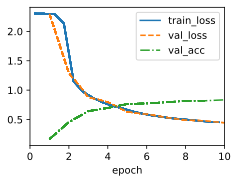

In [ ]:
model = AlexNet(lr=0.01)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(model, data)

### 8.1.4. Discussion

AlexNet's structure bears a striking resemblance to LeNet, with a number of critical improvements, both for accuracy (dropout) and for ease of training (ReLU). What is equally striking is the amount of progress that has been made in terms of deep learning tooling. What was several months of work in 2012 can now be accomplished in a dozen lines of code using any modern framework.

Reviewing the architecture, we see that AlexNet has an Achilles heel when it comes to efficiency: the last two hidden layers require matrices of size $6400 \times 4096$ and $4096 \times 4096$, respectively. This corresponds to 164 MB of memory and 81 MFLOPs of computation, both of which are a nontrivial outlay, especially on smaller devices, such as mobile phones. This is one of the reasons why AlexNet has been surpassed by much more effective architectures that we will cover in the following sections. Nonetheless, it is a key step from shallow to deep networks that are used nowadays. Note that even though the number of parameters exceeds by far the amount of training data in our experiments (the last two layers have more than 40 million parameters, trained on a datasets of 60 thousand images), there is hardly any overfitting: training and validation loss are virtually identical throughout training. This is due to the improved regularization, such as dropout, inherent in modern deep network designs.

Although it seems that there are only a few more lines in AlexNet's implementation than in LeNet's, it took the academic community many years to embrace this conceptual change and take advantage of its excellent experimental results. This was also due to the lack of efficient computational tools. At the time neither DistBelief (Dean et al., 2012) nor Caffe (Jia et al., 2014) existed, and Theano (Bergstra et al., 2010) still lacked many distinguishing features. It was the availability of TensorFlow (Abadi et al., 2016) that dramatically changed the situation.

---
牧之：给出 164 MB 内存需求和 81 MFLOPs 计算需求的详细推导过程。

GPT：

首先，我们来计算矩阵所占内存的大小:

每个元素通常假设占用 4 个字节（32 位浮点数）

- 对于 $6400 \times 4096$ 的矩阵：$ 6400 \times 4096 \times 4 \div (1024 \times 1024) = 100 \text{ MB}$

- 对于 $4096 \times 4096$ 的矩阵：$ 4096 \times 4096 \times 4 \div (1024 \times 1024) = 64 \text{ MB}$

因此，占用总内存数为 164 MB。

接下来，我们来计算浮点运算操作的数量：

对于矩阵乘法 $A \times B = C$，假设 $A$ 是 $m \times n$ 的矩阵，$B$ 是 $n \times p$ 的矩阵，那么乘法操作的总次数为 $2 \times m \times n \times p$。

- 对于 $6400 \times 4096$ 和 $4096 \times 4096$ 的矩阵相乘，操作总次数为：$ 2 \times 6400 \times 4096 \times 4096 = 106,168,320,000 \text{ 次浮点运算} = 106.17 \times 10^3 \text{ MFLOPs} $

牧之：对于矩阵乘法 $A \times B = C$，假设 $A$ 是 $m \times n$ 的矩阵，$B$ 是 $n \times p$ 的矩阵，那么乘法操作的总次数为 $2 \times m \times n \times p$。 这个又是怎么得到的？

GPT：这个公式来自于矩阵乘法的定义。在矩阵乘法 $A \times B = C$ 中，结果矩阵 $C$ 的每个元素是由 $A$ 的对应行与 $B$ 的对应列相乘后再相加得到的。因此，对于 $A$ 的每一行中的 $n$ 个元素，都需要与 $B$ 的每一列中的 $n$ 个元素相乘，然后将这些乘积相加，这样的操作共需要 $n$ 次乘法和 $n-1$ 次加法。因此，对于 $A$ 的 $m$ 行与 $B$ 的 $p$ 列，总共需要进行 $m \times p$ 次这样的操作。但是，每次这样的操作都需要进行 $n$ 次乘法和 $n-1$ 次加法，所以总的次数就是 $2 \times m \times n \times p$。

牧之：GPT 推导计算量时，公式是对的，但把两个隐藏层的权重矩阵相乘是不对的，而且是一种典型错误。豆包给出了正确方法。

豆包：矩阵乘法的计算量为乘法操作的次数。
- 对于矩阵乘法 $6400 \times 4096$，每次乘法得到一个结果，需要 $6400 \times 4096$ 次乘法，即约 26.21 MFLOPs 乘法操作。
- 对于矩阵乘法 $4096 \times 4096$ ，需要 $4096 \times 4096$ 次乘法，约 16.78 MFLOPs 乘法操作。

两者相加，得到总的乘法操作约 43 MFLOPs。由于一次矩阵乘法包含一次乘法和一次加法，所以总的计算量约为乘法操作的 2 倍，即约 81 MFLOPs。


### 8.1.5. Exercises

1. Following up on the discussion above, analyze the computational properties of AlexNet.
  - Compute the memory footprint for convolutions and fully connected layers, respectively. Which one dominates?
  - Calculate the computational cost for the convolutions and the fully connected layers.
  - How does the memory (read and write bandwidth, latency, size) affect computation? Is there any difference in its effects for training and inference?
  - 牧之：假设将 224 x 224 x 3 大小的图像输入 AlexNet，结合具体的 AlexNet 的网络结构参数，中文解答以下问题。注意，需要给出详细的推导分析过程，以便我检查你的答案是否合理。

  - GPT4：让我们一步步地分析 AlexNet 的计算属性，并计算卷积层和全连接层的内存占用和计算成本。
  
    1. 内存占用
      - 卷积层内存占用：对于卷积层，内存占用包括权重和激活（输出特征图）的存储。
          - 权重内存计算（原始算法分成两个 GPU 处理，此处忽略这个细节来计算）：
            - 第 1 层：$11 \times 11 \times 3 \times 96$ 个权重 + 96 个偏置 = 34944
            - 第 2 层：$5 \times 5 \times 96 \times 256$ 个权重 + 256 个偏置 = 614656
            - 第 3 层：$3 \times 3 \times 256 \times 384$ 个权重 + 384 个偏置 = 885120
            - 第 4 层：$3 \times 3 \times 384 \times 384$ 个权重 + 384 个偏置 = 1327488
            - 第 5 层：$3 \times 3 \times 384 \times 256$ 个权重 + 256 个偏置 = 884992
            - 卷积层权重总大小：(34944 + 614656 + 885120 + 1327488 + 884992) * 4 \/ (1024 * 1024) = 14.29 MB

          - 激活内存计算（取决于特征图大小）：
            - 第 1 层输出：$54 \times 54 \times 96$ = 279936
            - 第 2 层输出：$26 \times 26 \times 256$ = 173056
            - 第 3 层输出：$12 \times 12 \times 384$ = 55296
            - 第 4 层输出：$12 \times 12 \times 384$ = 55296
            - 第 5 层输出：$12 \times 12 \times 256$ = 36864
            - 卷积层特征图总大小：(279936 + 173056 + 55296 + 55296 + 36864) * 4 \/ (1024 * 1024) = 2.29 MB
          
          - 卷积层内存占用：14.29 + 2.29 = 16.58 MB

      - 全连接层内存占用：全连接层主要由权重和偏置组成。
          - 第 1 个全连接层：$256 \times 5 \times 5 \times 4096$ 个权重 + 4096 个偏置 = 26218496
          - 第 2 个全连接层：$4096 \times 4096$ 个权重 + 4096 个偏置 = 16781312
          - 第 3 个全连接层：$4096 \times 1000$ 个权重 + 1000 个偏置 = 4097000
          - 全连接层内存占用：(26218496 + 16781312 + 4097000) * 4 \/ (1024 * 1024) = 179.66 MB

      - 结论：全连接层的内存占用是主要因素，在本例中超过卷积层 10 倍。

    2. 计算成本
      - 卷积层计算成本：计算成本可以用“乘-加”操作的数量来估算。一个卷积操作涉及一个权重和一个输入激活的乘法，接着和一个累加器的加法。
          - 第 1 层：$11 \times 11 \times 3 \times 96 \times 54 \times 54$ 次乘加 = 101616768
          - 第 2 层：$5 \times 5 \times 96 \times 256 \times 26 \times 26$ 次乘加 = 415334400
          - 第 3 层：$3 \times 3 \times 256 \times 384 \times 12 \times 12$ 次乘加 = 127401984
          - 第 4 层：$3 \times 3 \times 384 \times 384 \times 12 \times 12$ 次乘加 = 191102976
          - 第 5 层：$3 \times 3 \times 384 \times 256 \times 12 \times 12$ 次乘加 = 127401984
          - 卷积层总计算量：(101616768 + 415334400 + 127401984 + 191102976 + 127401984) = 962858112 = 962.86 MFLOPs

      - 全连接层计算成本：全连接层的计算成本同样可以用乘-加操作的数量来估算。
          - 第 1 个全连接层：$256 \times 5 \times 5 \times 4096$ 次乘加 = 26214400
          - 第 2 个全连接层：$4096 \times 4096$ 次乘加 = 16777216
          - 第 3 个全连接层：$4096 \times 1000$ 次乘加 = 4096000
          - 全连接层总计算量：(26214400 + 16777216 + 4096000) = 47087616 = 47.09 MFLOPs

      - 结论：卷积层的计算成本是主要因素，在本例中超过全连接层 20 倍。

    3. 计算影响
      - 内存的读写带宽、延迟和大小对计算有显著影响。在训练和推理过程中，内存特性的影响是有所不同的：
          - 读写带宽：如果带宽不足，无法及时将数据送入计算单元，会成为瓶颈，导致 GPU 等待数据。
          - 延迟：高延迟会增加读取输入数据或权重的时间，影响每次迭代的速度。
          - 大小：内存大小限制了可以使用的模型大小和批处理量，特别是在训练时，需要存储更多中间数据。
      - 在训练期间，由于需要进行前向传播和反向传播，同时还需要存储梯度，所以内存的需求更大。而在推理时，通常只需要进行前向传播，因此内存的要求相对较低。

    4. 结论
      - 内存占用：全连接层的权重数量通常远大于卷积层，因此全连接层在内存占用上占主导地位。
      - 计算成本：卷积层的计算成本较高，因为卷积操作涉及大量的乘加操作。
      - 影响：内存特性对于模型的训练和推理效率至关重要，尤其是在处理大型网络如 AlexNet 时。训练通常受内存限制的影响更大。

1. You are a chip designer and need to trade off computation and memory bandwidth. For example, a faster chip requires more power and possibly a larger chip area. More memory bandwidth requires more pins and control logic, thus also more area. How do you optimize?
- 通义：作为芯片设计师，在优化计算能力和内存带宽的同时，确实需要在功耗、芯片面积、I/O接口数量以及控制逻辑复杂度之间进行权衡。以下是一些优化策略：

1. 设计架构优化
计算密集型应用：考虑使用更高效的计算单元，如SIMD（单指令多数据）架构，这可以在一次操作中处理多个数据点，从而提高计算效率。此外，使用异构计算，将计算密集型任务分配给专用硬件（如GPU、FPGA或AI加速器），可以提高整体性能。

内存访问优化：设计缓存层次结构，如L1、L2、L3缓存，以减少对主内存的访问。同时，优化数据布局，使用局部性原理，确保频繁访问的数据位于高速缓存中。

2. 芯片物理设计
芯片面积优化：通过集成电路设计规则的优化，例如使用更先进的工艺节点（如7nm、5nm等），可以缩小晶体管尺寸，从而减小芯片面积。此外，使用多核架构或多处理器系统（MPSoC）可以分散计算负载，减少单个芯片的负担。

功率管理：实施动态电压频率缩放（DVFS）技术，根据负载需求动态调整工作电压和频率，以降低功耗。还可以采用电源管理单元（PMU）来监控和优化电源使用。

3. 内存设计
内存带宽提升：使用更快的存储器技术，如DDR5或更高版本，可以增加内存带宽。同时，优化内存接口设计，减少信号延迟和失真，提高数据传输速度。

内存访问模式：设计内存访问模式以减少等待时间，例如使用预取技术预测并提前加载数据到缓存中。

4. 系统级优化
软件优化：编写高效的软件算法，避免不必要的内存访问和重复计算，通过编译器优化、代码重组等方式提高程序效率。

并行计算：利用多线程、多核或多GPU并行计算，减少单个任务的运行时间，同时合理分配任务，避免资源争用。

5. 封装和冷却
封装技术：选择高效的封装技术，如2.5D/3D堆叠封装，可以减少信号延迟，提高芯片间的通信效率。

冷却方案：设计有效的冷却系统，如散热片、热管或液冷系统，以减少由于功耗增加导致的热量问题。

结论
优化计算和内存带宽之间的权衡是一个复杂的过程，需要跨学科的知识和精细的设计。通过上述策略的综合运用，可以有效地提高芯片的整体性能，同时考虑功耗、面积和成本等因素。

1. Why do engineers no longer report performance benchmarks on AlexNet?

1. Try increasing the number of epochs when training AlexNet. Compared with LeNet, how do the results differ? Why?

1. AlexNet may be too complex for the Fashion-MNIST dataset, in particular due to the low resolution of the initial images.
  - Try simplifying the model to make the training faster, while ensuring that the accuracy does not drop significantly.
  - Design a better model that works directly on $28 \times 28$ images.

1. Modify the batch size, and observe the changes in throughput (images/s), accuracy, and GPU memory.

1. Apply dropout and ReLU to LeNet-5. Does it improve? Can you improve things further by preprocessing to take advantage of the invariances inherent in the images?
- 通义：将Dropout和ReLU激活函数应用于LeNet-5网络可以带来一定的改进效果，主要体现在两个方面：防止过拟合和加快收敛速度。同时，通过图像预处理来利用图像中存在的不变性，可以进一步提升模型的性能。

1. Dropout
Dropout是一种正则化技术，通过在训练过程中随机“关闭”一部分神经元，可以防止模型在训练时过于依赖特定的神经元，从而降低过拟合的风险。在LeNet-5中应用Dropout时，可以在全连接层之后添加Dropout层，设置一个适当的dropout率（例如0.5）。较低的dropout率有助于模型学习更多的特征，而较高的dropout率则有助于防止过拟合。

2. ReLU激活函数
ReLU（Rectified Linear Unit）激活函数在LeNet-5中的应用，相比于传统的Sigmoid或Tanh激活函数，ReLU具有更快的计算速度和更好的收敛性。ReLU函数对于非负值为线性函数，对于负值为零，这有助于加速反向传播过程中的梯度消失问题，促进模型更快地收敛。在LeNet-5的每一层中，可以替换原有的激活函数为ReLU。

3. 图像预处理
为了利用图像中的不变性，可以采取以下几种预处理措施：

灰度转换：如果颜色信息不是关键因素，可以将彩色图像转换为灰度图像，减少输入维度，同时简化模型的复杂度。
归一化：对图像像素值进行归一化处理，将其范围限制在[0, 1]或[-1, 1]之间，可以加速训练过程，减少梯度消失问题。
旋转、平移、缩放：通过随机变换图像，可以增加模型的鲁棒性，使其能够识别不同角度、位置和大小的对象。
翻转：对图像进行水平或垂直翻转，可以增加数据集的多样性，帮助模型学习更加通用的特征。
裁剪：去除图像边缘的不相关部分，专注于图像的核心区域，有助于模型关注更重要的特征。
综合优化
将Dropout、ReLU激活函数以及上述图像预处理措施综合应用于LeNet-5中，可以显著提高模型的泛化能力，减少过拟合风险，并且加快训练速度。此外，通过精心设计的预处理步骤，模型可以更有效地利用图像数据中的不变性，从而在保持模型复杂度的同时，提高分类准确率。

1. Can you make AlexNet overfit? Which feature do you need to remove or change to break training?

## 8.2. Networks Using Blocks (VGG)

While AlexNet offered empirical evidence that deep CNNs can achieve good results, it did not provide a general template to guide subsequent researchers in designing new networks. In the following sections, we will introduce several heuristic concepts commonly used to design deep networks.

Progress in this field mirrors that of VLSI (very large scale integration) in chip design where engineers moved from placing transistors to logical elements to logic blocks (Mead, 1980). Similarly, the design of neural network architectures has grown progressively more abstract, with researchers moving from thinking in terms of individual neurons to whole layers, and now to blocks, repeating patterns of layers. A decade later, this has now progressed to researchers using entire trained models to repurpose them for different, albeit related, tasks. Such large pretrained models are typically called *foundation models* (Bommasani et al., 2021).

Back to network design. The idea of using blocks first emerged from the Visual Geometry Group (VGG) at Oxford University, in their eponymously-named *VGG* network (Simonyan and Zisserman, 2014). It is easy to implement these repeated structures in code with any modern deep learning framework by using loops and subroutines.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.2.1. VGG Blocks

The basic building block of CNNs is a sequence of the following: (i) a convolutional layer with padding to maintain the resolution, (ii) a nonlinearity such as a ReLU, (iii) a pooling layer such as max-pooling to reduce the resolution. *One of the problems with this approach is that the spatial resolution decreases quite rapidly*. In particular, this imposes a hard limit of $\log_2 d$ convolutional layers on the network before all dimensions ($d$) are used up. For instance, in the case of ImageNet, it would be impossible to have more than 8 convolutional layers in this way.

The key idea of Simonyan and Zisserman (2014) was to use *multiple* convolutions in between downsampling via max-pooling in the form of a block. They were primarily interested in whether deep or wide networks perform better. For instance, the successive application of two $3 \times 3$ convolutions touches *the same pixels* as a single $5 \times 5$ convolution does. At the same time, the latter uses approximately as many parameters ($25 \cdot c^2$) as three $3 \times 3$ convolutions do ($3 \cdot 9 \cdot c^2$). In a rather detailed analysis they showed that *deep and narrow networks significantly outperform their shallow counterparts*. This set deep learning on a quest for ever deeper networks with over 100 layers for typical applications. Stacking $3 \times 3$ convolutions has become a gold standard in later deep networks (a design decision only to be revisited recently by Liu et al. (2022)). Consequently, fast implementations for small convolutions have become a staple on GPUs (Lavin and Gray, 2016).

Back to VGG: a VGG block consists of a *sequence* of convolutions with $3\times3$ kernels with padding of 1 (keeping height and width) followed by a $2 \times 2$ max-pooling layer with stride of 2 (halving height and width after each block). In the code below, we define a function called `vgg_block` to implement one VGG block.

The function below takes two arguments, corresponding to the number of convolutional layers `num_convs` and the number of output channels `num_channels`.

In [ ]:
def vgg_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

### 8.2.2. VGG Network

Like AlexNet and LeNet, the VGG Network can be partitioned into two parts: the first consisting mostly of convolutional and pooling layers and the second consisting of fully connected layers that are identical to those in AlexNet. The key difference is that the convolutional layers are grouped in nonlinear transformations that leave the dimensonality unchanged, followed by a resolution-reduction step, as depicted in Fig. 8.2.1.

<p align="center">
  <img src="http://d2l.ai/_images/vgg.svg"/>
  <br />
  <em>Fig. 8.2.1</em> From AlexNet to VGG. The key difference is that VGG consists of blocks of layers, whereas AlexNet’s layers are all designed individually.
</p>

The convolutional part of the network connects several VGG blocks from Fig. 8.2.1 (also defined in the `vgg_block` function) in succession. *This grouping of convolutions is a pattern that has remained almost unchanged over the past decade*, although the specific choice of operations has undergone considerable modifications. The variable `arch` consists of a list of tuples (one per block), where each contains two values: the number of convolutional layers and the number of output channels, which are precisely the arguments required to call the `vgg_block` function. As such, VGG defines *a family of networks* rather than just a specific manifestation. To build a specific network we simply iterate over `arch` to compose the blocks.

In [ ]:
class VGG(d2l.Classifier):
    def __init__(self, arch, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        conv_blks = []
        for (num_convs, out_channels) in arch:
            conv_blks.append(vgg_block(num_convs, out_channels))
        self.net = nn.Sequential(
            *conv_blks, nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)

The original VGG network had five convolutional blocks, among which the first two have one convolutional layer each and the latter three contain two convolutional layers each. The first block has 64 output channels and each subsequent block doubles the number of output channels, until that number reaches 512. Since this network uses eight convolutional layers and three fully connected layers, it is often called VGG-11.

In [ ]:
VGG(arch=((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))).layer_summary(
    (1, 1, 224, 224))

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


As you can see, we halve height and width at each block, finally reaching a height and width of 7 before flattening the representations for processing by the fully connected part of the network. Simonyan and Zisserman (2014) described several other variants of VGG. In fact, it has become the norm to propose *families* of networks with different speed--accuracy trade-off when introducing a new architecture.

### 8.2.3. Training

Since VGG-11 is computationally more demanding than AlexNet we construct a network with a smaller number of channels. This is more than sufficient for training on Fashion-MNIST. The model training process is similar to that of AlexNet in Section 8.1. Again observe the close match between validation and training loss, suggesting only a small amount of overfitting.

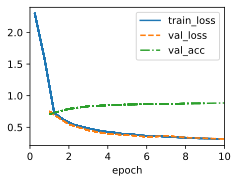

In [ ]:
model = VGG(arch=((1, 16), (1, 32), (2, 64), (2, 128), (2, 128)), lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.2.4. Summary

One might argue that VGG is the first truly modern convolutional neural network. While AlexNet introduced many of the components of what make deep learning effective at scale, it is VGG that arguably introduced key properties such as blocks of multiple convolutions and a preference for deep and narrow networks. It is also the first network that is actually an entire family of similarly parametrized models, *giving the practitioner ample trade-off between complexity and speed*. This is also the place where modern deep learning frameworks shine. It is no longer necessary to generate XML configuration files to specify a network but rather, to assemble said networks through simple Python code.

More recently ParNet (Goyal et al., 2021) demonstrated that it is possible to achieve competitive performance using a much more shallow architecture through a large number of parallel computations. This is an exciting development and there is hope that it will influence architecture designs in the future. For the remainder of the chapter, though, we will follow the path of scientific progress over the past decade.

### 8.2.5. Exercises

1. Compared with AlexNet, VGG is much slower in terms of computation, and it also needs more GPU memory.
  - Compare the number of parameters needed for AlexNet and VGG.
  - Compare the number of floating point operations used in the convolutional layers and in the fully connected layers.
  - How could you reduce the computational cost created by the fully connected layers?
  - GPT4：本文中给出的为简化版本的 VGG-11，原版的 VGG-11 网络参数。假设输入为 224 x 224 x 3 大小的图像。

    VGG-11 网络结构主要包含卷积层和全连接层，使用的是非常传统的卷积神经网络结构。

    - 卷积层

      1. 卷积层1: 输入通道数=3, 输出通道数=64, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 最大池化: 核大小=2x2, 步长=2。
      1. 卷积层2: 输入通道数=64, 输出通道数=128, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 最大池化: 核大小=2x2, 步长=2。
      1. 卷积层3: 输入通道数=128, 输出通道数=256, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 卷积层4: 输入通道数=256, 输出通道数=256, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 最大池化: 核大小=2x2, 步长=2。
      1. 卷积层5: 输入通道数=256, 输出通道数=512, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 卷积层6: 输入通道数=512, 输出通道数=512, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 最大池化: 核大小=2x2, 步长=2。
      1. 卷积层7: 输入通道数=512, 输出通道数=512, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 卷积层8: 输入通道数=512, 输出通道数=512, 卷积核大小=3x3, 步长=1, 填充=1。
      1. 最大池化: 核大小=2x2, 步长=2。

    - 全连接层

      1. 全连接层1: 输入特征数=7x7x512, 输出特征数=4096。
      1. 全连接层2: 输入特征数=4096, 输出特征数=4096。
      1. 全连接层3: 输入特征数=4096, 输出特征数=1000。

    参数数量计算

    - 卷积层参数

      每个卷积层的参数数量为：$ 参数数量 = 卷积核高 \times 卷积核宽 \times 输入通道数 \times 输出通道数 + 输出通道数 $ (额外的输出通道数代表偏置项)

      1. 卷积层1: $ 3 \times 3 \times 3 \times 64 + 64 = 1,792 $
      1. 卷积层2: $ 3 \times 3 \times 64 \times 128 + 128 = 73,856 $
      1. 卷积层3: $ 3 \times 3 \times 128 \times 256 + 256 = 295,168 $
      1. 卷积层4: $ 3 \times 3 \times 256 \times 256 + 256 = 590,080 $
      1. 卷积层5: $ 3 \times 3 \times 256 \times 512 + 512 = 1,180,160 $
      1. 卷积层6: $ 3 \times 3 \times 512 \times 512 + 512 = 2,359,808 $
      1. 卷积层7: 同上，$2,359,808$
      1. 卷积层8: 同上，$2,359,808$
      - 卷积层参数总计: $ 1,792 + 73,856 + 295,168 + 590,080 + 1,180,160 + 2,359,808 + 2,359,808 + 2,359,808 = 9,220,480 $

    - 全连接层参数

      1. 全连接层1: $ 7 \times 7 \times 512 \times 4096 + 4096 = 102,764,544 $
      1. 全连接层2: $ 4096 \times 4096 + 4096 = 16,781,312 $
      1. 全连接层3: $ 4096 \times 1000 + 1000 = 4,097,000 $
      - 全连接层参数总计: $ 102,764,544 + 16,781,312 + 4,097,000 = 123,642,856 $

    - VGG-11 总参数数量

      总参数 = 卷积层参数总计 + 全连接层参数总计 = $9,220,480 + 123,642,856 = 132,863,336$，对应的内存占用为 132,863,336 * 4 \/ (1024 * 1024) = $506.83 \text{ MB}$

      作为对比，AlexNet 的卷积层内存占用为 $16.58 \text{ MB}$，全连接层内存占用为 $179.66 \text{ MB}$，整个 AlexNet 内存占用为 $196.24 \text{ MB}$

    浮点操作数 (FLOPs) 计算

    - 卷积层 FLOPs

      每个卷积操作的 FLOPs 可以计算为：$ FLOPs = 卷积核高 \times 卷积核宽 \times 输入通道数 \times 输出高度 \times 输出宽度 \times 输出通道数 \times 2 $

      2 倍是因为每个卷积操作包括乘法和加法。但为了简化，我们不考虑偏置的加法。

      由于池化层不涉及权重，所以它们的计算成本相对较低，此处不计入总 FLOPs 中。

      1. 卷积层1: $ 3 \times 3 \times 3 \times 224 \times 224 \times 64 \times 2 = 86,806,528 $
      1. 卷积层2: $ 3 \times 3 \times 64 \times 112 \times 112 \times 128 \times 2 = 173,408,256 $
      1. 卷积层3: $ 3 \times 3 \times 128 \times 56 \times 56 \times 256 \times 2 = 173,408,256 $
      1. 卷积层4: $ 3 \times 3 \times 256 \times 56 \times 56 \times 256 \times 2 = 346,816,512 $
      1. 卷积层5: $ 3 \times 3 \times 256 \times 28 \times 28 \times 512 \times 2 = 346,816,512 $
      1. 卷积层6: $ 3 \times 3 \times 512 \times 28 \times 28 \times 512 \times 2 = 693,633,024 $
      1. 卷积层7: 同上，$693,633,024$
      1. 卷积层8: 同上，$693,633,024$
      - 卷积层 FLOPs 总计: $ 86,806,528 + 173,408,256 \times 2 + 173,408,256 + 346,816,512 \times 2 + 693,633,024 \times 3 = 3,626,934,784 \approx 3.63 \text{ GFLOPs}$

    - 全连接层 FLOPs

      每个全连接层操作的 FLOPs 可以计算为：$ FLOPs = 输入特征数 \times 输出特征数 \times 2 $

      同样，这里的 2 倍是因为每个操作包括乘法和加法。

      1. 全连接层1: $ 7 \times 7 \times 512 \times 4096 \times 2 = 102,760,448 $
      1. 全连接层2: $ 4096 \times 4096 \times 2 = 33,554,432 $
      1. 全连接层3: $ 4096 \times 1000 \times 2 = 8,192,000 $
      - 全连接层 FLOPs 总计: $ 102,760,448 + 33,554,432 + 8,192,000 = 144,506,880 $

      VGG-11 FLOPs 总计: $ 3,626,934,784 + 144,506,880 \approx 3.77 \text{ GFLOPs} $

      作为对比，AlexNet 的卷积层计算量为 $962.86 \text{ MFLOPs} \times 2 = 1.93 \text{ GFLOPs}$，全连接层计算量为 $47.09 \text{ MFLOPs} \times 2 = 0.09 \text{ GFLOPs}$，整个 AlexNet 计算量为 $2.02 \text{ GFLOPs}$

    减少全连接层计算成本

    为了减少全连接层的计算成本，可以采取以下几种策略：

    - 参数共享: 通过使用卷积替代全连接层实现参数共享。
    - 网络剪枝: 移除全连接层中的一些不活跃的神经元。
    - 低秩分解: 使用矩阵分解技术来近似全连接层的权重矩阵。
    - 量化: 降低参数的表示精度。
    - 知识蒸馏: 使用一个更小的网络来模仿一个大网络的行为，只保留最关键的部分。

    这些方法的目的都是在保持网络性能的同时减少参数数量和/或减少每个参数所需的计算量。

    附注

    - 低秩分解

      - 低秩分解是一种通过将原始权重矩阵分解为较低秩的子矩阵来降低全连接层权重的方法。在神经网络中，全连接层的权重通常表示为一个大的二维权重矩阵。低秩分解的目标是将这个大矩阵分解为两个或多个较小的矩阵的乘积。

      - 具体来说，对于一个全连接层的权重矩阵W，低秩分解将其分解为两个较小的矩阵U和V的乘积，其中U的维度为(m, k)，V的维度为(k, n)，通常满足k << min(m, n)。这样的分解降低了参数数量，因为较小的U和V矩阵所需的参数数量明显少于原始的权重矩阵W。

      - 这种降低参数数量的同时，通过低秩分解也可以在一定程度上保留原始矩阵的关键信息，从而在减少计算成本的同时尽量保持模型的性能。

    - 知识蒸馏
    
      - 知识蒸馏是一种方法，通过使用一个更小的模型（通常称为学生模型）来模仿一个更大、更复杂的模型（通常称为教师模型）的行为，从而降低全连接层权重的复杂性。

      - 在知识蒸馏中，全连接层的权重并没有直接被降低，而是通过在训练过程中传递教师模型的"知识"（通常是软标签或者中间层表示）给学生模型来降低其复杂性。这种知识通常包括模型对输入数据的细粒度预测概率分布或者中间层表示。

      - 通过这种方法，学生模型可以更有效地学习并近似教师模型，从而在某种程度上减少了全连接层的权重复杂性。知识蒸馏在训练较小的模型时，能够帮助提高模型的泛化性能和减少全连接层的计算成本。

      - 牧之：既然更小的模型可以模拟更大的模型，那为什么不直接用更小的模型训练？

        - 直接使用更小的模型进行训练通常是一个很好的选择，但有时候更大的模型可能会有更好的性能。这可能是因为更大的模型具有更多的参数和复杂性，可以更好地捕捉数据中的细微特征和模式。

        - 知识蒸馏的主要优势在于通过教师模型的知识来引导更小的模型进行训练，从而在某种程度上获得了较大模型的性能优势。同时，知识蒸馏还可以帮助减少更小模型的过拟合风险，并且可以加速收敛速度。

        - 因此，尽管直接使用更小的模型进行训练是一个很好的选择，但在某些情况下，利用知识蒸馏可以在保持较小模型规模的同时，获得较大模型的性能优势。

1. When displaying the dimensions associated with the various layers of the network, we only see the information associated with eight blocks (plus some auxiliary transforms), even though the network has 11 layers. Where did the remaining three layers go?

1. Use Table 1 in the VGG paper (Simonyan and Zisserman, 2014) to construct other common models, such as VGG-16 or VGG-19.

1. Upsampling the resolution in Fashion-MNIST eight-fold from $28 \times 28$ to $224 \times 224$ dimensions is very wasteful. Try modifying the network architecture and resolution conversion, e.g., to 56 or to 84 dimensions for its input instead. Can you do so without reducing the accuracy of the network? Consult the VGG paper (Simonyan and Zisserman, 2014) for ideas on adding more nonlinearities prior to downsampling.

## 8.3. Network in Network (NiN)

LeNet, AlexNet, and VGG all share a common design pattern: extract features exploiting *spatial* structure via a sequence of convolutions and pooling layers and post-process the representations via fully connected layers. The improvements upon LeNet by AlexNet and VGG mainly lie in how these later networks widen and deepen these two modules.

This design poses two major challenges. First, the fully connected layers at the end of the architecture consume tremendous numbers of parameters. For instance, even a simple model such as VGG-11 requires a monstrous matrix, occupying almost 400MB of RAM in single precision (FP32). This is a significant impediment to computation, in particular on mobile and embedded devices. After all, even high-end mobile phones sport no more than 8GB of RAM. At the time VGG was invented, this was an order of magnitude less (the iPhone 4S had 512MB). As such, it would have been difficult to justify spending the majority of memory on an image classifier.

Second, it is equally impossible to add fully connected layers earlier in the network to increase the degree of nonlinearity: doing so would destroy the spatial structure and require potentially even more memory.

The *network in network* (*NiN*) blocks (Lin et al., 2013) offer an alternative, capable of solving both problems in one simple strategy. They were proposed based on a very simple insight: (i) use $1 \times 1$ convolutions to add local nonlinearities across the channel activations and (ii) use global average pooling to integrate across all locations in the last representation layer. Note that global average pooling would not be effective, were it not for the added nonlinearities. Let's dive into this in detail.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.3.1. NiN Blocks

Recall Section 7.4.3. In it we said that the inputs and outputs of convolutional layers consist of four-dimensional tensors with axes corresponding to the example, channel, height, and width. Also recall that the inputs and outputs of fully connected layers are typically two-dimensional tensors corresponding to the example and feature. The idea behind NiN is to apply a fully connected layer at each pixel location (for each height and width). The resulting $1 \times 1$ convolution can be thought of as a fully connected layer acting independently on each pixel location.

Fig. 8.3.1 illustrates the main structural differences between VGG and NiN, and their blocks. Note both the difference in the NiN blocks (the initial convolution is followed by $1 \times 1$ convolutions, whereas VGG retains $3 \times 3$ convolutions) and at the end where we no longer require a giant fully connected layer.

<p align="center">
  <img src="http://d2l.ai/_images/nin.svg"/>
  <br />
  <em>Fig. 8.3.1</em> Comparing the architectures of VGG and NiN, and of their blocks.
</p>

In [ ]:
def nin_block(out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.LazyConv2d(out_channels, kernel_size, strides, padding), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU())

---
牧之：用传统的非 $1 \times 1$ 卷积 + 激活，提取空间特征，随后用 $1 \times 1$ 卷积 + 激活增加了同一空间像素在通道间的非线性。

### 8.3.2. NiN Model

NiN uses the same initial convolution sizes as AlexNet (it was proposed shortly thereafter). The kernel sizes are $11\times 11$, $5\times 5$, and $3\times 3$, respectively, and the numbers of output channels match those of AlexNet. Each NiN block is followed by a max-pooling layer with a stride of 2 and a window shape of $3\times 3$.

The second significant difference between NiN and both AlexNet and VGG is that NiN avoids fully connected layers altogether. Instead, NiN uses a NiN block with a number of output channels equal to the number of label classes, followed by a *global* average pooling layer, yielding a vector of logits. This design significantly reduces the number of required model parameters, albeit at the expense of a potential increase in training time.

In [ ]:
class NiN(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nin_block(96, kernel_size=11, strides=4, padding=0),
            nn.MaxPool2d(3, stride=2),
            nin_block(256, kernel_size=5, strides=1, padding=2),
            nn.MaxPool2d(3, stride=2),
            nin_block(384, kernel_size=3, strides=1, padding=1),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout(0.5),
            nin_block(num_classes, kernel_size=3, strides=1, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten())
        self.net.apply(d2l.init_cnn)

We create a data example to see the output shape of each block.

In [ ]:
NiN().layer_summary((1, 1, 224, 224))

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


### 8.3.3. Training

As before we use Fashion-MNIST to train the model using the same optimizer that we used for AlexNet and VGG.

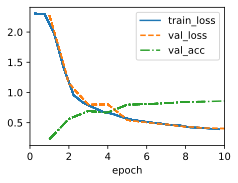

In [ ]:
model = NiN(lr=0.05)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.3.4. Summary

NiN has dramatically fewer parameters than AlexNet and VGG. This stems primarily from the fact that it needs no giant fully connected layers. Instead, it uses global average pooling to aggregate across all image locations after the last stage of the network body. This obviates the need for expensive (learned) reduction operations and replaces them by a simple average. *What surprised researchers at the time was the fact that this averaging operation did not harm accuracy*. Note that averaging across a low-resolution representation (with many channels) also adds to the amount of translation invariance that the network can handle.

Choosing fewer convolutions with wide kernels and replacing them by $1 \times 1$ convolutions aids the quest for fewer parameters further. It can cater for a significant amount of nonlinearity across channels within any given location. Both $1 \times 1$ convolutions and global average pooling significantly influenced subsequent CNN designs.

### 8.3.5. Exercises

1. Why are there two $1\times 1$ convolutional layers per NiN block? Increase their number to three. Reduce their number to one. What changes?
- GPT：在 NiN（Network in Network）块中有两个 $1\times 1$ 卷积层的原因是为了增加非线性。通过增加到三个 $1\times 1$ 卷积层，可以进一步增加网络的非线性，从而提高网络的表达能力，但也会增加模型的复杂度。减少到一个 $1\times 1$ 卷积层会减少非线性，可能会减少模型的表达能力，但会降低模型的复杂度。增加 $1\times 1$ 卷积层的数量会增加模型的容量，减少则可能减少模型的灵活性和表达能力。
- 通义：在NiN（Networks in Networks）块中包含两个1×1卷积层的主要原因是为了实现以下功能：

通道维度的变换：1×1卷积层可以通过改变输入特征图的通道数来灵活地调整网络的参数量和计算量。这种变换允许网络在不改变空间维度的情况下增加或减少通道数，从而控制网络的复杂度和参数量。

特征融合：在某些情况下，两个1×1卷积层可以用于对输入特征图进行加权求和，形成新的特征表示。这种操作类似于特征融合，可以帮助网络更好地学习和组合不同特征的重要性。

如果将每个NiN块中的1×1卷积层数量增加到三个：

增加了参数量：这会显著增加模型的参数量和计算复杂度，可能需要更多的训练数据和计算资源。
增强了灵活性：额外的1×1卷积层提供了更多的参数来调整特征表示，理论上可能允许网络学习更复杂的特征组合。
潜在的过拟合风险：虽然增加了学习能力，但也可能增加了模型过拟合的风险，需要通过正则化等手段来控制。

如果将每个NiN块中的1×1卷积层数量减少到一个：

减少了参数量：模型变得更简单，参数量和计算复杂度降低，可能有利于模型的泛化能力。
简化了特征学习：单一的1×1卷积层可能限制了特征学习的复杂性和灵活性，可能无法捕获到所有必要的高级特征。
可能的性能损失：简化后的模型可能在某些任务上表现不佳，因为它缺乏足够的参数来学习复杂的数据表示。
总之，增加或减少1×1卷积层的数量会影响模型的复杂度、参数量、计算效率以及最终的性能。在实际应用中，需要根据具体任务的需求、可用的计算资源以及对模型泛化能力的期望来权衡这些因素。

1. What changes if you replace the $1 \times 1$ convolutions by $3 \times 3$ convolutions?

1. What happens if you replace the global average pooling by a fully connected layer (speed, accuracy, number of parameters)?

1. Calculate the resource usage for NiN.
  - What is the number of parameters?
  - What is the amount of computation?
  - What is the amount of memory needed during training?
  - What is the amount of memory needed during prediction?
- GPT4 + 文心：假设输入为 224 x 224 x 3 大小的图像，以下为 NiN 网络参数和资源使用。

  NiN 网络结构

  1. 卷积层1: 输入通道数=3, 输出通道数=96, 卷积核大小=11x11, 步长=4, 填充=2。
  1. 附加卷积层1-1: 输入通道数=96, 输出通道数=96, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 附加卷积层1-2: 输入通道数=96, 输出通道数=96, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 最大池化1: 核大小=3x3, 步长=2。
  1. 卷积层2: 输入通道数=96, 输出通道数=256, 卷积核大小=5x5, 步长=1, 填充=2。
  1. 附加卷积层2-1: 输入通道数=256, 输出通道数=256, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 附加卷积层2-2: 输入通道数=256, 输出通道数=256, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 最大池化2: 核大小=3x3, 步长=2。
  1. 卷积层3: 输入通道数=256, 输出通道数=384, 卷积核大小=3x3, 步长=1, 填充=1。
  1. 附加卷积层3-1: 输入通道数=384, 输出通道数=384, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 附加卷积层3-2: 输入通道数=384, 输出通道数=10, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 最大池化3: 核大小=3x3, 步长=2。
  1. 卷积层4: 输入通道数=384, 输出通道数=10, 卷积核大小=3x3, 步长=1, 填充=1。
  1. 附加卷积层3-1: 输入通道数=10, 输出通道数=10, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 附加卷积层3-2: 输入通道数=10, 输出通道数=10, 卷积核大小=1x1, 步长=1, 填充=0。
  1. 自适应平均池化4: 核大小=5x5, 步长=1。

  NiN 参数数量计算

  1. 卷积层1: $ 11 \times 11 \times 3 \times 96 + 96 = 34,944 $
  1. 附加卷积层1-1: $ 1 \times 1 \times 96 \times 96 + 96 = 9,312 $
  1. 附加卷积层1-2: $ 1 \times 1 \times 96 \times 96 + 96 = 9,312 $
  1. 卷积层2: $ 5 \times 5 \times 96 \times 256 + 256 = 614,656 $
  1. 附加卷积层2-1: $ 1 \times 1 \times 256 \times 256 + 256 = 65,792 $
  1. 附加卷积层2-2: $ 1 \times 1 \times 256 \times 256 + 256 = 65,792 $
  1. 卷积层3: $ 3 \times 3 \times 256 \times 384 + 384 = 885,120 $
  1. 附加卷积层3-1: $ 1 \times 1 \times 384 \times 384 + 384 = 147,840 $
  1. 附加卷积层3-2: $ 1 \times 1 \times 384 \times 384 + 384 = 147,840 $
  1. 卷积层4: $ 3 \times 3 \times 384 \times 10 + 10 = 34,570 $
  1. 附加卷积层4-1: $ 1 \times 1 \times 10 \times 10 + 10 = 110 $
  1. 附加卷积层4-2: $ 1 \times 1 \times 10 \times 10 + 10 = 110 $
  - 参数总计: $ 34,944 + 9,312 + 9,312 + 614,656 + 65,792 + 65,792 + 885,120 + 147,840 + 147,840 + 34,570 + 110 + 110 = 2,015,398 $
  - 内存占用：$2,015,398 \times 4 \div (1024 \times 1024) \approx 7.69 \text{ MB}$
  - 作为对比
      - AlexNet 内存量为  196.24 MB
      - VGG-11 内存量为 506.83 MB

  计算量 (FLOPs)

  FLOPs 的计算类似于 VGG-11，我们先计算卷积层的 FLOPs，然后是附加卷积层的 FLOPs。具体计算需要每层的输出尺寸，因为 NiN 的每个卷积层后面都跟着 1x1 的卷积层，所以输出尺寸取决于前一个卷积层。因为这个计算较为复杂，所以这里不一一详细计算。

  卷积层 FLOPs 计算

  对于卷积层，FLOPs的计算公式是：$ \text{FLOPs} = \text{输入通道数} \times \text{卷积核高度} \times \text{卷积核宽度} \times \text{输出通道数} \times \text{输出特征图的高度} \times \text{输出特征图的宽度} $

  附加卷积层 FLOPs 计算

  附加卷积层（使用 $1 \times 1$ 卷积核）的 FLOPs 计算简化为：$ \text{FLOPs} = \text{输入通道数} \times 1 \times 1 \times \text{输出通道数} \times \text{输出特征图的高度} \times \text{输出特征图的宽度} $

  池化层

  池化层（如最大池化）通常不计入 FLOPs 计算。

  完整计算过程

  1. 卷积层1:

    - 输入尺寸: $224 \times 224 \times 3$
    - 输出尺寸: $54 \times 54 \times 96$
    - FLOPs: $3 \times 11 \times 11 \times 96 \times 54 \times 54 \approx 1.05 \times 10^9$

  1. 附加卷积层1-1和1-2:

    - 输入尺寸: $54 \times 54 \times 96$
    - 输出尺寸: $54 \times 54 \times 96$
    - FLOPs（每个附加层）: $96 \times 1 \times 1 \times 96 \times 54 \times 54 = 2.78 \times 10^7$
    - 两个附加层总FLOPs: $2 \times 2.78 \times 10^7 = 5.56 \times 10^7$
    - 最大池化1: 不计算 FLOPs

  1. 卷积层2:

    - 输入尺寸: $26 \times 26 \times 96$（注意：这里直接使用了池化后的尺寸）
    - 输出尺寸: $26 \times 26 \times 256$
    - FLOPs: $96 \times 5 \times 5 \times 256 \times 26 \times 26 \approx 1.96 \times 10^9$

  1. 附加卷积层2-1和2-2:

    - 输入尺寸: $26 \times 26 \times 256$
    - 输出尺寸: $26 \times 26 \times 256$
    - FLOPs（每个附加层）: $256 \times 1 \times 1 \times 256 \times 26 \times 26 = 4.47 \times 10^7$
    - 两个附加层总FLOPs: $2 \times 4.47 \times 10^7 = 8.94 \times 10^7$
    - 最大池化2: 不计算 FLOPs

  1. 卷积层3:

    - 输入尺寸: $12 \times 12 \times 256$（注意：这里直接使用了池化后的尺寸）
    - 输出尺寸: $12 \times 12 \times 384$
    - FLOPs: $256 \times 3 \times 3 \times 384 \times 12 \times 12 \approx 1.32 \times 10^9$

  1. 附加卷积层3-1和3-2:

    - 输入尺寸: $12 \times 12 \times 384$
    - 输出尺寸: $12 \times 12 \times 384$
    - FLOPs（每个附加层）: $384 \times 1 \times 1 \times 384 \times 12 \times 12 = 2.12 \times 10^7$
    - 两个附加层总FLOPs: $2 \times 2.12 \times 10^7 = 4.24 \times 10^7$
    - 最大池化3: 不计算 FLOPs

  1. 卷积层4:

    - 输入尺寸: $5 \times 5 \times 384$（注意：这里直接使用了池化后的尺寸）
    - 输出尺寸: $5 \times 5 \times 10$
    - FLOPs: $384 \times 3 \times 3 \times 10 \times 5 \times 5 = 864,000$

  1. 附加卷积层4-1和4-2:

    - 输入尺寸: $5 \times 5 \times 10$
    - 输出尺寸: $5 \times 5 \times 10$
    - FLOPs（每个附加层）: $10 \times 1 \times 1 \times 10 \times 5 \times 5 = 2500$
    - 两个附加层总FLOPs: $2 \times 2500 = 5000$
    - 最大池化4: 不计算 FLOPs

  - 乘加总计算量：$1.05 \times 10^9 + 5.56 \times 10^7 + 1.96 \times 10^9 + 8.94 \times 10^7 + 1.32 \times 10^9 + 4.24 \times 10^7 + 864,000 + 5000 = 4.33 \times 10^9 + 0.19 \times 10^9 = 4.52 \text{ GFLOPs}$
  - 总计算量：$4.52 \text{ GFLOPs} \times 2 = 9.04 \text{ GFLOPs}$
  - 作为对比
      - AlexNet 计算量为 $2.02 \text{ GFLOPs}$
      - VGG-11 计算量为 $3.77 \text{ GFLOPs}$

  训练时内存需求

  训练时的内存需求取决于参数的数量、激活的数量（每层的输出特征图）以及优化器存储的额外变量（例如，如果使用 Adam，还需要存储梯度的一阶和二阶矩）。假设我们使用单精度浮点数（4字节），则内存需求大致为：

  $ 内存_{参数} = 参数数量 \times 4 $

  $ 内存_{激活} = 总激活数量 \times 4 $

  总激活数量取决于网络每层的输出尺寸和批量大小。

  预测时内存需求

  预测时的内存需求通常低于训练时，因为我们只需要存储参数和前向传播过程中的激活，不需要存储反向传播过程中的梯度和其他优化器变量。因此，预测时内存需求主要由参数和激活决定。

  总结

  为了得到具体的计算量和内存需求，我们需要知道每一层的具体输出尺寸，这需要对输入尺寸在每一层的变化进行详细追踪。对于 NiN，这包括了卷积层后的 1x1 卷积层，以及相应的池化层。每一层的输出尺寸会影响激活的数量，从而影响计算量和内存需求。这里没有给出具体的数字，因为这需要一系列的计算，但上述提供了计算所需的方法和公式。


1. What are possible problems with reducing the $384 \times 5 \times 5$ representation to a $10 \times 5 \times 5$ representation in one step?
- GPT：在 NiN 中，将 $384 \times 5 \times 5$ 表示一步缩减为 $10 \times 5 \times 5$ 可能会导致信息丢失和特征损失。这样猛烈地减少会限制模型学习更复杂的特征和模式，可能导致模型性能下降。

- 通义：将 $384 \times 5 \times 5$ 的表示减少到 $10 \times 5 \times 5$ 的表示，在深度学习模型中可能会遇到以下问题：

信息丢失：从高维表示（384通道）直接减少到低维表示（10通道）会导致大量信息丢失。在机器学习任务中，这些信息可能是区分不同类别的关键特征。减少通道数意味着可能丢弃了模型在训练过程中学习到的重要特征。

模型泛化能力下降：减少表示的维度可能导致模型泛化能力下降。高维表示通常能够捕捉更丰富的数据特性，而低维表示可能不足以表达复杂的决策边界，特别是在面对复杂任务或数据分布变化时。

特征相关性问题：在原始表示中，可能存在一些通道是高度相关的，它们一起共同表示某个概念或特征。直接减少通道数可能导致这些相关性被破坏，从而影响模型对这些概念的理解和表达。

训练难度增加：减少通道数可能会使得模型在训练过程中遇到更多困难。模型可能需要更长的时间来学习剩余通道中的信息，或者在训练过程中容易陷入局部最优解。

预测性能下降：最终模型的预测性能可能会因为信息丢失而受到影响。尤其是在任务要求高精度的情况下，这种减少可能会导致模型性能显著下降。

计算资源优化与平衡：虽然减少通道数可以降低计算需求，但过度减少可能导致性能损失超过预期的计算节省。找到合适的平衡点，既保证性能又优化计算资源，是关键。

适应性问题：在实际应用中，模型可能需要适应不同的输入尺寸或场景。如果减少表示的维度过于激进，可能会影响到模型的适应性和灵活性。

综上所述，减少表示的维度需要谨慎考虑，确保不会对模型的性能产生不可接受的影响。在进行此类操作时，通常会考虑使用其他技术，如特征选择、降维方法（如PCA、t-SNE）或在更温和的维度减少策略下进行，以尽可能保留重要信息的同时减少计算复杂度。

1. Use the structural design decisions in VGG that led to VGG-11, VGG-16, and VGG-19 to design a family of NiN-like networks.

## 8.4. Multi-Branch Networks (GoogLeNet)

In 2014, *GoogLeNet* won the ImageNet Challenge (Szegedy et al., 2015), using a structure that combined the strengths of NiN (Lin et al., 2013), repeated blocks (Simonyan and Zisserman, 2014), and a cocktail of convolution kernels. *It was arguably also the first network that exhibited a clear distinction among the stem (data ingest), body (data processing), and head (prediction) in a CNN*. This design pattern has persisted ever since in the design of deep networks: the *stem* is given by the first two or three convolutions that operate on the image. They extract low-level features from the underlying images. This is followed by a *body* of convolutional blocks. Finally, the *head* maps the features obtained so far to the required classification, segmentation, detection, or tracking problem at hand.

*The key contribution in GoogLeNet was the design of the network body*. It solved the problem of selecting convolution kernels in an ingenious way. While other works tried to identify which convolution, ranging from $1 \times 1$ to $11 \times 11$ would be best, it simply *concatenated* multi-branch convolutions. In what follows we introduce a slightly simplified version of GoogLeNet: the original design included a number of tricks for stabilizing training through intermediate loss functions, applied to multiple layers of the network. They are no longer necessary due to the availability of improved training algorithms.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 8.4.1. Inception Blocks

The basic convolutional block in GoogLeNet is called an *Inception block*, stemming from the meme "we need to go deeper" from the movie *Inception*.

<p align="center">
  <img src="http://d2l.ai/_images/inception.svg"/>
  <br />
  <em>Fig. 8.4.1</em> Structure of the Inception block.
</p>

As depicted in Fig. 8.4.1, the inception block consists of four parallel branches. The first three branches use convolutional layers with window sizes of $1\times 1$, $3\times 3$, and $5\times 5$ to extract information from different spatial sizes. The middle two branches also add a $1\times 1$ convolution of the input to *reduce the number of channels*, reducing the model's complexity. The fourth branch uses a $3\times 3$ max-pooling layer, followed by a $1\times 1$ convolutional layer to change the number of channels. The four branches all use appropriate padding to give the input and output the same height and width. Finally, the outputs along each branch are concatenated along the channel dimension and comprise the block's output. The commonly-tuned hyperparameters of the Inception block are the number of output channels per layer, i.e., how to allocate capacity among convolutions of different size.

In [ ]:
class Inception(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # Branch 1
        self.b1_1 = nn.LazyConv2d(c1, kernel_size=1)
        # Branch 2
        self.b2_1 = nn.LazyConv2d(c2[0], kernel_size=1)
        self.b2_2 = nn.LazyConv2d(c2[1], kernel_size=3, padding=1)
        # Branch 3
        self.b3_1 = nn.LazyConv2d(c3[0], kernel_size=1)
        self.b3_2 = nn.LazyConv2d(c3[1], kernel_size=5, padding=2)
        # Branch 4
        self.b4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.b4_2 = nn.LazyConv2d(c4, kernel_size=1)

    def forward(self, x):
        b1 = F.relu(self.b1_1(x))
        b2 = F.relu(self.b2_2(F.relu(self.b2_1(x))))
        b3 = F.relu(self.b3_2(F.relu(self.b3_1(x))))
        b4 = F.relu(self.b4_2(self.b4_1(x)))
        return torch.cat((b1, b2, b3, b4), dim=1)

To gain some intuition for why this network works so well, consider the combination of the filters. *They explore the image in a variety of filter sizes*. This means that details at different extents can be recognized efficiently by filters of different sizes. At the same time, we can allocate different amounts of parameters for different filters.

### 8.4.2. GoogLeNet Model

As shown in Fig. 8.4.2, GoogLeNet uses a stack of a total of 9 inception blocks, arranged into three groups with max-pooling in between, and global average pooling in its head to generate its estimates. Max-pooling between inception blocks reduces the dimensionality. At its stem, the first module is similar to AlexNet and LeNet.

<p align="center">
  <img src="https://d2l.ai/_images/inception-full-90.svg"/>
  <br />
  <em>Fig. 8.4.2</em> The GoogLeNet architecture.
</p>

We can now implement GoogLeNet piece by piece. Let's begin with the stem. The first module uses a 64-channel $7\times 7$ convolutional layer.

In [ ]:
class GoogleNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The second module uses two convolutional layers: first, a 64-channel $1\times 1$ convolutional layer, followed by a $3\times 3$ convolutional layer that triples the number of channels. This corresponds to the second branch in the Inception block and concludes the design of the body. At this point we have 192 channels.

In [ ]:
@d2l.add_to_class(GoogleNet)
def b2(self):
    return nn.Sequential(
        nn.LazyConv2d(64, kernel_size=1), nn.ReLU(),
        nn.LazyConv2d(192, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The third module connects two complete Inception blocks in series. The number of output channels of the first Inception block is $64+128+32+32=256$. This amounts to a ratio of the number of output channels among the four branches of $2:4:1:1$. To achieve this, we first reduce the input dimensions by $\frac{1}{2}$ and by $\frac{1}{12}$ in the second and third branch respectively to arrive at $96 = 192/2$ and $16 = 192/12$ channels respectively.

The number of output channels of the second Inception block is increased to $128+192+96+64=480$, yielding a ratio of $128:192:96:64 = 4:6:3:2$. As before, we need to reduce the number of intermediate dimensions in the second and third channel. A scale of $\frac{1}{2}$ and $\frac{1}{8}$ respectively suffices, yielding $128$ and $32$ channels respectively. This is captured by the arguments of the following `Inception` block constructors.

---
牧之：对于 GoogLeNet，为什么对第二第三分支要先降通道数再升通道数？比如，以这里的第二分支为例，为什么要先把输入通道数 192 降低到 96，然后再上升通道数到 128？为什么不是直接将输入通道数 192 降到最后需要的通道数 128？

GPT：在 GoogLeNet 中对第二和第三分支进行通道数的先降低再增加的设计，是为了控制模型的复杂度并引入多尺度的特征提取。这种设计可以使网络同时关注不同尺度下的特征，提高模型的表达能力。

降低通道数有助于减少模型的计算成本和参数量，使模型更加轻便。而在随后增加通道数，则可以帮助模型更好地捕获更高层次的抽象特征。这种设计实际上起到了一种类似于金字塔的效果，使得模型能够在不同层次上同时关注更丰富的特征信息。

因此，通过先降低通道数再增加通道数，GoogLeNet 可以更好地平衡模型的复杂度和特征的多样性，从而提高了模型的表达能力和泛化能力。

In [ ]:
@d2l.add_to_class(GoogleNet)
def b3(self):
    return nn.Sequential(Inception(64, (96, 128), (16, 32), 32),
                         Inception(128, (128, 192), (32, 96), 64),
                         nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The fourth module is more complicated. It connects five Inception blocks in series, and they have $192+208+48+64=512$, $160+224+64+64=512$, $128+256+64+64=512$, $112+288+64+64=528$, and $256+320+128+128=832$ output channels, respectively. The number of channels assigned to these branches is similar to that in the third module: the second branch with the $3\times 3$ convolutional layer outputs the largest number of channels, followed by the first branch with only the $1\times 1$ convolutional layer, the third branch with the $5\times 5$ convolutional layer, and the fourth branch with the $3\times 3$ max-pooling layer. The second and third branches will first reduce the number of channels according to the ratio. These ratios are slightly different in different Inception blocks.

In [ ]:
@d2l.add_to_class(GoogleNet)
def b4(self):
    return nn.Sequential(Inception(192, (96, 208), (16, 48), 64),
                         Inception(160, (112, 224), (24, 64), 64),
                         Inception(128, (128, 256), (24, 64), 64),
                         Inception(112, (144, 288), (32, 64), 64),
                         Inception(256, (160, 320), (32, 128), 128),
                         nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The fifth module has two Inception blocks with $256+320+128+128=832$ and $384+384+128+128=1024$ output channels. The number of channels assigned to each branch is the same as that in the third and fourth modules, but differs in specific values. It should be noted that the fifth block is followed by the output layer. This block uses the global average pooling layer to change the height and width of each channel to 1, just as in NiN. Finally, we turn the output into a two-dimensional array followed by a fully connected layer whose number of outputs is the number of label classes.

In [ ]:
@d2l.add_to_class(GoogleNet)
def b5(self):
    return nn.Sequential(Inception(256, (160, 320), (32, 128), 128),
                         Inception(384, (192, 384), (48, 128), 128),
                         nn.AdaptiveAvgPool2d((1,1)), nn.Flatten())

Now that we defined all blocks `b1` through `b5`, it is just a matter of assembling them all into a full network.

In [ ]:
@d2l.add_to_class(GoogleNet)
def __init__(self, lr=0.1, num_classes=10):
    super(GoogleNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1(), self.b2(), self.b3(), self.b4(),
                             self.b5(), nn.LazyLinear(num_classes))
    self.net.apply(d2l.init_cnn)

The GoogLeNet model is computationally complex. Note the large number of relatively arbitrary hyperparameters in terms of the number of channels chosen, the number of blocks prior to dimensionality reduction, the relative partitioning of capacity across channels, etc. Much of it is due to the fact that at the time when GoogLeNet was introduced, automatic tools for network definition or design exploration were not yet available. For instance, by now we take it for granted that a competent deep learning framework is capable of inferring dimensionalities of input tensors automatically. At the time, many such configurations had to be specified explicitly by the experimenter, thus often slowing down active experimentation. Moreover, the tools needed for automatic exploration were still in flux and initial experiments largely amounted to costly brute-force exploration, genetic algorithms, and similar strategies.

For now the only modification we will carry out is to reduce the input height and width from 224 to 96 to have a reasonable training time on Fashion-MNIST. This simplifies the computation. Let's have a look at the changes in the shape of the output between the various modules.

In [ ]:
model = GoogleNet().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


### 8.4.3. Training

As before, we train our model using the Fashion-MNIST dataset. We transform it to $96 \times 96$ pixel resolution before invoking the training procedure.

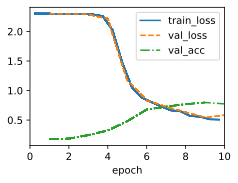

In [ ]:
model = GoogleNet(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.4.4. Discussion

A key feature of GoogLeNet is that it is actually *cheaper* to compute than its predecessors while simultaneously providing improved accuracy. This marks the beginning of a much more deliberate network design that trades off the cost of evaluating a network with a reduction in errors. It also marks the beginning of experimentation at a block level with network design hyperparameters, even though it was entirely manual at the time. We will revisit this topic in Section 8.8 when discussing strategies for network structure exploration.

Over the following sections we will encounter a number of design choices (e.g., batch normalization, residual connections, and channel grouping) that allow us to improve networks significantly. For now, you can be proud to have implemented what is arguably the first truly modern CNN.

### 8.4.5. Exercises

1. GoogLeNet was so successful that it went through a number of iterations, progressively improving speed and accuracy. Try to implement and run some of them. They include the following:
  - Add a batch normalization layer (Ioffe and Szegedy, 2015), as described later in Section 8.5.
  - Make adjustments to the Inception block (width, choice and order of convolutions), as described in Szegedy et al. (2016).
  - Use label smoothing for model regularization, as described in Szegedy et al. (2016).
  - Make further adjustments to the Inception block by adding residual connection (Szegedy et al., 2017), as described later in Section 8.6.

1. What is the minimum image size needed for GoogLeNet to work?

1. Can you design a variant of GoogLeNet that works on Fashion-MNIST's native resolution of $28 \times 28$ pixels? How would you need to change the stem, the body, and the head of the network, if anything at all?

1. Compare the model parameter sizes of AlexNet, VGG, NiN, and GoogLeNet. How do the latter two network architectures significantly reduce the model parameter size?
- 通义：AlexNet、VGG、NiN（Networks in Networks）和GoogLeNet是四个具有代表性的深度学习网络架构，它们在不同的时期推动了计算机视觉领域的发展。比较它们的模型参数大小，以及后者如何显著减少参数量，我们可以从以下几个方面进行分析：

1. AlexNet
参数大小：AlexNet由约6000万个参数组成，其中大部分集中在全连接层。
特点：使用ReLU激活函数，最大池化层，以及一个较大的卷积核（通常是9x9）。
2. VGG
参数大小：VGG系列网络（如VGG16）的参数量相对较高，通常在1亿左右，特别是深层网络。
特点：采用小卷积核（通常是3x3），深度较深（最多可达19层），并且在每个卷积层后添加ReLU激活函数和池化层。
3. NiN (Networks in Networks)
参数大小：NiN在一定程度上减少了参数量，尤其是在深度较浅的网络中。
特点：引入了深度残差结构，每个卷积层的输出是输入的叠加，使得网络可以更深层次地堆叠而不会过度拟合，同时参数量相比前代网络有所减少。
4. GoogLeNet (Inception Net)
参数大小：GoogLeNet的参数量相比前两者显著减少，尤其是在保持较高性能的前提下。
特点：引入了Inception模块，该模块内嵌多种不同大小的卷积核，通过并行路径实现多尺度特征提取，同时利用1x1卷积降低参数量和计算成本。此外，GoogLeNet还采用了全局平均池化替代全连接层，进一步减少了参数量。

如何显著减少参数量：
Inception模块：通过并行执行不同大小的卷积操作，Inception模块能够以较少的参数量实现与传统卷积层相似的特征提取能力。
1x1卷积：在Inception模块和其他网络中，使用1x1卷积层用于减少通道数，这不仅减少了参数量，还降低了计算成本。
全局平均池化：替代全连接层的全局平均池化操作，可以大幅减少参数量，同时保持模型的性能。
综上所述，GoogLeNet通过创新的Inception模块设计、高效利用1x1卷积以及全局平均池化，显著减少了模型参数量，同时保持了高性能，这是它相对于AlexNet、VGG和NiN的一个重要优势。

1. Compare the amount of computation needed in GoogLeNet and AlexNet. How does this affect the design of an accelerator chip, e.g., in terms of memory size, memory bandwidth, cache size, the amount of computation, and the benefit of specialized operations?

---
牧之：GoogLeNet 的相关代码如下，其中包含了具体的网络结构参数。假设输入为 224 x 224 x 3 大小的图像，结合上述给出的 GoogLeNet 网络参数，给出 GoogLeNet 所需的内存量数字，以及所需的运算量（FLOPs）数字。给出详细推导过程，以便我检查你的结果是否正确。

GPT4：要计算 GoogLeNet 的内存占用和运算量（FLOPs），我们需要考虑每一层的参数数量和前向传播中的运算次数。以下是如何计算这些值的概述：

内存占用

内存占用主要由网络的权重（包括卷积核和全连接层的权重）和激活（每层输出的特征图）决定。权重的内存占用可以通过计算网络中所有层的参数数量来得到。激活的内存占用取决于每层输出特征图的大小和数量。

FLOPs（浮点运算次数）

FLOPs 通常用来衡量网络的计算复杂度。对于卷积层，FLOPs 可以通过以下公式计算：
$ \text{FLOPs} = 2 \times \text{卷积核数量} \times \text{卷积核尺寸}^2 \times \text{输出特征图宽度} \times \text{输出特征图高度} \times \text{输入通道数} $

对于全连接层，FLOPs 为：
$ \text{FLOPs} = 2 \times \text{输入特征数} \times \text{输出特征数} $

现在，让我们尝试估算 GoogLeNet 的内存占用和 FLOPs。由于这是一个复杂的过程，我将概述主要步骤，而不是提供完整的详细计算。

1. 第一块（b1）:

  - LazyConv2d(64, kernel_size=7, stride=2, padding=3): 参数 = $64 \times 3 \times 7 \times 7$, 输出特征图大小 = $(224 / 2) \times (224 / 2)$
  - MaxPool2d(kernel_size=3, stride=2, padding=1): 无参数, 输出特征图大小 = $(112 / 2) \times (112 / 2)$

1. 第二块（b2）:

  - 类似地，计算每个卷积层的参数和输出特征图大小。

1. Inception模块:

  - 对于每个分支，计算参数和 FLOPs，然后将它们相加。

1. 全连接层（nn.LazyLinear(num_classes)):

  - 参数 = 输出特征数（num_classes）乘以前一层的激活数。

1. 总结:

  - 将所有层的参数相加得到总内存占用（考虑到每个参数通常需要 32 位或 4 字节的浮点数）。
  - 将所有层的 FLOPs 相加得到总 FLOPs。

由于这个过程非常繁琐，通常需要编写脚本来自动计算所有层的参数和 FLOPs。在这里，我提供了一个概述，而不是具体的数字，因为计算这些数字需要详细的层级信息和大量的计算，这通常超出了手工计算的范围。如果你需要具体的数字，你可能需要使用深度学习框架中的工具或自定义脚本来计算这些值。

牧之：输入相同大小的图像，比如 $224 \times 224 \times 3$ 的图像，AlexNet, VGG-11, NiN, 和 GoogLeNet，计算量从小到大如何排序，并说明为什么？内存占用量从小到大如何排序，并说明为什么？

GPT4：计算量和内存占用量的排序取决于网络的深度、层类型、参数数量和连接的稠密程度。以下是基于这些网络的典型架构的一般排序。

计算量（从小到大）:

1. AlexNet: 由于它的网络相对较浅（8层），并且使用了较大的卷积核（如第一层的11x11），其计算量相对较小。
1. NiN (Network in Network): NiN 使用了 1x1 卷积来减少参数数量，但是它引入了额外的 mlpconv 层，这增加了计算量。
1. GoogLeNet (Inception v1): GoogLeNet 引入了 Inception 模块，它通过并行的不同尺寸的卷积核和 3x3 的最大池化层来增加计算量，但是它的设计也考虑了计算效率。
1. VGG: VGG 网络使用了许多 3x3 的卷积层堆叠在一起，并且网络非常深（16 到 19层），这导致了很高的计算量。

内存占用量（从小到大）:

1. NiN: 尽管NiN的计算量不小，但是它通过使用 1x1 卷积来减少参数数量，因此内存占用量相对较小。
1. AlexNet: AlexNet 的参数数量多于 NiN，但是由于网络较浅，其内存占用量仍然相对较低。
1. GoogLeNet: GoogLeNet 虽然设计了很多并行的卷积分支，但是它通过 1x1 卷积降维和全局平均池化来减少参数，因此其内存占用量仍然是可控的。
1. VGG: VGG 网络有着大量的参数，特别是在它的全连接层中，这导致了非常高的内存占用量。

需要注意的是，这些排序是基于一般情况和网络的标准配置。实际的计算量和内存占用量还会受到实现方式、优化技术和硬件平台的影响。

通义：要对这些模型按照计算量（FLOPs）和内存占用量进行排序，我们需要考虑几个关键因素：模型的层数、参数量、以及它们在处理特定大小输入时的计算复杂度。

计算量（FLOPs）

1. AlexNet：AlexNet 是一个较早的模型，包含 5 个卷积层和 3 个全连接层。尽管其结构相对简单，但其计算量仍然相对较大，尤其是在处理较大输入尺寸时。AlexNet 的计算量约为约 2.5 亿 FLOPs。

1. VGG-11：VGG 系列模型以其深且薄的结构著称，VGG-11 由 11 个卷积层组成。与 AlexNet 相比，VGG-11 拥有更多的层，这意味着更多的计算量。VGG-11 的计算量大约为 14 亿 FLOPs。

1. NiN (Network in Network)：NiN 的设计理念是将多个全连接层嵌套在卷积层中，以减少参数量。NiN 在保持性能的同时，通过减少参数数量降低了计算复杂度。NiN 的计算量相对较小，大约为 1 亿 FLOPs 左右。

1. GoogLeNet (Inception V1)：GoogLeNet 引入了 Inception 模块，该模块允许模型在不同尺度上并行处理信息，同时减少了参数量。尽管 GoogLeNet 具有 Inception 模块带来的复杂性，但其整体计算量仍低于 VGG-11，大约为 8 亿 FLOPs。

内存占用量：内存占用量主要受到模型参数量的影响，同时也与模型结构有关。

1. AlexNet：虽然 AlexNet 的计算量适中，但由于其相对较大的参数量，内存占用也较大。

1. VGG-11：VGG 系列模型因其深度而著名，VGG-11 的参数量非常大，因此内存占用量也很大。

1. NiN：NiN 通过在卷积层内嵌套全连接层来减少参数量，从而降低了内存需求。NiN 的内存占用量相对较小。

1. GoogLeNet：GoogLeNet 通过 Inception 模块实现了参数共享，这有助于减少内存需求。尽 GoogLeNet 的参数量较多，但由于参数共享机制，其内存占用量相比于 VGG-11 有所降低。

综上所述，按照计算量（FLOPs）从小到大的排序为：NiN < GoogLeNet < AlexNet < VGG-11。按照内存占用量从小到大的排序为：NiN < GoogLeNet < AlexNet < VGG-11。这些排序基于模型的结构设计和参数量，实际数值可能会根据具体的实现细节有所不同。

文心：

计算量排序（从小到大）：NiN, AlexNet, VGG, GoogLeNet

解释：

1. NiN (Network in Network) 使用了 $1 \times 1$ 卷积来减少参数数量和计算量，这使得它在处理相同大小的图像时，相对于其他网络，计算量较小。

1. AlexNet 使用了较大的卷积核（如 $11 \times 11$ 和 $5 \times 5$），但总体层数较少，且使用了ReLU激活函数和Dropout来防止过拟合，其计算量相对适中。

1. VGG 网络通过堆叠多个 $3 \times 3$ 的卷积层来增加深度，这种结构虽然有效，但也增加了计算量，特别是随着层数的增加。

1. GoogLeNet (Inception 系列) 使用了 Inception 模块，这些模块内部包含了多个不同大小的卷积核（$1 \times 1$, $3 \times 3$, $5 \times 5$）和池化层，虽然 $1 \times 1$ 卷积用于减少计算量，但整体上由于多个分支的并行计算，以及更深的结构，使得其计算量最大。

内存占用量排序（从小到大）：NiN, AlexNet, VGG, GoogLeNet

解释（通常与计算量排序相似，因为计算量大的网络往往也需要更多的内存来存储中间结果和参数）：

1. NiN：如上所述，通过 $1 \times 1$ 卷积减少参数，从而减少了内存占用。

1. AlexNet：虽然使用了较大的卷积核，但总体结构相对简单，参数数量和层数适中，因此内存占用也相对较少。

1. VGG：由于堆叠了多个 $3 \times 3$ 卷积层，使得参数数量和需要存储的中间特征图增多，从而增加了内存占用。

1. GoogLeNet：Inception 模块的多分支和多种尺寸的卷积核导致网络宽度增加，需要存储更多的中间结果和参数，因此内存占用最大。

注意：这里的排序假设了所有网络都处理相同大小的输入图像，并且未考虑实现细节（如批处理大小、优化算法的内存需求等），这些因素在实际应用中也会影响内存占用。

## 8.5. Batch Normalization

Training deep neural networks is difficult. Getting them to converge in a reasonable amount of time can be tricky. In this section, we describe *batch normalization*, a popular and effective technique that consistently accelerates the convergence of deep networks (Ioffe and Szegedy, 2015). Together with residual blocks—covered later in Section 8.6—batch normalization has made it possible for practitioners to routinely train networks with over 100 layers. A secondary (serendipitous) benefit of batch normalization lies in its inherent regularization.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.5.1. Training Deep Networks

When working with data, we often preprocess before training. Choices regarding data preprocessing often make an enormous difference in the final results. Recall our application of MLPs to predicting house prices (Section 5.7). Our first step when working with real data was to standardize our input features to have zero mean $\boldsymbol{\mu} = 0$ and unit variance $\boldsymbol{\Sigma} = \boldsymbol{1}$ across multiple observations (Friedman, 1987), frequently rescaling the latter so  that the diagonal is unity, i.e., $\Sigma_{ii} = 1$. Yet another strategy is to rescale vectors to unit length, possibly zero mean *per observation*. This can work well, e.g., for spatial sensor data. These preprocessing techniques and many others, are beneficial for keeping the estimation problem well controlled. For a review of feature selection and extraction see the article of Guyon et al. (2008), for example. Standardizing vectors also has the nice side-effect of constraining the function complexity of functions that act upon it. For instance, the celebrated radius-margin bound (Vapnik, 1995) in support vector machines and the Perceptron Convergence Theorem (Novikoff, 1962) rely on inputs of bounded norm.

Intuitively, this standardization plays nicely with our optimizers since it puts the parameters *a priori* on a similar scale. As such, it is only natural to ask whether a corresponding normalization step *inside* a deep network might not be beneficial. While this is not quite the reasoning that led to the invention of batch normalization (Ioffe and Szegedy, 2015), it is a useful way of understanding it and its cousin, layer normalization (Ba et al., 2016), within a unified framework.

Second, for a typical MLP or CNN, as we train, the variables in intermediate layers (e.g., affine transformation outputs in MLP) may take values with widely varying magnitudes: whether along the layers from input to output, across units in the same layer, and over time due to our updates to the model parameters. The inventors of batch normalization postulated informally that this drift in the distribution of such variables could hamper the convergence of the network. Intuitively, we might conjecture that if one layer has variable activations that are 100 times that of another layer, this might necessitate compensatory adjustments in the learning rates. Adaptive solvers such as AdaGrad (Duchi et al., 2011), Adam (Kingma and Ba, 2014), Yogi (Zaheer et al., 2018), or Distributed Shampoo (Anil et al., 2020) aim to address this from the viewpoint of optimization, e.g., by adding aspects of second-order methods. The alternative is to prevent the problem from occurring, simply by adaptive normalization.

Third, deeper networks are complex and tend to be more liable to overfitting. This means that regularization becomes more critical. A common technique for regularization is noise injection. This has been known for a long time, e.g., with regard to noise injection for the inputs (Bishop, 1995). It also forms the basis of dropout in Section 5.6. As it turns out, quite serendipitously, batch normalization conveys all three benefits: preprocessing, numerical stability, and regularization.

Batch normalization is applied to individual layers, or optionally, to all of them: In each training iteration, we first normalize the inputs (of batch normalization) by subtracting their mean and dividing by their standard deviation, where both are estimated based on the statistics of the current minibatch. *Next, we apply a scale coefficient and an offset to recover the lost degrees of freedom*. It is precisely due to this *normalization* based on *batch* statistics that *batch normalization* derives its name.

Note that if we tried to apply batch normalization with minibatches of size 1, we would not be able to learn anything. That is because after subtracting the means, each hidden unit would take value 0. As you might guess, since we are devoting a whole section to batch normalization, with large enough minibatches the approach proves effective and stable. One takeaway here is that when applying batch normalization, the choice of batch size is even more significant than without batch normalization, or at least, suitable calibration is needed as we might adjust batch size.

Denote by $\mathcal{B}$ a minibatch and let $\mathbf{x} \in \mathcal{B}$ be an input to batch normalization ($\textrm{BN}$). In this case the batch normalization is defined as follows:

$$\textrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}. \tag{8.5.1} $$

In (8.5.1), $\hat{\boldsymbol{\mu}}_\mathcal{B}$ is the  sample mean and $\hat{\boldsymbol{\sigma}}_\mathcal{B}$ is the sample standard deviation of the minibatch $\mathcal{B}$. After applying standardization, the resulting minibatch has zero mean and unit variance. The choice of unit variance (rather than some other magic number) is arbitrary. We recover this degree of freedom by including an elementwise *scale parameter* $\boldsymbol{\gamma}$ and *shift parameter* $\boldsymbol{\beta}$ that have the same shape as $\mathbf{x}$. Both are parameters that need to be learned as part of model training.

---
牧之：注意这里所谓的“标量”是对批次这个维度来说的，$\boldsymbol{\gamma}$ 和 $\boldsymbol{\beta}$ 并不是标量。

The variable magnitudes for intermediate layers cannot diverge during training since batch normalization actively centers and rescales them back to a given mean and size (via $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$). Practical experience confirms that, as alluded to when discussing feature rescaling, batch normalization seems to allow for more aggressive learning rates. We calculate $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ in (8.5.1) as follows:

$$\hat{\boldsymbol{\mu}}_\mathcal{B} = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x} \textrm{ and } \hat{\boldsymbol{\sigma}}_\mathcal{B}^2 = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon. \tag{8.5.2} $$

Note that we add a small constant $\epsilon > 0$ to the variance estimate to ensure that we never attempt division by zero, even in cases where the empirical variance estimate might be very small or vanish. The estimates $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ counteract the scaling issue by using noisy estimates of mean and variance. You might think that this noisiness should be a problem. On the contrary, it is actually beneficial.

This turns out to be a recurring theme in deep learning. *For reasons that are not yet well-characterized theoretically, various sources of noise in optimization often lead to faster training and less overfitting: this variation appears to act as a form of regularization*. Teye et al. (2018) and Luo et al. (2018) related the properties of batch normalization to Bayesian priors and penalties, respectively. In particular, this sheds some light on the puzzle of why *batch normalization works best for moderate minibatch sizes in the 50--100 range*. This particular size of minibatch seems to inject just the "right amount" of noise per layer, both in terms of scale via $\hat{\boldsymbol{\sigma}}$, and in terms of offset via $\hat{\boldsymbol{\mu}}$: a larger minibatch regularizes less due to the more stable estimates, whereas tiny minibatches destroy useful signal due to high variance. Exploring this direction further, considering alternative types of preprocessing and filtering may yet lead to other effective types of regularization.

Fixing a trained model, you might think that we would prefer using the entire dataset to estimate the mean and variance. Once training is complete, why would we want the same image to be classified differently, depending on the batch in which it happens to reside? During training, such exact calculation is infeasible because the intermediate variables for all data examples change every time we update our model. However, once the model is trained, we can calculate the means and variances of each layer's variables based on the entire dataset. Indeed this is standard practice for models employing batch normalization; thus batch normalization layers function differently in *training mode* (normalizing by minibatch statistics) than in *prediction mode* (normalizing by dataset statistics). In this form they closely resemble the behavior of dropout regularization of Section 5.6, where noise is only injected during training.

### 8.5.2. Batch Normalization Layers

Batch normalization implementations for fully connected layers and convolutional layers are slightly different. One key difference between batch normalization and other layers is that because the former operates on a full minibatch at a time, we cannot just ignore the batch dimension as we did before when introducing other layers.

#### 8.5.2.1. Fully Connected Layers

When applying batch normalization to fully connected layers, Ioffe and Szegedy (2015), in their original paper inserted batch normalization after the affine transformation and *before* the nonlinear activation function. Later applications experimented with inserting batch normalization right *after* activation functions. Denoting the input to the fully connected layer by $\mathbf{x}$, the affine transformation by $\mathbf{W}\mathbf{x} + \mathbf{b}$ (with the weight parameter $\mathbf{W}$ and the bias parameter $\mathbf{b}$), and the activation function by $\phi$, we can express the computation of a batch-normalization-enabled, fully connected layer output $\mathbf{h}$ as follows:

$$\mathbf{h} = \phi(\textrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ). \tag{8.5.3} $$

Recall that mean and variance are computed on the *same* minibatch on which the transformation is applied.

#### 8.5.2.2. Convolutional Layers

Similarly, with convolutional layers, we can apply batch normalization after the convolution but before the nonlinear activation function. The key difference from batch normalization in fully connected layers is that we apply the operation on a per-channel basis *across all locations*. This is compatible with our assumption of translation invariance that led to convolutions: we assumed that the specific location of a pattern within an image was not critical for the purpose of understanding.

Assume that our minibatches contain $m$ examples and that for each channel, the output of the convolution has height $p$ and width $q$. For convolutional layers, we carry out each batch normalization over the $m \cdot p \cdot q$ elements per output channel simultaneously. Thus, we collect the values over all spatial locations when computing the mean and variance and consequently apply the same mean and variance within a given channel to normalize the value at each spatial location. Each channel has its own scale and shift parameters, both of which are scalars.

#### 8.5.2.3. Layer Normalization

Note that in the context of convolutions the batch normalization is well defined even for minibatches of size 1: after all, we have all the locations across an image to average. Consequently, mean and variance are well defined, even if it is just within a single observation. This consideration led Ba et al. (2016) to introduce the notion of *layer normalization*. It works just like a batch norm, only that it is applied to one observation at a time. Consequently both the offset and the scaling factor are scalars. For an $n$-dimensional vector $\mathbf{x}$, layer norms are given by

$$\mathbf{x} \rightarrow \textrm{LN}(\mathbf{x}) =  \frac{\mathbf{x} - \hat{\mu}}{\hat\sigma}, \tag{8.5.4} $$

where scaling and offset are applied coefficient-wise and given by

$$\hat{\mu} \stackrel{\textrm{def}}{=} \frac{1}{n} \sum_{i=1}^n x_i \textrm{ and } \hat{\sigma}^2 \stackrel{\textrm{def}}{=} \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2 + \epsilon. \tag{8.5.5} $$

As before we add a small offset $\epsilon > 0$ to prevent division by zero. One of the major benefits of using layer normalization is that it prevents divergence. After all, ignoring $\epsilon$, the output of the layer normalization is scale independent. That is, we have $\textrm{LN}(\mathbf{x}) \approx \textrm{LN}(\alpha \mathbf{x})$ for any choice of $\alpha \neq 0$. This becomes an equality for $|\alpha| \to \infty$ (the approximate equality is due to the offset $\epsilon$ for the variance).

Another advantage of the layer normalization is that it does not depend on the minibatch size. It is also independent of whether we are in training or test regime. In other words, *it is simply a deterministic transformation that standardizes the activations to a given scale*. This can be very beneficial in preventing divergence in optimization. We skip further details and recommend that interested readers consult the original paper.

#### 8.5.2.4. Batch Normalization During Prediction

Batch normalization implementations for fully connected layers and convolutional layers are slightly different. One key difference between batch normalization and other layers is that because the former operates on a full minibatch at a time, we cannot just ignore the batch dimension as we did before when introducing other layers.

Typically, after training, we use the entire dataset to compute stable estimates of the variable statistics and then fix them at prediction time. Hence, batch normalization behaves differently during training than at test time. Recall that dropout also exhibits this characteristic.

### 8.5.3. Implementation from Scratch

To see how batch normalization works in practice, we implement one from scratch below.

In [ ]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # Use is_grad_enabled to determine whether we are in training mode
    if not torch.is_grad_enabled():
        # In prediction mode, use mean and variance obtained by moving average
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # When using a fully connected layer, calculate the mean and
            # variance on the feature dimension
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # When using a two-dimensional convolutional layer, calculate the
            # mean and variance on the channel dimension (axis=1). Here we
            # need to maintain the shape of X, so that the broadcasting
            # operation can be carried out later
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # In training mode, the current mean and variance are used
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # Update the mean and variance using moving average
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    Y = gamma * X_hat + beta  # Scale and shift
    return Y, moving_mean.data, moving_var.data

---
牧之：注意这里返回的是 `moving_mean.data`, `moving_var.data`。

GPT：在某些深度学习框架（比如 PyTorch）中，`.data` 用于获取张量的底层数据，而不包括梯度信息。在神经网络的推理阶段，我们通常不需要梯度信息，因此返回 `moving_mean.data` 而不是 `moving_mean` 可以确保只返回张量的数值数据，而不包括梯度，这有助于减小内存占用并提高计算效率。

We can now create a proper `BatchNorm` layer. Our layer will maintain proper parameters for scale `gamma` and shift `beta`, both of which will be updated in the course of training. Additionally, our layer will maintain moving averages of the means and variances for subsequent use during model prediction.

Putting aside the algorithmic details, note the design pattern underlying our implementation of the layer. Typically, we define the mathematics in a separate function, say `batch_norm`. We then integrate this functionality into a custom layer, whose code mostly addresses bookkeeping matters, such as moving data to the right device context, allocating and initializing any required variables, keeping track of moving averages (here for mean and variance), and so on. This pattern enables a clean separation of mathematics from boilerplate code. Also note that for the sake of convenience we did not worry about automatically inferring the input shape here; thus we need to specify the number of features throughout. By now all modern deep learning frameworks offer automatic detection of size and shape in the high-level batch normalization APIs (in practice we will use this instead).

In [ ]:
class BatchNorm(nn.Module):
    # num_features: the number of outputs for a fully connected layer or the
    # number of output channels for a convolutional layer. num_dims: 2 for a
    # fully connected layer and 4 for a convolutional layer
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # The scale parameter and the shift parameter (model parameters) are
        # initialized to 1 and 0, respectively
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # The variables that are not model parameters are initialized to 0 and
        # 1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # If X is not on the main memory, copy moving_mean and moving_var to
        # the device where X is located
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # Save the updated moving_mean and moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.1)
        return Y

We used `momentum` to govern the aggregation over past mean and variance estimates. This is somewhat of a misnomer as it has nothing whatsoever to do with the *momentum* term of optimization. Nonetheless, it is the commonly adopted name for this term and in deference to API naming convention we use the same variable name in our code.

### 8.5.4. LeNet with Batch Normalization

To see how to apply BatchNorm in context, below we apply it to a traditional LeNet model (Section 7.6). Recall that batch normalization is applied after the convolutional layers or fully connected layers but *before* the corresponding activation functions.

In [ ]:
class BNLeNetScratch(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), BatchNorm(6, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), BatchNorm(16, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            BatchNorm(120, num_dims=2), nn.Sigmoid(), nn.LazyLinear(84),
            BatchNorm(84, num_dims=2), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

As before, we will train our network on the Fashion-MNIST dataset. This code is virtually identical to that when we first trained LeNet.

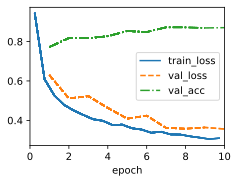

In [ ]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = BNLeNetScratch(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

Let's have a look at the scale parameter `gamma` and the shift parameter `beta` learned from the first batch normalization layer.

In [ ]:
model.net[1].gamma.reshape((-1,)), model.net[1].beta.reshape((-1,))

(tensor([1.4213, 1.8661, 1.7906, 1.6192, 2.0423, 2.1788], device='cuda:0',
        grad_fn=<ReshapeAliasBackward0>),
 tensor([-1.0647, -1.2304,  0.8536, -0.9171, -1.4074, -0.4529], device='cuda:0',
        grad_fn=<ReshapeAliasBackward0>))

### 8.5.5. Concise Implementation

Compared with the BatchNorm class, which we just defined ourselves, we can use the BatchNorm class defined in high-level APIs from the deep learning framework directly. The code looks virtually identical to our implementation above, except that we no longer need to provide additional arguments for it to get the dimensions right.

In [ ]:
class BNLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(84), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(num_classes))

Below, we use the same hyperparameters to train our model. Note that as usual, the high-level API variant runs much faster because its code has been compiled to C++ or CUDA while our custom implementation must be interpreted by Python.

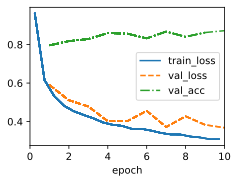

In [ ]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = BNLeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.5.6. Discussion

Intuitively, batch normalization is thought to make the optimization landscape smoother. However, we must be careful to distinguish between speculative intuitions and true explanations for the phenomena that we observe when training deep models. Recall that we do not even know why simpler deep neural networks (MLPs and conventional CNNs) generalize well in the first place. Even with dropout and weight decay, they remain so flexible that their ability to generalize to unseen data likely needs significantly more refined learning-theoretic generalization guarantees.

The original paper proposing batch normalization (Ioffe and Szegedy, 2015), in addition to introducing a powerful and useful tool, offered an explanation for why it works: by reducing *internal covariate shift*. Presumably by *internal covariate shift* they meant something like the intuition expressed above---the notion that the distribution of variable values changes over the course of training. However, there were two problems with this explanation: i) This drift is very different from *covariate shift*, rendering the name a misnomer. If anything, it is closer to concept drift. ii) The explanation offers an under-specified intuition but leaves the question of *why precisely this technique works* an open question wanting for a rigorous explanation. Throughout this book, we aim to convey the intuitions that practitioners use to guide their development of deep neural networks. However, we believe that it is important to separate these guiding intuitions from established scientific fact. Eventually, when you master this material and start writing your own research papers you will want to be clear to delineate between technical claims and hunches.

Following the success of batch normalization, its explanation in terms of *internal covariate shift* has repeatedly surfaced in debates in the technical literature and broader discourse about how to present machine learning research. In a memorable speech given while accepting a Test of Time Award at the 2017 NeurIPS conference, Ali Rahimi used *internal covariate shift* as a focal point in an argument likening the modern practice of deep learning to alchemy. Subsequently, the example was revisited in detail in a position paper outlining troubling trends in machine learning (Lipton and Steinhardt, 2018). Other authors have proposed alternative explanations for the success of batch normalization, some (Santurkar et al., 2018) claiming that batch normalization's success comes despite exhibiting behavior that is in some ways opposite to those claimed in the original paper.

We note that the *internal covariate shift* is no more worthy of criticism than any of thousands of similarly vague claims made every year in the technical machine learning literature. Likely, its resonance as a focal point of these debates owes to its broad recognizability for the target audience. Batch normalization has proven an indispensable method, applied in nearly all deployed image classifiers, earning the paper that introduced the technique tens of thousands of citations. We conjecture, though, that the guiding principles of regularization through noise injection, acceleration through rescaling and lastly preprocessing may well lead to further inventions of layers and techniques in the future.

On a more practical note, there are a number of aspects worth remembering about batch normalization:

* During model training, batch normalization continuously adjusts the intermediate output of the network by utilizing the mean and standard deviation of the minibatch, so that the values of the intermediate output in each layer throughout the neural network are more stable.

* Batch normalization is slightly different for fully connected layers than for convolutional layers. In fact, for convolutional layers, layer normalization can sometimes be used as an alternative.

* Like a dropout layer, batch normalization layers have different behaviors in training mode than in prediction mode.

* Batch normalization is useful for regularization and improving convergence in optimization. By contrast, the original motivation of reducing internal covariate shift seems not to be a valid explanation.

* For more robust models that are less sensitive to input perturbations, consider removing batch normalization (Wang et al., 2022).

### 8.5.7. Exercises

1. Should we remove the bias parameter from the fully connected layer or the convolutional layer before the batch normalization? Why?
- GPT：在深度学习中，通常应该在批量归一化（Batch Normalization）之前从全连接层中去除偏置参数（bias parameter），而不是从卷积层中去除。这是因为批量归一化包括对输入进行零均值化和归一化，这会使得偏置参数在后续的操作中失去效果。如果在全连接层中保留偏置参数，由于批量归一化的操作会将输入归一化为零均值，因此偏置的作用会被抵消。在卷积层中，每个通道都会有一个偏置项，这个偏置项会与每个像素进行相加（在卷积计算中）。批量归一化是对每个通道的输出进行归一化，因此偏置项的影响不会被抵消，因为它是针对每个通道的。因此，在卷积层中保留偏置项是合理的。

- 通义：在神经网络中，是否在批量归一化（Batch Normalization）之前从全连接层（Fully Connected Layer）或卷积层（Convolutional Layer）中移除偏置参数（Bias Parameter），这个问题并没有绝对的答案，因为这取决于具体的网络架构、任务需求以及优化目标。然而，一般而言，批量归一化后是否移除偏置参数，主要考虑以下几个方面：

1. 批量归一化的本质
批量归一化的主要目的是通过标准化每一层的输出，使得其均值接近于0，方差接近于1，从而加快训练速度并提高模型的稳定性。批量归一化本身会自动调整每个神经元的输出分布，相当于对每一层的输出进行了全局的正则化。

2. 偏置的作用
偏置参数的作用是允许每一层的输出有自由的偏移，这对于网络学习复杂的函数关系至关重要。偏置参数可以使得神经网络的输出函数更加灵活，更容易拟合数据。

3. 批量归一化后偏置的影响
独立调整：在批量归一化之后添加偏置，相当于在标准化后的输出上再进行一次局部调整。这意味着每个样本的输出都有一套独立的偏置调整，这可以增加模型的灵活性，让模型在一定程度上克服批量归一化带来的输出分布固定问题。

简化模型：移除偏置参数可以使模型更加简洁，减少参数数量，理论上可能会加速训练过程，降低过拟合的风险。然而，这也会限制模型的表达能力，可能在某些任务上影响性能。

4. 实验验证
实践中，有时会发现批量归一化后保留偏置参数可以带来更好的性能，特别是当数据分布变化较大或任务复杂度较高时。反之，移除偏置参数在某些情况下可以简化模型，提高训练效率。

结论
是否移除偏置参数，应基于具体任务的需要和实验结果来决定。一般来说，保留偏置参数可能在大多数情况下提供更好的性能，尤其是当模型需要更灵活的输出调整时。然而，对于追求简化模型、减少参数量或加速训练速度的任务，移除偏置参数是一个值得考虑的选择。最终决策应基于对特定任务的深入理解以及通过实验验证的效果。

1. Compare the learning rates for LeNet with and without batch normalization.
  - Plot the increase in validation accuracy.
  - How large can you make the learning rate before the optimization fails in both cases?

1. Do we need batch normalization in every layer? Experiment with it.
- 通义：在神经网络中，并非每个层都需要批量归一化（Batch Normalization）。批量归一化主要用于稳定和加速训练过程，特别是对于深层网络来说。它通过在每个批次的数据上对层的输出进行标准化，使得每一层的输入保持在相对稳定的分布范围内，从而减少内部协变量偏移（internal covariate shift），加速收敛，并有助于防止梯度消失或爆炸的问题。

实验分析
为了探究批量归一化是否在每个层都适用，我们可以设计几个实验：

实验1：仅在最后一层使用批量归一化
在这种情况下，批量归一化应用于模型的最后一层，即分类层之前。这样做的目的是在最终的分类决策之前，对特征进行标准化处理，这可能有助于提升模型的泛化能力，尤其是在训练集和测试集之间的数据分布差异较大的情况下。

实验2：在所有层都使用批量归一化
将批量归一化应用于模型中的每一层，包括输入层、隐藏层和输出层。这可能会导致模型在训练初期收敛得更快，因为每一步都对输入进行了标准化处理，降低了梯度的变异性。然而，这也可能引入过多的参数和计算开销，且在某些情况下，过多的标准化层可能会影响模型的性能，因为它可能使特征的自然分布变得过于“标准化”，从而丧失了一些原始特征的信息。

实验3：仅在特定层使用批量归一化
可以选择特定的隐藏层（例如，每两层或每四层应用一次批量归一化），这样可以在减少计算成本的同时，利用批量归一化的好处。这种方法可以根据模型的具体结构和任务需求进行调整。

结论
批量归一化是否适用于每个层取决于多个因素，包括但不限于模型的深度、任务的性质、数据集的特性以及硬件资源的限制。在实践中，批量归一化通常在隐藏层中较为常见，但在某些情况下，针对特定层或整个模型应用批量归一化可能会带来不同的效果。通过实验比较不同配置下的模型性能，可以更准确地确定批量归一化在模型中的最佳应用位置和数量。

1. Implement a "lite" version of batch normalization that only removes the mean, or alternatively one that only removes the variance. How does it behave?

1. Fix the parameters `beta` and `gamma`. Observe and analyze the results.

1. Can you replace dropout by batch normalization? How does the behavior change?

1. Research ideas: think of other normalization transforms that you can apply:
  - Can you apply the probability integral transform?
  - Can you use a full-rank covariance estimate? Why should you probably not do that?
  - Can you use other compact matrix variants (block-diagonal, low-displacement rank, Monarch, etc.)?
  - Does a sparsification compression act as a regularizer?
  - Are there other projections (e.g., convex cone, symmetry group-specific transforms) that you can use?

## 8.6. Residual Networks (ResNet) and ResNeXt

As we design ever deeper networks it becomes imperative to understand how adding layers can increase the complexity and expressiveness of the network. Even more important is the ability to design networks where adding layers makes networks strictly more expressive rather than just different. To make some progress we need a bit of mathematics.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 8.6.1. Function Classes

Consider $\mathcal{F}$, the class of functions that a specific network architecture (together with learning rates and other hyperparameter settings) can reach. That is, for all $f \in \mathcal{F}$ there exists some set of parameters (e.g., weights and biases) that can be obtained through training on a suitable dataset. Let's assume that $f^*$ is the "truth" function that we really would like to find. If it is in $\mathcal{F}$, we are in good shape but typically we will not be quite so lucky. Instead, we will try to find some $f^*_\mathcal{F}$ which is our best bet within $\mathcal{F}$. For instance, given a dataset with features $\mathbf{X}$ and labels $\mathbf{y}$, we might try finding it by solving the following optimization problem:

$$f^*_\mathcal{F} \stackrel{\textrm{def}}{=} \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \textrm{ subject to } f \in \mathcal{F}. \tag{8.6.1} $$

We know that regularization (Morozov, 1984, Tikhonov and Arsenin, 1977) may control complexity of $\mathcal{F}$ and achieve consistency, so a larger size of training data generally leads to better $f^*_\mathcal{F}$. It is only reasonable to assume that if we design a different and more powerful architecture $\mathcal{F}'$ we should arrive at a better outcome. In other words, we would expect that $f^*_{\mathcal{F}'}$ is "better" than $f^*_{\mathcal{F}}$. However, if $\mathcal{F} \not\subseteq \mathcal{F}'$ there is no guarantee that this should even happen. In fact, $f^*_{\mathcal{F}'}$ might well be worse. As illustrated by Fig. 8.6.1, for non-nested function classes, a larger function class does not always move closer to the "truth" function $f^*$. For instance, on the left of Fig. 8.6.1, though $\mathcal{F}_3$ is closer to $f^*$ than $\mathcal{F}_1$, $\mathcal{F}_6$ moves away and there is no guarantee that further increasing the complexity can reduce the distance from $f^*$. With nested function classes where $\mathcal{F}_1 \subseteq \cdots \subseteq \mathcal{F}_6$ on the right of Fig. 8.6.1, we can avoid the aforementioned issue from the non-nested function classes.

<p align="center">
  <img src="http://d2l.ai/_images/functionclasses.svg"/>
  <br />
  <em>Fig. 8.6.1</em> For non-nested function classes, a larger (indicated by area) function class does not guarantee we will get closer to the "truth" function ($\mathit{f}^*$). This does not happen in nested function classes.
</p>

Thus, *only if larger function classes contain the smaller ones are we guaranteed that increasing them strictly increases the expressive power of the network*. For deep neural networks, if we can train the newly-added layer into an identity function $f(\mathbf{x}) = \mathbf{x}$, the new model will be as effective as the original model. As the new model may get a better solution to fit the training dataset, the added layer might make it easier to reduce training errors.

---
牧之：如何从第一句话推导出第二句话？

GPT：第一句话指出了一个原则：只有当更大的函数类包含较小的函数类时，增加函数类的大小才能严格增加网络的表达能力。这意味着增加网络的层级或复杂度应该会增加其表达能力。

第二句话将这个原则应用到深度神经网络上。如果我们能够训练新增的层成为一个恒等函数，即 $f(\mathbf{x}) = \mathbf{x}$，这意味着新增的层不引入额外的变换，因此新模型的表达能力与原模型相同。同时，由于新增的层使得模型更复杂，它可能更容易拟合训练数据，从而降低训练误差。

This is the question that He et al. (2016) considered when working on very deep computer vision models. At the heart of their proposed *residual network* (*ResNet*) is the idea that every additional layer should more easily contain the identity function as one of its elements. These considerations are rather profound but they led to a surprisingly simple solution, a *residual block*. With it, ResNet won the ImageNet Large Scale Visual Recognition Challenge in 2015. The design had a profound influence on how to build deep neural networks. For instance, residual blocks have been added to recurrent networks (Kim et al., 2017, Prakash et al., 2016). Likewise, Transformers (Vaswani et al., 2017) use them to stack many layers of networks efficiently. It is also used in graph neural networks (Kipf and Welling, 2016) and, as a basic concept, it has been used extensively in computer vision (Redmon and Farhadi, 2018, Ren et al., 2015). Note that residual networks are predated by highway networks (Srivastava et al., 2015) that share some of the motivation, albeit without the elegant parametrization around the identity function.

### 8.6.2. Residual Blocks

Let's focus on a local part of a neural network, as depicted in Fig. 8.6.2. Denote the input by $\mathbf{x}$. We assume that $f(\mathbf{x})$, the desired underlying mapping we want to obtain by learning, is to be used as input to the activation function on the top. On the left, the portion within the dotted-line box must directly learn $f(\mathbf{x})$. On the right, the portion within the dotted-line box needs to learn the *residual mapping* $g(\mathbf{x}) = f(\mathbf{x}) - \mathbf{x}$, which is how the residual block derives its name. If the identity mapping $f(\mathbf{x}) = \mathbf{x}$ is the desired underlying mapping, the residual mapping amounts to $g(\mathbf{x}) = 0$ and it is thus easier to learn: we only need to push the weights and biases of the upper weight layer (e.g., fully connected layer and convolutional layer) within the dotted-line box to zero. The right figure illustrates the *residual block* of ResNet, where the solid line carrying the layer input $\mathbf{x}$ to the addition operator is called a *residual connection* (or *shortcut connection*). With residual blocks, inputs can forward propagate faster through the residual connections across layers. In fact, the residual block can be thought of as a special case of the multi-branch Inception block: it has two branches one of which is the identity mapping.

<p align="center">
  <img src="https://d2l.ai/_images/residual-block.svg"/>
  <br />
  <em>Fig. 8.6.2</em> In a regular block (left), the portion within the dotted-line box must directly learn the mapping $\mathit{f}(\mathbf{x})$. In a residual block (right), the portion within the dotted-line box needs to learn the residual mapping $\mathit{g}(\mathbf{x}) = \mathit{f}(\mathbf{x}) - \mathbf{x}$, making the identity mapping $\mathit{f}(\mathbf{x}) = \mathbf{x}$ easier to learn.
</p>

---
牧之：这段想可能表达两个意思：
- 这个层 $f(\mathbf{x})$ 很容易成为恒等函数 $f(\mathbf{x}) = \mathbf{x}$，由此接上上述理论内容。
- 为什么很容易成为恒等函数？因为 $g(\mathbf{x})$ 很容易训练成 0。

ResNet has VGG's full $3\times 3$ convolutional layer design. The residual block has two $3\times 3$ convolutional layers with the same number of output channels. Each convolutional layer is followed by a batch normalization layer and a ReLU activation function. Then, we skip these two convolution operations and add the input directly before the final ReLU activation function. This kind of design requires that the output of the two convolutional layers has to be of the same shape as the input, so that they can be added together. If we want to change the number of channels, we need to introduce an additional $1\times 1$ convolutional layer to transform the input into the desired shape for the addition operation. Let's have a look at the code below.

In [ ]:
class Residual(nn.Module):  #@ save
    """The Residual block of ResNet models."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1,
                                   stride=strides)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1,
                                       stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

This code generates two types of networks: one where we add the input to the output before applying the ReLU nonlinearity whenever `use_1x1conv=False`; and one where we adjust channels and resolution by means of a $1 \times 1$ convolution before adding. Fig. 8.6.3 illustrates this.

<p align="center">
  <img src="https://d2l.ai/_images/resnet-block.svg"/>
  <br />
  <em>Fig. 8.6.3</em> ResNet block with and without $1 \times 1$ convolution, which transforms the input into the desired shape for the addition operation.
</p>


Now let's look at a situation where the input and output are of the same shape, where $1 \times 1$ convolution is not needed.

In [ ]:
blk = Residual(3)
X = torch.randn(4, 3, 6, 6)
blk(X).shape

torch.Size([4, 3, 6, 6])

We also have the option to halve the output height and width while increasing the number of output channels. In this case we use $1 \times 1$ convolutions via `use_1x1conv=True`. This comes in handy at the beginning of each ResNet block to reduce the spatial dimensionality via `strides=2`.

In [ ]:
blk = Residual(6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

### 8.6.3. ResNet Model

The first two layers of ResNet are the same as those of the GoogLeNet we described before: the $7\times 7$ convolutional layer with 64 output channels and a stride of 2 is followed by the $3\times 3$ max-pooling layer with a stride of 2. The difference is the batch normalization layer added after each convolutional layer in ResNet.

In [ ]:
class ResNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

GoogLeNet uses four modules made up of Inception blocks. However, ResNet uses four modules made up of residual blocks, each of which uses several residual blocks with the same number of output channels. The number of channels in the first module is the same as the number of input channels. Since a max-pooling layer with a stride of 2 has already been used, it is not necessary to reduce the height and width. In the first residual block for each of the subsequent modules, the number of channels is doubled compared with that of the previous module, and the height and width are halved.

In [ ]:
@d2l.add_to_class(ResNet)
def block(self, num_residuals, num_channels, first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(num_channels, use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels))
    return nn.Sequential(*blk)

Then, we add all the modules to ResNet. Here, two residual blocks are used for each module. Lastly, just like GoogLeNet, we add a global average pooling layer, followed by the fully connected layer output.

In [ ]:
@d2l.add_to_class(ResNet)
def __init__(self, arch, lr=0.1, num_classes=10):
    super(ResNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, b in enumerate(arch):
        self.net.add_module(f'b{i+2}', self.block(*b, first_block=(i==0)))
    self.net.add_module('last', nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

There are four convolutional layers in each module (excluding the $1\times 1$ convolutional layer). Together with the first $7\times 7$ convolutional layer and the final fully connected layer, there are 18 layers in total. Therefore, this model is commonly known as ResNet-18. By configuring different numbers of channels and residual blocks in the module, we can create different ResNet models, such as the deeper 152-layer ResNet-152. Although the main architecture of ResNet is similar to that of GoogLeNet, *ResNet's structure is simpler and easier to modify*. All these factors have resulted in the rapid and widespread use of ResNet. Fig. 8.6.4 depicts the full ResNet-18.

<p align="center">
  <img src="https://d2l.ai/_images/resnet18-90.svg"/>
  <br />
  <em>Fig. 8.6.4</em> The ResNet-18 architecture.
</p>

Before training ResNet, let's observe how the input shape changes across different modules in ResNet. As in all the previous architectures, the resolution decreases while the number of channels increases up until the point where a global average pooling layer aggregates all features.

---
牧之：总共 4 个 residual block，每个 residual block 有 2 个 residual module，每个 residual module 有 2 个 convolutional layer，如此有 16 个 convolutional layer。加上头部有 1 个 convolutional layer，输出部分有 1 个全连接层，共有 18 层。

In [ ]:
class ResNet18(ResNet):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(((2, 64), (2, 128), (2, 256), (2, 512)),
                       lr, num_classes)

ResNet18().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 128, 12, 12])
Sequential output shape:	 torch.Size([1, 256, 6, 6])
Sequential output shape:	 torch.Size([1, 512, 3, 3])
Sequential output shape:	 torch.Size([1, 10])


### 8.6.4. Training

We train ResNet on the Fashion-MNIST dataset, just like before. ResNet is quite a powerful and flexible architecture. The plot capturing training and validation loss illustrates a significant gap between both graphs, with the training loss being considerably lower. For a network of this flexibility, more training data would offer distinct benefit in closing the gap and improving accuracy.

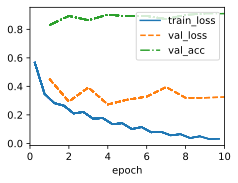

In [ ]:
model = ResNet18(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.6.5. ResNeXt

One of the challenges one encounters in the design of ResNet is the trade-off between nonlinearity and dimensionality within a given block. That is, we could add more nonlinearity by increasing the number of layers, or by increasing the width of the convolutions. An alternative strategy is to increase the number of channels that can carry information between blocks. Unfortunately, the latter comes with a quadratic penalty since the computational cost of ingesting $c_\textrm{i}$ channels and emitting $c_\textrm{o}$ channels is proportional to $\mathcal{O}(c_\textrm{i} \cdot c_\textrm{o})$ (see our discussion in Section 7.4).

We can take some inspiration from the Inception block of Fig. 8.4.1 which has information flowing through the block in separate groups. Applying the idea of multiple independent groups to the ResNet block of Fig. 8.6.3 led to the design of ResNeXt (Xie et al., 2017). Different from the smorgasbord of transformations in Inception, ResNeXt adopts the *same* transformation in all branches, thus minimizing the need for manual tuning of each branch.

<p align="center">
  <img src="https://d2l.ai/_images/resnext-block.svg"/>
  <br />
  <em>Fig. 8.6.5</em> The ResNeXt block. The use of grouped convolution with $\mathit{g}$ groups is $\mathit{g}$ times faster than a dense convolution. It is a bottleneck residual block when the number of intermediate channels $\mathit{b}$ is less than $\mathit{c}$.
</p>

Breaking up a convolution from $c_\textrm{i}$ to $c_\textrm{o}$ channels into one of $g$ groups of size $c_\textrm{i}/g$ generating $g$ outputs of size $c_\textrm{o}/g$ is called, quite fittingly, a *grouped convolution*. The computational cost (proportionally) is reduced from $\mathcal{O}(c_\textrm{i} \cdot c_\textrm{o})$ to $\mathcal{O}(g \cdot (c_\textrm{i}/g) \cdot (c_\textrm{o}/g)) = \mathcal{O}(c_\textrm{i} \cdot c_\textrm{o} / g)$, i.e., it is $g$ times faster. Even better, the number of parameters needed to generate the output is also reduced from a $c_\textrm{i} \times c_\textrm{o}$ matrix to $g$ smaller matrices of size $(c_\textrm{i}/g) \times (c_\textrm{o}/g)$, again a $g$ times reduction. In what follows we assume that both $c_\textrm{i}$ and $c_\textrm{o}$ are divisible by $g$.

The only challenge in this design is that no information is exchanged between the $g$ groups. The ResNeXt block of Fig. 8.6.5 amends this in two ways: the grouped convolution with a $3 \times 3$ kernel is sandwiched in between two $1 \times 1$ convolutions. The second one serves double duty in changing the number of channels back. The benefit is that we only pay the $\mathcal{O}(c \cdot b)$ cost for $1 \times 1$ kernels and can make do with an $\mathcal{O}(b^2 / g)$ cost for $3 \times 3$ kernels. Similar to the residual block implementation in Section 8.6.2, the residual connection is replaced (thus generalized) by a $1 \times 1$ convolution.

The right-hand figure in Fig. 8.6.5 provides a much more concise summary of the resulting network block. It will also play a major role in the design of generic modern CNNs in Section 8.8. Note that the idea of grouped convolutions dates back to the implementation of AlexNet (Krizhevsky et al., 2012). When distributing the network across two GPUs with limited memory, the implementation treated each GPU as its own channel with no ill effects.

The following implementation of the `ResNeXtBlock` class takes as argument `groups` ($g$), with `bot_channels` ($b$) intermediate (bottleneck) channels. Lastly, when we need to reduce the height and width of the representation, we add a stride of $2$ by setting `use_1x1conv=True, strides=2`.

---
牧之：为什么在各自分组内叠加一个 $3 \times 3$ 卷积可以应对 $g$ 个分组间没有信息交换的挑战？

- GPT：在各自分组内叠加一个 $3 \times 3$ 卷积可以应对 $g$ 个分组间没有信息交换的挑战，主要因为这种设计增强了每个分组内部特征的表达能力。通过在各分组内部引入 $3 \times 3$ 卷积，每个分组都能更好地学习到自身特征的表示，从而提高了模型对于每个分组内部特征的抽取能力。尽管并没有直接促进分组间的信息交换，但整体上加强了每个分组内部的特征学习，有助于提高模型整体的表达能力，从而部分弥补了 $g$ 个分组间信息交换不足的问题。

- 通义：在神经网络设计中，特别是在深度卷积神经网络（如 ResNeXt）中，通过将一个 $3 \times 3$ 卷积放置在两个 $1 \times 1$ 卷积之间，可以有效地解决不同分组间缺乏信息交换的问题。这种结构的引入主要基于以下几个原因：

    1. 增加局部特征提取能力：$3 \times 3$ 卷积块能够对输入特征图进行局部的、密集的特征提取，这对于图像识别任务来说非常重要。它能够捕捉到像素间的空间关系和上下文信息，从而增强模型对局部结构的理解。

    1. 控制参数量：通过将 $3 \times 3$ 卷积与 $1 \times 1$ 卷积结合使用，可以在保持模型复杂度的同时，减少计算成本。特别是，使用 $1 \times 1$ 卷积来调整通道数（即特征图的维度），这使得模型能够在不显著增加参数数量的情况下，灵活地改变通道数，以适应不同的层或网络需求。

    1. 减少计算成本：相对于直接使用多个独立的 $3 \times 3$ 卷积层，使用 $1 \times 1$ 卷积和 $3 \times 3$ 卷积的组合可以显著降低计算复杂度。具体而言，$1 \times 1$ 卷积的成本是 $\mathcal{O}(c \cdot b)$，而 $3 \times 3$ 卷积的成本为 $\mathcal{O}(b^2 / g)$，其中 $c$ 是通道数，$b$ 是每个通道的宽度，$g$ 是分组的数量。这样，通过合理分配计算资源，可以在保持模型性能的同时，优化计算效率。

    1. 信息传递：虽然原始设计中可能存在不同分组间的信息交换不足的问题，但通过这种结构的改进，$3 \times 3$ 卷积层可以促进内部不同通道之间的信息流动，尽管是在分组内部。这有助于在网络中传播更丰富的特征表示，从而提高整体模型的性能。

    1. 残差连接的替代：在 ResNeXt 中，通常会使用残差连接来帮助梯度的反向传播，以及提升网络的训练稳定性。通过用 $1 \times 1$ 卷积来实现类似的功能，可以更加灵活地处理不同通道的数量变化，而不必依赖于传统的残差连接方式。

  综上所述，通过在分组内部使用$3 \times 3$卷积并结合$1 \times 1$卷积，不仅能够增强模型的局部特征提取能力，还能够有效管理计算成本，同时促进信息在不同通道间的流动，从而应对分组间信息交换不足的挑战。

- 文心：在深度学习中，特别是在卷积神经网络（CNN）中，分组卷积（Grouped Convolution）是一种减少计算量和参数数量的有效方法。然而，当使用分组卷积时，每个分组内的特征图（feature maps）仅在该分组内部进行卷积操作，这导致不同分组之间的信息无法直接交换。这种信息隔离可能会限制模型的学习能力和泛化能力。

  为了应对这一挑战，ResNeXt块的设计中引入了几个关键元素，特别是通过在分组卷积前后添加$1 \times 1$卷积层，以及使用残差连接（通过$1 \times 1$卷积实现）来增强信息流动。具体来说，为什么叠加一个$3 \times 3$分组卷积可以应对分组间没有信息交换的挑战，可以从以下几个方面理解：

    1. 信息聚合前的预处理：第一个 $1 \times 1$ 卷积层的主要作用是对输入特征图进行降维（如果其输出通道数小于输入通道数）或变换，以便更好地适应后续的分组卷积。这个步骤有助于将输入特征图映射到一个更适合进行分组处理的空间中，虽然它本身并不直接解决分组间的信息隔离问题，但为后续的信息交换提供了基础。

    1. 分组卷积的局部处理：$3 \times 3$ 分组卷积在每个分组内独立地进行卷积操作，虽然它本身不直接促进分组间的信息交换，但它在每个分组内部有效地提取了局部特征。这些局部特征在后续的步骤中可能会被进一步整合和利用。

    1. 信息聚合后的后处理：第二个 $1 \times 1$ 卷积层的主要作用是对分组卷积的输出进行聚合和变换。这个步骤不仅可以将不同分组的输出特征图在通道维度上进行合并（如果其输出通道数大于输入通道数），更重要的是，它允许模型学习如何将来自不同分组的特征信息进行整合。这种整合过程实际上是在不同分组之间间接地实现了信息交换。

    1. 残差连接的信息流动：通过 $1 \times 1$ 卷积实现的残差连接进一步增强了信息流动。残差连接允许输入特征图直接跳过分组卷积部分，与分组卷积的输出相加。这种设计不仅有助于缓解深层网络中的梯度消失问题，还促进了信息在不同层次和不同分组之间的流动，从而在一定程度上缓解了分组间信息隔离的问题。

  综上所述，虽然 $3 \times 3$ 分组卷积本身并不直接解决分组间信息交换的问题，但通过结合前后的 $1 \times 1$ 卷积层以及残差连接的设计，ResNeXt 块能够有效地促进信息在不同分组和不同层次之间的流动和整合，从而应对分组间没有信息交换的挑战。

In [ ]:
class ResNeXtBlock(nn.Module):  #@ save
    """The ResNeXt block."""
    def __init__(self, num_channels, groups, bot_mul, use_1x1conv=False,
                 strides=1):
        super().__init__()
        bot_channels = int(round(num_channels * bot_mul))
        self.conv1 = nn.LazyConv2d(bot_channels, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(bot_channels, kernel_size=3,
                                   stride=strides, padding=1,
                                   groups=bot_channels//groups)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=1)
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
        if use_1x1conv:
            self.conv4 = nn.LazyConv2d(num_channels, kernel_size=1,
                                       stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = F.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        if self.conv4:
            X = self.bn4(self.conv4(X))
        return F.relu(Y + X)

---
牧之：bot_mul 到底是什么？使用中应该如何设置？最好给出一个示例。

- 通义：bot_mul（branch output multiplier）是一个在神经网络架构设计中使用的参数，它用来控制中间层（例如在 ResNeXt 或其他类似架构中）的通道数相对于输入或输出通道数的比例。bot_mul 常常用来调整模型的宽度，即中间层的通道数，从而影响模型的复杂度和计算需求。

  在实践中，bot_mul 的值通常是一个介于 0 和 1 之间的实数，具体选择取决于你想要调整模型的宽度、计算成本以及对性能的影响。较大的 bot_mul 值会导致更多的通道，这意味着模型在该层有更多的参数，可能会提高模型的表达能力，但也可能增加计算成本和训练时间。较小的 bot_mul 值则会减少通道数，降低模型的复杂度和计算需求，但可能限制其在某些任务上的表现。

  假设我们正在设计一个 ResNeXt 模型，目标是处理一个具有 in_channels 输入通道数的数据集，最终需要输出 out_channels 通道数的特征图。如果我们希望在模型的某个阶段增加宽度，我们可以使用 bot_mul 来控制这个增加的程度。

  实际应用示例：假设我们有一个输入通道数 in_channels = 64，希望最终输出通道数 out_channels = 256，并且我们选择在模型的某个阶段增加宽度。如果我们决定使用 bot_mul = 2，这意味着我们希望在该阶段的中间层（例如 conv2 层）的通道数是 in_channels 的两倍。这样，bot_channels 将等于 in_channels * bot_mul = 64 * 2 = 128。

  这样，我们的 conv2 层就会有 128 个通道，这将使得模型在这一层的宽度相比输入增加了一倍，从而可能提升模型在某些任务上的表现，同时需要权衡计算成本和训练时间。在实际应用中，选择合适的 bot_mul 值通常需要根据具体任务的需求、硬件资源的限制以及实验结果来进行调整。

牧之：conv2 这一层是不是在卷积的同时，其内部实现了分组和串接的过程，因为我没有在代码中看到分组和串接代码。

- 通义：self.conv2 层定义的是一个卷积操作，它实际上并不直接执行“分组”和“串接”的过程。然而，通过特定的参数设置，它确实能够在一定程度上模拟分组卷积（grouped convolution）的效果，从而实现类似于分组和串接的操作。

  在 PyTorch 中，nn.Conv2d 或者 nn.LazyConv2d 的 groups 参数是用来控制分组卷积的。当 groups 设置为输入通道数的子集时，这个卷积层会被视为进行了分组卷积。在上述代码片段中，groups 被设置为 bot_channels//groups，这意味着它会将输入通道按照某种比例分成多个组。例如，如果 bot_channels 是 128，而 groups 是 2，那么每个组将有 64 个通道。在卷积操作中，输入数据将被分割成与 groups 相同数量的子张量，每个子张量负责与相应的权重进行卷积操作。这样，每个输出通道只与输入通道中的一部分相关联，从而减少了计算量和参数数量。

  至于“串接”（concatenation），它通常指的是将多个独立的模型输出或者数据流合并在一起。在卷积层内，groups 参数并没有直接实现这种串接操作。在卷积层之后，如果有后续的层（比如 self.conv3 和 self.bn3）需要处理多个独立的通道流，那么这通常是在这些后续层中通过线性组合或拼接操作完成的。

  总之，self.conv2 层通过 groups 参数实现了分组卷积的效果，但这并不自动执行数据的串接。数据的串接通常发生在模型的后续层中，或者在模型外部通过编程逻辑实现。

牧之：重点说明 groups=bot_channels//groups 为什么要这么设置？

- 通义：groups=bot_channels//groups 的设置是基于 ResNeXt 架构的关键特性之一。ResNeXt 使用分组卷积来增加模型的宽度（即通道数），同时通过调整分组的数量来控制模型的复杂度和计算成本。通过将 bot_channels 除以 groups，我们得到每个分组的通道数，从而实现不同分组间的通道共享，这有助于模型在保持参数数量的同时，通过增加通道数来提升表征能力。

  具体来说，bot_channels 是根据 num_channels 和 bot_mul 计算得出的，它代表了在 conv2 层使用的通道数。然后，bot_channels//groups 计算出每个分组应该有多少通道。这样做确保了即使在高通道数的情况下，也能通过分组的方式有效地管理计算资源，避免过拟合，并且能够利用深度学习模型的局部特征学习能力。

  总的来说，groups=bot_channels//groups 的设置是 ResNeXt 架构中为了优化模型的宽度、复杂度和计算效率而设计的关键部分。它允许模型在保持较高计算效率的同时，通过分组卷积来增加模型的容量和性能。

Its use is entirely analogous to that of the `ResNetBlock` discussed previously. For instance, when using (`use_1x1conv=False, strides=1`), the input and output are of the same shape. Alternatively, setting `use_1x1conv=True, strides=2` halves the output height and width.

In [ ]:
blk = ResNeXtBlock(32, 16, 1)
X = torch.randn(4, 32, 96, 96)
blk(X).shape

torch.Size([4, 32, 96, 96])

### 8.6.6. Summary and Discussion

Nested function classes are desirable since they allow us to obtain strictly *more powerful* rather than also subtly *different* function classes when adding capacity. One way of accomplishing this is by letting additional layers to simply pass through the input to the output. Residual connections allow for this. *As a consequence, this changes the inductive bias from simple functions being of the form $f(\mathbf{x}) = 0$ to simple functions looking like $f(\mathbf{x}) = \mathbf{x}$*.

---
牧之：反映在实现上是如此简单，反映在认知上却是如此深刻！

The residual mapping can learn the identity function more easily, such as pushing parameters in the weight layer to zero. We can train an effective *deep* neural network by having residual blocks. Inputs can forward propagate faster through the residual connections across layers. As a consequence, we can thus train much deeper networks. For instance, the original ResNet paper (He et al., 2016) allowed for up to 152 layers. Another benefit of residual networks is that it allows us to add layers, initialized as the identity function, *during* the training process. After all, the default behavior of a layer is to let the data pass through unchanged. This can accelerate the training of very large networks in some cases.

---
牧之：这里为什么要强调 during 训练过程中？

- GPT：强调在训练过程中添加层初始化为恒等函数的重要原因在于，这种做法使得网络可以更快速地学习复杂的特征表示。通过在训练过程中添加恒等函数初始化的层，可以加速网络的收敛过程，更快地实现深度网络的训练。这样做还能够有效地避免梯度消失或爆炸的问题，并且有助于提升网络对数据的表示能力，从而加快训练速度。

- 通义：在训练过程中强调添加层（初始化为恒等函数）的原因，主要是因为这种策略有助于解决深度神经网络训练中遇到的几个关键问题：

  1. 梯度消失和梯度爆炸：随着网络深度的增加，梯度在反向传播过程中可能会迅速减小（梯度消失）或增大（梯度爆炸），这使得深层网络难以学习。通过引入残差连接，可以更容易地学习到更深层次的表示，从而减轻了梯度消失的问题。

  1. 表达能力：更深的网络通常具有更强的表达能力，能够捕捉到更复杂的特征。然而，直接堆叠更多的层可能导致训练困难。通过在训练过程中动态添加初始化为恒等函数的层，可以逐步增加网络的复杂性，而不会一开始就面临过大的计算和优化挑战。

  1. 训练稳定性：残差网络的设计允许层在训练初期保持数据不变（即恒等函数的行为）。这可以作为初始训练阶段的一种保护机制，帮助模型更快地收敛。随着训练的进行，这些层逐渐学习到有用的转换，而不是仅仅作为简单的通道。

  1. 可扩展性：这种方法使得构建和训练非常深的网络成为可能，而不仅仅是依靠固定的层数结构。例如，在原始ResNet论文中提到的152层网络，正是通过在训练过程中动态添加层实现的。

  1. 加速训练：由于残差连接允许输入数据直接跳过某些层，这实际上加快了数据的前向传播速度。这对于大规模网络尤为重要，因为它减少了需要计算的步骤数量，从而节省了训练时间。

  综上所述，强调在训练过程中添加层，是因为这种方式结合了残差网络设计的关键优势，如更好地处理梯度、增强表达能力、提高训练稳定性和扩展性，并且可能加速大规模网络的训练过程。

Prior to residual connections, bypassing paths with gating units were introduced to effectively train highway networks with over 100 layers (Srivastava et al., 2015). Using identity functions as bypassing paths, ResNet performed remarkably well on multiple computer vision tasks. Residual connections had a major influence on the design of subsequent deep neural networks, of either convolutional or sequential nature. As we will introduce later, the Transformer architecture (Vaswani et al., 2017) adopts residual connections (together with other design choices) and is pervasive in areas as diverse as language, vision, speech, and reinforcement learning.

ResNeXt is an example for how the design of convolutional neural networks has evolved over time: by being more frugal with computation and trading it off against the size of the activations (number of channels), it allows for faster and more accurate networks at lower cost. An alternative way of viewing grouped convolutions is to think of a block-diagonal matrix for the convolutional weights. Note that there are quite a few such "tricks" that lead to more efficient networks. For instance, ShiftNet (Wu et al., 2018) mimicks the effects of a $3 \times 3$ convolution, simply by adding shifted activations to the channels, offering increased function complexity, this time without any computational cost.

A common feature of the designs we have discussed so far is that the network design is fairly manual, primarily relying on the ingenuity of the designer to find the "right" network hyperparameters. While clearly feasible, it is also very costly in terms of human time and there is no guarantee that the outcome is optimal in any sense. In Section 8.8 we will discuss a number of strategies for obtaining high quality networks in a more automated fashion. In particular, we will review the notion of *network design spaces* that led to the RegNetX/Y models (Radosavovic et al., 2020).

### 8.6.7. Exercises

1. What are the major differences between the Inception block in Fig. 8.4.1 and the residual block? How do they compare in terms of computation, accuracy, and the classes of functions they can describe?
- 通义：Inception 块和残差块（Residual Block）是两种在深度学习领域中广泛使用的网络模块，它们各自在设计思想、计算效率、准确性和描述的函数类方面存在显著差异。

  Inception块的主要特点：

  - 多尺度特征提取：Inception 块通过组合不同大小的卷积核（例如 1x1、3x3、5x5），同时包含了一个 1x1 卷积层用于减少输入通道数，以此来实现多尺度特征的高效提取。
  - 并行路径：它采用并行路径设计，将多个不同的卷积操作并排放置，然后通过一个 1x1 卷积层将所有路径的输出合并。这种设计使得模型能够并行处理不同尺度的信息，提高了模型的并行性和计算效率。
  - 参数效率：Inception 块通过减少输入通道数的 1x1 卷积来降低计算量，同时保持模型的深度，因此在一定程度上提高了参数效率。

  残差块的主要特点：

  - 恒等映射：残差块的核心思想是引入恒等映射（identity mapping），即通过跳过连接（skip connection）直接将输入传递给输出，同时通过一个简单的操作（通常是 1x1 卷积）对输入进行调整。
  - 深度学习：通过跳过连接，残差块允许模型学习更加复杂的非线性函数，即使在增加网络深度时也能保持良好的训练性能。
  - 梯度传播：残差块通过跳过连接帮助缓解了梯度消失问题，使得深层网络更容易训练。

  计算效率比较：

  - Inception 块：通过并行路径和 1x1 卷积减少计算量，整体上具有较高的计算效率。
  - 残差块：虽然每个残差块本身可能计算量较大，但由于引入了跳过连接，使得整个网络的计算量分布更加合理，避免了深度增加导致的计算负担。

  准确性比较：

  - Inception 块：通过多尺度特征提取，Inception 块在保持模型复杂度的同时，通常能提供较好的准确性，尤其是在图像分类任务上表现出色。
  - 残差块：残差块在深层网络训练上的优势使其在保持网络深度的同时，往往能获得更高的准确性，尤其是在处理复杂的视觉任务时。

  描述的函数类比较：

  - Inception 块：倾向于通过多尺度特征提取来描述更为全面的函数，适用于需要综合不同尺度信息的任务。
  - 残差块：更专注于学习深层的非线性函数，通过跳过连接允许网络学习更复杂的函数关系，特别适合于深度网络的构建。

  总之，Inception 块和残差块在设计目标、计算效率、准确性和描述的函数类上各有侧重，具体选择取决于特定任务的需求和资源限制。

1. Refer to Table 1 in the ResNet paper (He et al., 2016) to implement different variants of the network.

1. For deeper networks, ResNet introduces a “bottleneck” architecture to reduce model complexity. Try to implement it.

1. In subsequent versions of ResNet, the authors changed the “convolution, batch normalization, and activation” structure to the “batch normalization, activation, and convolution” structure. Make this improvement yourself. See Figure 1 in He et al. (2016) for details.

牧之：为什么要这么修改？

- 通义：在后续版本的 ResNet 中，作者将“卷积、批归一化、激活”（Convolution -> Batch Normalization -> Activation）的顺序修改为了“批归一化、激活、卷积”（Batch Normalization -> Activation -> Convolution）。这种修改的主要原因是为了改善模型的训练稳定性和效果，以下是详细的解释：

  1. 激活先于卷积的好处：激活函数的作用是引入非线性，使得神经网络能够学习复杂的函数关系。如果激活函数在卷积操作之前应用，那么每个卷积操作将基于激活函数的输出进行，这意味着卷积层的权重更新会依赖于非线性变换的结果。这样，每个神经元的输出将首先通过激活函数进行非线性转换，然后再经过卷积操作，这可以使得模型更容易学习到更丰富的特征表示。

  1. 减少训练难度：在批归一化之后应用激活函数可以减少训练的难度。批归一化主要用于标准化每一层的输入，使其分布接近于标准正态分布，这有助于加速训练并提高模型的泛化能力。如果在批归一化之后应用激活函数，可以使得激活函数在更稳定的输入上工作，这有助于减少梯度消失或爆炸的问题，从而提高模型的训练稳定性。

  1. 增强模型的非线性表达能力：将激活函数放在批归一化之后，意味着模型可以在更均匀、稳定的数据分布上学习非线性关系。这不仅有助于提高模型的非线性表达能力，还可能有助于避免某些特定数据分布下的过拟合问题。

  1. 优化权重更新：在批归一化之后应用激活函数，可以使得权重更新更加平稳。批归一化的输出在很大程度上消除了输入数据的统计波动，这有助于在权重更新过程中减少噪声，从而使得模型在训练过程中能够更加平稳地收敛。

  总的来说，这种修改策略旨在通过优化神经网络内部的计算流程，提高模型的训练效率和效果，特别是在处理大规模数据集和深度网络结构时，能够带来显著的性能提升。

1. Why can’t we just increase the complexity of functions without bound, even if the function classes are nested?

- 通义：我们不能无限制地增加函数的复杂性，即使函数类是嵌套的，有几个原因：

  1. 计算资源限制：计算机的硬件资源（如内存、CPU 周期）是有限的。即使理论上可以定义出越来越复杂的函数，但在实际操作中，我们需要在有限的计算资源下运行这些函数。增加函数的复杂性意味着需要更多的计算资源，超出我们的硬件限制。

  1. 过拟合风险：增加函数的复杂性意味着模型可以拟合训练数据中的更多细节，包括噪音和异常值。当模型过于复杂时，它可能会过度拟合训练数据，即学习到了训练数据中的特定模式而非一般规律。这会导致模型在新数据上的表现变差，即泛化能力下降。

  1. 训练难度：更复杂的函数往往需要更多的参数，这增加了模型的训练难度。例如，高阶多项式函数、深度神经网络等都可能因为参数过多而导致训练不稳定，出现梯度消失或爆炸等问题。

  1. 解释性问题：更复杂的函数往往难以理解和解释。在许多应用场景中，比如医疗诊断、金融决策等，我们希望模型的决策过程是透明的，便于人类理解。复杂的函数可能导致模型变得“黑盒”，难以解析其决策逻辑。

  1. 数据量限制：并非所有问题都有足够的数据来支持更复杂的模型。对于某些问题，尤其是数据稀缺的情况，增加函数复杂性可能无法带来显著的性能提升，反而会增加过拟合的风险。

  1. 理论限制：从数学和统计学的角度来看，存在一些理论框架（如VC 维理论、泛化误差理论等）表明，存在某种形式的“复杂性限制”。这些理论提供了关于模型复杂性与泛化能力之间关系的指导原则。

  综上所述，尽管理论上可以定义出无限复杂的函数，但在实际应用中，我们需要考虑计算资源、过拟合风险、训练难度、解释性、数据量以及理论限制等因素，以确保模型的有效性和实用性。

## 8.7. Densely Connected Networks (DenseNet)

ResNet significantly changed the view of how to parametrize the functions in deep networks. *DenseNet* (dense convolutional network) is to some extent the logical extension of this (Huang et al., 2017). DenseNet is characterized by both the connectivity pattern where each layer connects to all the preceding layers and the concatenation operation (rather than the addition operator in ResNet) to preserve and reuse features from earlier layers. To understand how to arrive at it, let's take a small detour to mathematics.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.7.1. From ResNet to DenseNet

Recall the Taylor expansion for functions. At the point $x = 0$ it can be written as

$$f(x) = f(0) + x \cdot \left[f'(0) + x \cdot \left[\frac{f''(0)}{2!}  + x \cdot \left[\frac{f'''(0)}{3!}  + \cdots \right]\right]\right]. \tag{8.7.1}$$

The key point is that it decomposes a function into terms of increasingly higher order. In a similar vein, ResNet decomposes functions into

$$f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}). \tag{8.7.2}$$

That is, ResNet decomposes $f$ into a simple linear term and a more complex nonlinear one. What if we wanted to capture (not necessarily add) information beyond two terms? One such solution is DenseNet (Huang et al., 2017).

<p align="center">
  <img src="https://d2l.ai/_images/densenet-block.svg"/>
  <br />
  <em>Fig. 8.7.1</em> The main difference between ResNet (left) and DenseNet (right) in cross-layer connections: use of addition and use of concatenation.
</p>


As shown in Fig. 8.7.1, the key difference between ResNet and DenseNet is that in the latter case outputs are *concatenated* (denoted by $[,]$) rather than added. As a result, we perform a mapping from $\mathbf{x}$ to its values after applying an increasingly complex sequence of functions:

$$\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), f_3\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right), f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right)\right]\right), \ldots\right]. \tag{8.7.3}$$

In the end, all these functions are combined in MLP to reduce the number of features again. In terms of implementation this is quite simple:
rather than adding terms, we concatenate them. The name DenseNet arises from the fact that the dependency graph between variables becomes quite dense. The final layer of such a chain is densely connected to all previous layers. The dense connections are shown in Fig. 8.7.2.

<p align="center">
  <img src="http://d2l.ai/_images/densenet.svg"/>
  <br />
  <em>Fig. 8.7.2</em> Dense connections in DenseNet. Note how the dimensionality increases with depth.
</p>

---
牧之：再一次，反映在实现上是如此简单，反映在认知上却是如此深刻！一个可能的启示：如果一个“不起眼”的动作有用，那么，这里最大的发现不是这个动作，而是“不起眼”。它之所以不起眼，可能在于你没有真正理解它。

The main components that comprise a DenseNet are *dense blocks* and *transition layers*. The former define how the inputs and outputs are concatenated, while the latter control the number of channels so that it is not too large, since the expansion $\mathbf{x} \to \left[\mathbf{x}, f_1(\mathbf{x}), f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), \ldots \right]$ can be quite high-dimensional.

### 8.7.2. Dense Blocks

DenseNet uses the modified "batch normalization, activation, and convolution" structure of ResNet (see the exercise in Section 8.6). First, we implement this convolution block structure.

In [ ]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

A *dense block* consists of multiple convolution blocks, each using the same number of output channels. In the forward propagation, however, we concatenate the input and output of each convolution block on the channel dimension. Lazy evaluation allows us to adjust the dimensionality automatically.

In [ ]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # Concatenate input and output of each block along the channels
            X = torch.cat((X, Y), dim=1)
        return X

In the following example, we define a `DenseBlock` instance with two convolution blocks of 10 output channels. When using an input with three channels, we will get an output with  $3 + 10 + 10=23$ channels. The number of convolution block channels controls the growth in the number of output channels relative to the number of input channels. This is also referred to as the *growth rate*.

In [ ]:
blk = DenseBlock(2, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

### 8.7.3. Transition Layers

Since each dense block will increase the number of channels, adding too many of them will lead to an excessively complex model. A *transition layer* is used to control the complexity of the model. It reduces the number of channels by using a $1\times 1$ convolution. Moreover, it halves the height and width via average pooling with a stride of 2.

In [ ]:
def transition_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

Apply a transition layer with 10 channels to the output of the dense block in the previous example.  This reduces the number of output channels to 10, and halves the height and width.

In [ ]:
blk = transition_block(10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

### 8.7.4. DenseNet Model

Next, we will construct a DenseNet model. DenseNet first uses the same single convolutional layer and max-pooling layer as in ResNet.

In [ ]:
class DenseNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

Then, similar to the four modules made up of residual blocks that ResNet uses, DenseNet uses four dense blocks. As with ResNet, we can set the number of convolutional layers used in each dense block. Here, we set it to 4, consistent with the ResNet-18 model in Section 8.6. Furthermore, we set the number of channels (i.e., growth rate) for the convolutional layers in the dense block to 32, so 128 channels will be added to each dense block.

In ResNet, the height and width are reduced between each module by a residual block with a stride of 2. Here, we use the transition layer to halve the height and width and halve the number of channels. Similar to ResNet, a global pooling layer and a fully connected layer are connected at the end to produce the output.

In [ ]:
@d2l.add_to_class(DenseNet)
def __init__(self, num_channels=64, growth_rate=32, arch=(4, 4, 4, 4),
             lr=0.1, num_classes=10):
    super(DenseNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, num_convs in enumerate(arch):
        self.net.add_module(f'dense_blk{i+1}', DenseBlock(num_convs,
                                                          growth_rate))
        # The number of output channels in the previous dense block
        num_channels += num_convs * growth_rate
        # A transition layer that halves the number of channels is added
        # between the dense blocks
        if i != len(arch) - 1:
            num_channels //= 2
            self.net.add_module(f'tran_blk{i+1}', transition_block(
                num_channels))
    self.net.add_module('last', nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

---
牧之：觉得这里的代码有些问题。self.b1 的初始化应该要接受 num_channels 参数控制。当前 self.b1 的输出通道是固定 64。

### 8.7.5. Training

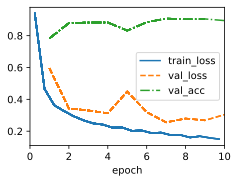

In [ ]:
model = DenseNet(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

### 8.7.6. Summary and Discussion

The main components that comprise DenseNet are dense blocks and transition layers. For the latter, we need to keep the dimensionality under control when composing the network by adding transition layers that shrink the number of channels again. In terms of cross-layer connections, in contrast to ResNet, where inputs and outputs are added together, DenseNet concatenates inputs and outputs on the channel dimension. Although these concatenation operations reuse features to achieve computational efficiency, unfortunately they lead to heavy GPU memory consumption. As a result, applying DenseNet may require more memory-efficient implementations that may increase training time (Pleiss et al., 2017).

### 8.7.7. Exercises

1. Why do we use average pooling rather than max-pooling in the transition layer?

- GPT：在 DenseNet 中使用平均池化而不是最大池化是为了避免信息丢失。平均池化有助于保留更多的特征信息，这对于 DenseNet 中密集连接的特征传递至关重要。最大池化可能会丢失一些细节信息，因此在这种情况下，平均池化更适合用于过渡层。

- 通义：在 DenseNet 中，我们使用平均池化（average pooling）而不是最大池化（max-pooling）作为过渡层的主要原因如下：

  1. 平滑效果：平均池化能够平滑特征图，使得后续的层能够接收较为平滑的输入。这种平滑效果有助于在更深的网络层次中减少噪声的影响，提高模型的稳定性。

  1. 信息整合：DenseNet 的一个关键特性是密集连接（dense connections），即每一层的输出都直接连接到网络中的所有后续层。平均池化可以帮助整合更多的信息，因为它是对局部区域的平均值计算，这意味着它能够综合考虑该区域内的所有信息，而不仅仅是最大值或最小值。

  1. 特征分布：相比于最大池化可能强调局部最显著的特征，平均池化提供了更均衡的特征分布。这对于那些依赖于多个特征进行决策的任务来说可能是有益的，因为它避免了对单个极端值的过度依赖。

  1. 计算效率：尽管平均池化相对于最大池化在计算上可能稍显复杂，但在 DenseNet 这样的架构中，考虑到密集连接的特性，其影响可能被优化的网络结构所抵消。平均池化仍然能够提供有效的降采样同时保持足够的信息量。

  1. 防止过拟合：通过使用平均池化，可以在一定程度上减少模型对特定局部特征的过度依赖，从而有助于防止过拟合，使模型在面对未见过的数据时有更好的泛化能力。

  总之，在 DenseNet 中使用平均池化作为过渡层，主要是为了提升模型的平滑性、信息整合能力、特征分布的均衡性以及整体的计算效率和泛化能力。这些特性对于构建高效且具有强大表示学习能力的深度网络至关重要。

- 文心：在 DenseNet 的过渡层（Transition Layer）中使用平均池化（Average Pooling）而非最大池化（Max Pooling）的原因主要有以下几点：

  1. 特征保留：平均池化能够保留更多的背景信息和整体特征，而不仅仅是局部区域的最大值。在 DenseNet 中，特征复用和特征传递是非常重要的，通过平均池化，可以在过渡层减少特征图（Feature Map）的尺寸时，尽可能保留更全面的特征信息，有助于后续层次更好地进行特征提取和融合。

  1. 减少参数和计算量：虽然池化操作本身并不直接减少网络参数，但它通过减小特征图的尺寸，间接地减少了后续卷积层需要处理的参数数量和计算量。在 DenseNet 这种具有密集连接的网络结构中，参数和计算量的控制尤为重要。平均池化作为一种有效的降维手段，可以在保持网络性能的同时，减少不必要的计算负担。

  1. 防止过拟合：平均池化通过引入更多的背景信息，有助于增强网络的泛化能力，从而在一定程度上防止过拟合。虽然过拟合的防止更多依赖于正则化、dropout 等手段，但平均池化作为网络结构的一部分，也在某种程度上起到了类似的作用。

  1. 与 DenseNet 的设计理念相契合：DenseNet 的设计理念是通过密集连接实现特征复用和增强特征传递。在过渡层使用平均池化可以更好地与这一理念相契合，因为它能够保留更多的整体特征信息，有利于后续层次之间的特征传递和融合。

  综上所述，DenseNet 在过渡层使用平均池化而非最大池化，主要是为了在保持网络性能的同时，更好地保留整体特征信息、减少参数和计算量、防止过拟合，并与 DenseNet 的设计理念相契合。

1. One of the advantages mentioned in the DenseNet paper is that its model parameters are smaller than those of ResNet. Why is this the case?

- GPT4：DenseNet（密集连接网络）的设计哲学与 ResNet（残差网络）有显著不同，这导致了参数数量上的差异。以下是影响参数数量的主要因素：

  1. 特征复用：DenseNet 的核心在于每一层都直接与前面的所有层相连，这意味着特征图（feature maps）被高效复用。由于每一层都可以访问前面层的特征，因此不需要再次学习这些特征，这减少了额外参数的需求。

  1. 连接方式：在 DenseNet 中，每个层的输出不是简单地与下一个层的输入相加（像 ResNet 那样），而是在通道维度上与后续层的输入进行拼接（concatenation），这样做能够更加节省参数，因为不需要为了匹配维度而增加卷积层的数量。

  1. 生长率（Growth Rate）：DenseNet 引入了一个称为生长率的概念（通常记为 k）。每一层仅产生 k 个特征图，这是一个相对较小的数值。因此，即便网络很深，参数的增长也是线性的，而不是指数型的，这与特征复用的理念相符合。

  1. 参数效率：在 DenseNet 中，由于使用了特征复用，每一层都可以获取到之前所有层的信息，因此单个卷积层可以设计得更加轻量级。此外，由于前面层的特征可以被后面的层直接利用，每层可以使用较少的特征图，这也减少了参数数量。

  1. 过渡层（Transition Layers）：DenseNet 使用过渡层来控制特征图的数量，通过 1x1 的卷积和 2x2 的平均池化来减少特征图的维度。这种设计进一步提高了参数的效率。

  综上所述，DenseNet 通过特征复用、生长率控制和有效的网络连接方式，在保持或提升性能的同时，减少了模型的参数总数。而 ResNet 通常需要更多参数来学习残差映射，并且每个残差块中的卷积层通常生成更多的特征图（与 DenseNet 的生长率相比）。因此，这就是为什么 DenseNet 可以在参数数量上有优势的原因。

- 通义：DenseNet（密集网络）和 ResNet（残差网络）都是深度学习领域中非常重要的架构，它们在设计上都旨在解决深度神经网络训练过程中的梯度消失或梯度爆炸问题，并且都取得了显著的成功。

  ResNet 的参数大小

  - ResNet 通过引入“残差块”来解决深度网络训练中的问题。在 ResNet 中，每一层输出不仅包含当前层的输入经过非线性变换的结果，还包含了直接从输入传递到下一层的结果。这种设计允许模型构建非常深的网络，而不会导致梯度消失或爆炸的问题。每个残差块通常由一个或多个卷积层组成，后接一个跳连接（即输入层直接连接到输出层），这样使得模型能够学习更深层次的特征表示而不受深度的限制。

  DenseNet 的参数大小

  - DenseNet 的设计目的是在保持模型深度的同时，减少参数量。DenseNet 的核心思想是将每一层的输出与网络中所有后续层的输入进行直接连接，形成所谓的“稠密连接”。这意味着每一层都与网络中的所有后续层共享信息，从而避免了在 ResNet 中需要多次跳过连接来实现信息传递。这种设计使得模型能够更有效地利用信息流，减少冗余计算，并通过共享特征来降低参数数量。

  参数大小的原因

  - 共享特征：DenseNet 中的稠密连接允许信息在层间高效流动，减少了重复学习同一特征的需要，因此可以使用较少的参数达到相同的效果。
  - 信息聚合：由于每一层都与后续的所有层相连，DenseNet 可以更有效地聚合来自不同层的信息，这减少了需要独立参数来捕获这些信息的需求。
  - 模块化结构：DenseNet 的模块化结构允许在不增加大量额外参数的情况下，通过添加更多的层来增加网络的深度，从而提高了模型的表达能力。

  综上所述，DenseNet 相对于 ResNet 而言，在保持或增强性能的同时，通过其独特的连接方式和信息聚合机制，能够实现较小的参数量。这种设计上的差异使得 DenseNet 在保持复杂度的同时，能够提供更高的效率和更低的计算成本。

- 文心：DenseNet 相比 ResNet 在模型参数方面更小的优势，主要源于其独特的网络结构和连接方式。以下是对这一优势的详细分析：

  1. 密集连接机制

    DenseNet 通过密集连接（Dense Connections）来构建网络，即每个层的输入不仅来自其直接的前一层，还来自前面所有层的输出。这种连接方式带来了两个主要的好处：

    - 特征复用：由于每个层都可以利用前面所有层的特征，DenseNet 能够有效地复用特征，从而减少了每一层需要学习的特征数量。相比之下，ResNet 虽然通过残差连接（Residual Connections）也加强了特征的传递，但其连接方式没有 DenseNet 那么密集。

    - 参数效率：由于特征复用，DenseNet 的每一层只需学习“新的”特征，这些新特征与前面所有层的特征一起传递给后续层。这种机制使得 DenseNet 能够在达到与 ResNet 相似性能的同时，使用更少的参数。具体来说，DenseNet 中的每个层产生的特征图（Feature Maps）数量相对较少，因为这些特征图需要与前面所有层的特征图进行拼接（Concatenation），如果数量过多，会导致参数量和计算量急剧增加。

  2. 网络结构设计

    DenseNet 的网络结构也进一步减少了模型参数：

    - 瓶颈层（Bottleneck Layers）：DenseNet 中的每个 Dense Block 都包含多个卷积层，这些卷积层之间通过瓶颈层（通常是 1x1 卷积）进行连接。瓶颈层的主要作用是减少输入特征图的数量，从而降低后续卷积层的参数量和计算量。这种设计使得 DenseNet 能够在保持较高性能的同时，控制模型的复杂度。

    - 过渡层（Transition Layers）：DenseNet 中的过渡层负责降低特征图的尺寸和数量，以便在后续 Dense Block 中继续进行处理。过渡层通常包括一个 1x1 卷积层和一个平均池化层（或最大池化层，但平均池化更为常见）。平均池化层通过计算特征图区域的平均值来降低特征图的尺寸，同时保留更多的背景信息和整体特征，有助于减少后续层的参数和计算量。

  3. 实验结果验证

    实验结果表明，DenseNet 在多个数据集上达到了与 ResNet 相似的性能，但所需的参数量和计算量却显著减少。例如，在 ImageNet 分类数据集上，达到同样的准确率时，DenseNet 所需的参数量不到 ResNet 的一半。这充分证明了 DenseNet 在参数效率方面的优势。

    综上所述，DenseNet 通过其独特的密集连接机制和高效的网络结构设计，实现了在保持高性能的同时减少模型参数的目标。这使得 DenseNet 在实际应用中具有更高的灵活性和可扩展性，尤其适用于那些对模型大小和计算资源有严格要求的场景。

1. One problem for which DenseNet has been criticized is its high memory consumption.
  - Is this really the case? Try to change the input shape to $224 \times 224$  to compare the actual GPU memory consumption empirically.
  - Can you think of an alternative means of reducing the memory consumption? How would you need to change the framework?

- 通义：减少内存消耗的替代方法：
  1. 批量规范化（Batch Normalization）：虽然不是直接减少内存消耗的方法，但它可以加速训练过程，减少模型需要优化的参数数量，间接地减少了内存需求。

  1. 权重共享：在某些情况下，可以通过设计模型结构来共享权重，特别是在卷积层中，通过使用较小的卷积核或者特定的架构设计（如在 ResNet 中使用 1x1 卷积来减少通道数）。

  1. 模型量化：将模型的权重从浮点数转换为整数，例如使用 8 位精度的权重，可以显著减少存储需求。

  1. 剪枝和稀疏化：移除模型中很少使用的权重，或者让一些权重保持为零，可以减少模型的大小和内存需求。

  1. 动态图执行：在某些框架中，动态图执行可以更有效地管理内存，特别是在模型执行过程中，动态图可以避免不必要的中间结果存储。

  1. 模型压缩：使用模型压缩技术，如知识蒸馏、模型剪枝、模型量化等，可以生成更小、更快的模型版本，同时保持较高的性能。

  在实施这些策略时，需要根据实际的硬件资源、模型性能要求以及优化目标来选择最合适的方法。

- 文心：DenseNet（密集连接网络）因其密集的连接方式而闻名，这种设计极大地提高了信息的流动和特征的重用，但同时也带来了较高的内存消耗问题。为了减少 DenseNet 的内存消耗，可以考虑以下几种替代方法，并相应地调整框架：

  1. 减少特征图的数量（Growth Rate）：

    - DenseNet 中的 growth rate 决定了每一层新产生的特征图数量。减小这个值会直接影响网络中新特征图的数量，从而减少内存消耗。
    - 实现上，可以在定义 DenseBlock 时设置较小的 growth rate 值。

  1. 使用瓶颈层（Bottleneck Layers）：

    - 在每个 DenseBlock 内部的层之前引入 1x1 的卷积层作为瓶颈层，可以大幅减少输入到每个密集层的特征图数量，进而降低内存占用。
    - 瓶颈层将高维特征压缩成低维表示，然后再进行正常的卷积操作，这有助于在不显著降低性能的情况下减少内存使用。

  1. 降低特征图的分辨率：

    - 通过在网络的早期阶段使用步长大于 1 的卷积层或池化层来降低特征图的尺寸，可以减少后续层的内存占用。
    - 这种方法需要仔细设计网络结构，以确保在降低分辨率的同时，仍能保留足够的信息以维持网络的性能。

  1. 使用分组卷积（Group Convolutions）：

    - 将特征图分成几个组，然后在每个组内独立进行卷积操作。这种方法可以显著减少参数量和计算量，从而可能降低内存消耗。
    - 在 DenseNet 中，可以在某些层或整个网络中使用分组卷积来减少内存占用。

  1. 优化内存分配和管理：

    - 使用更高效的内存管理技术，如自动内存管理或内存池技术，来减少内存碎片和不必要的内存占用。
    - 编写内存感知的代码，尽可能减少不必要的内存复制和临时变量的使用。

  1. 利用硬件加速：

    - 利用 GPU 等硬件加速技术来优化计算过程，虽然这不一定直接减少内存消耗，但可以通过加快计算速度来减少整体运行时间，从而可能间接减少内存占用（例如，通过减少因等待数据加载而占用的内存）。

  通过上述方法中的一种或多种组合，可以在不显著降低 DenseNet 性能的情况下，有效地降低其内存消耗。当然，具体选择哪种方法或哪些方法的组合，需要根据实际应用场景和网络结构的具体需求来决定。

1. Implement the various DenseNet versions presented in Table 1 of the DenseNet paper (Huang et al., 2017).

1. Design an MLP-based model by applying the DenseNet idea. Apply it to the housing price prediction task in Section 5.7.

## 8.8. Designing Convolution Network Architectures

The previous sections have taken us on a tour of modern network design for computer vision. Common to all the work we covered was that it greatly relied on the intuition of scientists. Many of the architectures are heavily informed by human creativity and to a much lesser extent by systematic exploration of the design space that deep networks offer. Nonetheless, this *network engineering* approach has been tremendously successful.

Ever since AlexNet (Section 8.1) beat conventional computer vision models on ImageNet, it has become popular to construct very deep networks by stacking blocks of convolutions, all designed according to the same pattern. In particular, $3 \times 3$ convolutions were popularized by VGG networks (Section 8.2). NiN (Section 8.3) showed that even $1 \times 1$ convolutions could be beneficial by adding local nonlinearities. Moreover, NiN solved the problem of aggregating information at the head of a network by aggregating across all locations. GoogLeNet (Section 8.4) added multiple branches of different convolution width, combining the advantages of VGG and NiN in its Inception block. ResNets (Section 8.6) changed the inductive bias towards the identity mapping (from $f(x) = 0$). This allowed for very deep networks. Almost a decade later, the ResNet design is still popular, a testament to its design. Lastly, ResNeXt (Section 8.6.5) added grouped convolutions, offering a better trade-off between parameters and computation. A precursor to Transformers for vision, the Squeeze-and-Excitation Networks (SENets) allow for efficient information transfer between locations (Hu et al., 2018). This was accomplished by computing a per-channel global attention function.

Up to now we have omitted networks obtained via *neural architecture search* (NAS) (Liu et al., 2018, Zoph and Le, 2016). We chose to do so since their cost is usually enormous, relying on brute-force search, genetic algorithms, reinforcement learning, or some other form of hyperparameter optimization. Given a fixed search space, NAS uses a search strategy to automatically select an architecture based on the returned performance estimation. The outcome of NAS is a single network instance. EfficientNets are a notable outcome of this search (Tan and Le, 2019).

In the following we discuss an idea that is quite different to the quest for the *single best network*. It is computationally relatively inexpensive, it leads to scientific insights on the way, and it is quite effective in terms of the quality of outcomes. Let's review the strategy by Radosavovic et al. (2020) to *design network design spaces*. The strategy combines the strength of manual design and NAS. It accomplishes this by operating on *distributions of networks* and optimizing the distributions in a way to obtain good performance for entire families of networks. The outcome of it are *RegNets*, specifically RegNetX and RegNetY, plus a range of guiding principles for the design of performant CNNs.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 8.8.1. The AnyNet Design Space

The description below closely follows the reasoning in Radosavovic et al. (2020) with some abbreviations to make it fit in the scope of the book. To begin, we need a template for the family of networks to explore. One of the commonalities of the designs in this chapter is that the networks consist of a *stem*, a *body* and a *head*. The stem performs initial image processing, often through convolutions with a larger window size. The body consists of multiple blocks, carrying out the bulk of the transformations needed to go from raw images to object representations. Lastly, the head converts this into the desired outputs, such as via a softmax regressor for multiclass classification. The body, in turn, consists of multiple stages, operating on the image at decreasing resolutions. In fact, both the stem and each subsequent stage quarter the spatial resolution. Lastly, each stage consists of one or more blocks. This pattern is common to all networks, from VGG to ResNeXt. Indeed, for the design of generic AnyNet networks, Radosavovic et al. (2020) used the ResNeXt block of Fig. 8.6.5.

<p align="center">
  <img src="http://d2l.ai/_images/anynet.svg"/>
  <br />
  <em>Fig. 8.8.1</em> The AnyNet design space. The numbers $(\mathit{c}, \mathit{r})$ along each arrow indicate the number of channels $c$ and the resolution $\mathit{r} \times \mathit{r}$ of the images at that point. From left to right: generic network structure composed of stem, body, and head; body composed of four stages; detailed structure of a stage; two alternative structures for blocks, one without downsampling and one that halves the resolution in each dimension. Design choices include depth $\mathit{d_i}$, the number of output channels $\mathit{c_i}$, the number of groups $\mathit{g_i}$, and bottleneck ratio $\mathit{k_i}$ for any stage $\mathit{i}$.
</p>

Let’s review the structure outlined in Fig. 8.8.1 in detail. As mentioned, an AnyNet consists of a stem, body, and head. The stem takes as its input RGB images (3 channels), using a $3 \times 3$ convolution with a stride of $2$, followed by a batch norm, to halve the resolution from $r \times r$ to $r/2 \times r/2$. Moreover, it generates $c_0$ channels that serve as input to the body.

Since the network is designed to work well with ImageNet images of shape $224 \times 224 \times 3$, the body serves to reduce this to $7 \times 7 \times c_4$ through 4 stages (recall that $224 / 2^{1+4} = 7$), each with an eventual stride of $2$. Lastly, the head employs an entirely standard design via global average pooling, similar to NiN (Section 8.3), followed by a fully connected layer to emit an $n$-dimensional vector for $n$-class classification.

Most of the relevant design decisions are inherent to the body of the network. It proceeds in stages, where each stage is composed of the same type of ResNeXt blocks as we discussed in Section 8.6.5. The design there is again entirely generic: we begin with a block that halves the resolution by using a stride of $2$ (the rightmost in Fig. 8.8.1). To match this, the residual branch of the ResNeXt block needs to pass through a $1 \times 1$ convolution. This block is followed by a variable number of additional ResNeXt blocks that leave both resolution and the number of channels unchanged. Note that a common design practice is to add a slight bottleneck in the design of convolutional blocks. As such, with bottleneck ratio $k_i \geq 1$ we afford some number of channels, $c_i/k_i$,  within each block for stage $i$ (as the experiments show, this is not really effective and should be skipped). Lastly, since we are dealing with ResNeXt blocks, we also need to pick the number of groups $g_i$ for grouped convolutions at stage $i$.

This seemingly generic design space provides us nonetheless with many parameters: we can set the block width (number of channels) $c_0, \ldots c_4$, the depth (number of blocks) per stage $d_1, \ldots d_4$, the bottleneck ratios $k_1, \ldots k_4$, and the group widths (numbers of groups) $g_1, \ldots g_4$. In total this adds up to 17 parameters, resulting in an unreasonably large number of configurations that would warrant exploring. We need some tools to reduce this huge design space effectively. This is where the conceptual beauty of design spaces comes in. Before we do so, let's implement the generic design first.

---
牧之：bottleneck ratio $\mathit{k_i}$ 是什么？举个例子。

通义：在 AnyNet 设计空间中，参数 $\mathit{k_i}$ 被称为瓶颈比率（Bottleneck Ratio）。这个概念主要用于控制网络中特定阶段（stage）的卷积层的结构，旨在平衡计算效率和模型性能之间的关系。

具体来说，一个标准的卷积层通常会包含一系列的运算，比如卷积操作、激活函数应用、可能的池化操作等。而瓶颈层则是这种结构的一种变体，其中卷积层的输出通道数（即通道数量）相比输入通道数和输出特征图大小的乘积要小得多。这样做的目的是为了减少参数量和计算量，特别是在大型网络中，这可以显著降低模型的计算成本和内存需求，同时还能帮助缓解过拟合问题。

例如，假设在一个阶段 $i$ 中，我们有一个标准的卷积层，其输入通道数为 $c_i$，输出通道数为 $c_i / k_i$，并且输出特征图的尺寸为 $r \times r$。如果 $k_i = 2$，那么输出通道数将是 $c_i / 2$，这意味着相对于输入，输出通道数被减半。这就可以视为一个瓶颈层，因为它在保持网络的深度和复杂度的同时，降低了参数量和计算需求。

通过调整 $\mathit{k_i}$，设计者可以在模型的计算效率和性能之间找到一个合适的平衡点。通常，较高的 $\mathit{k_i}$ 值意味着更轻量级的网络，但可能需要更多的训练数据或更复杂的网络结构来达到相同的性能水平；较低的 $\mathit{k_i}$ 值则可能允许模型在较少的数据上训练得到更好的性能，但计算成本会更高。

In [ ]:
class AnyNet(d2l.Classifier):
    def stem(self, num_channels):
        return nn.Sequential(
            nn.LazyConv2d(num_channels, kernel_size=3, stride=2, padding=1),
            nn.LazyBatchNorm2d(), nn.ReLU())

Each stage consists of `depth` ResNeXt blocks, where `num_channels` specifies the block width. Note that the first block halves the height and width of input images.

In [ ]:
@d2l.add_to_class(AnyNet)
def stage(self, depth, num_channels, groups, bot_mul):
    blk = []
    for i in range(depth):
        if i == 0:
            blk.append(d2l.ResNeXtBlock(num_channels, groups, bot_mul,
                use_1x1conv=True, strides=2))
        else:
            blk.append(d2l.ResNeXtBlock(num_channels, groups, bot_mul))
    return nn.Sequential(*blk)

Putting the network stem, body, and head together, we complete the implementation of AnyNet.

In [ ]:
@d2l.add_to_class(AnyNet)
def __init__(self, arch, stem_channels, lr=0.1, num_classes=10):
    super(AnyNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.stem(stem_channels))
    for i, s in enumerate(arch):
        self.net.add_module(f'stage{i+1}', self.stage(*s))
    self.net.add_module('head', nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

### 8.8.2. Distributions and Parameters of Design Spaces

As just discussed in Section 8.8.1, parameters of a design space are hyperparameters of networks in that design space. Consider the problem of identifying good parameters in the AnyNet design space. We could try finding the *single best* parameter choice for a given amount of computation (e.g., FLOPs and compute time). If we allowed for even only *two* possible choices for each parameter, we would have to explore $2^{17} = 131072$ combinations to find the best solution. This is clearly infeasible because of its exorbitant cost. Even worse, we do not really learn anything from this exercise in terms of how one should design a network. Next time we add, say, an X-stage, or a shift operation, or similar, we would need to start from scratch. Even worse, due to the stochasticity in training (rounding, shuffling, bit errors), no two runs are likely to produce exactly the same results. A better strategy would be to try to determine general guidelines of how the choices of parameters should be related. For instance, the bottleneck ratio, the number of channels, blocks, groups, or their change between layers should ideally be governed by a collection of simple rules. The approach in Radosavovic et al. (2019) relies on the following four assumptions:

1. We assume that general design principles actually exist, so that many networks satisfying these requirements should offer good performance. Consequently, identifying a *distribution* over networks can be a sensible strategy. In other words, we assume that there are many good needles in the haystack.

1. We need not train networks to convergence before we can assess whether a network is good. Instead, it is sufficient to use the intermediate results as reliable guidance for final accuracy. Using (approximate) proxies to optimize an objective is referred to as multi-fidelity optimization (Forrester et al., 2007). Consequently, design optimization is carried out, based on the accuracy achieved after only a few passes through the dataset, reducing the cost significantly.

1. Results obtained at a smaller scale (for smaller networks) generalize to larger ones. Consequently, optimization is carried out for networks that are structurally similar, but with a smaller number of blocks, fewer channels, etc. Only in the end will we need to verify that the so-found networks also offer good performance at scale.

1. Aspects of the design can be approximately factorized so that it is possible to infer their effect on the quality of the outcome somewhat independently. In other words, the optimization problem is moderately easy.

These assumptions allow us to test many networks cheaply. In particular, we can *sample* uniformly from the space of configurations and evaluate their performance. Subsequently, we can evaluate the quality of the choice of parameters by reviewing the *distribution* of error/accuracy that can be achieved with said networks. Denote by $F(e)$ the cumulative distribution function (CDF) for errors committed by networks of a given design space, drawn using probability disribution $p$. That is,

$$F(e, p) \stackrel{\textrm{def}}{=} P_{\textrm{net} \sim p} \{e(\textrm{net}) \leq e\}. \tag{8.8.1}$$

Our goal is now to find a distribution $p$ over *networks* such that most networks have a very low error rate and where the support of $p$ is concise. Of course, this is computationally infeasible to perform accurately. We resort to a sample of networks $\mathcal{Z} \stackrel{\textrm{def}}{=} \{\textrm{net}_1, \ldots \textrm{net}_n\}$ (with errors $e_1, \ldots, e_n$, respectively) from $p$ and use the empirical CDF $\hat{F}(e, \mathcal{Z})$ instead:

$$\hat{F}(e, \mathcal{Z}) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}(e_i \leq e). \tag{8.8.2}$$

Whenever the CDF for one set of choices majorizes (or matches) another CDF it follows that its choice of parameters is superior (or indifferent). Accordingly Radosavovic et al. (2020) experimented with a shared network bottleneck ratio $k_i = k$ for all stages $i$ of the network. This gets rid of three of the four parameters governing the bottleneck ratio. To assess whether this (negatively) affects the performance one can draw networks from the constrained and from the unconstrained distribution and compare the corresonding CDFs. It turns out that this constraint does not affect the accuracy of the distribution of networks at all, as can be seen in the first panel of Fig. 8.8.2. Likewise, we could choose to pick the same group width $g_i = g$ occurring at the various stages of the network. Again, this does not affect performance, as can be seen in the second panel of Fig. 8.8.2. Both steps combined reduce the number of free parameters by six.

<p align="center">
  <img src="https://d2l.ai/_images/regnet-fig.png"/>
  <br />
  <em>Fig. 8.8.2</em> Comparing error empirical distribution functions of design spaces. $\textrm{AnyNet}_\mathit{A}$ is the original design space; $\textrm{AnyNet}_\mathit{B}$ ties the bottleneck ratios, $\textrm{AnyNet}_\mathit{C}$ also ties group widths, $\textrm{AnyNet}_\mathit{D}$ increases the network depth across stages. From left to right: (i) tying bottleneck ratios has no effect on performance; (ii) tying group widths has no effect on performance; (iii) increasing network widths (channels) across stages improves performance; (iv) increasing network depths across stages improves performance. Figure courtesy of Radosavovic et al. (2020).
</p>

Next we look for ways to reduce the multitude of potential choices for width and depth of the stages. It is a reasonable assumption that, as we go deeper, the number of channels should increase, i.e., $c_i \geq c_{i-1}$ ($w_{i+1} \geq w_i$ per their notation in Fig. 8.8.2), yielding $\textrm{AnyNetX}_D$. Likewise, it is equally reasonable to assume that as the stages progress, they should become deeper, i.e., $d_i \geq d_{i-1}$, yielding $\textrm{AnyNetX}_E$. This can be experimentally verified in the third and fourth panel of Fig. 8.8.2, respectively.

---
牧之：Both steps combined reduce the number of free parameters by six. 这是因为从 $k_1, \ldots k_4$ 变成了 $k$，从 $g_1, \ldots g_4$ 变成了 $g$。

### 8.8.3. RegNet

The resulting $\textrm{AnyNetX}_E$ design space consists of simple networks
following easy-to-interpret design principles:

* Share the bottleneck ratio $k_i = k$ for all stages $i$;
* Share the group width $g_i = g$ for all stages $i$;
* Increase network width across stages: $c_{i} \leq c_{i+1}$;
* Increase network depth across stages: $d_{i} \leq d_{i+1}$.

This leaves us with a final set of choices: how to pick the specific values for the above parameters of the eventual $\textrm{AnyNetX}_E$ design space. By studying the best-performing networks from the distribution in $\textrm{AnyNetX}_E$ one can observe the following: the width of the network ideally increases linearly with the block index across the network, i.e., $c_j \approx c_0 + c_a j$, where $j$ is the block index and slope $c_a > 0$. Given that we get to choose a different block width only per stage, we arrive at a piecewise constant function, engineered to match this dependence. Furthermore, experiments also show that a bottleneck ratio of $k = 1$ performs best, i.e., we are advised not to use bottlenecks at all.

We recommend the interested reader reviews further details in the design of specific networks for different amounts of computation by perusing Radosavovic et al. (2020). For instance, an effective 32-layer RegNetX variant is given by $k = 1$ (no bottleneck), $g = 16$ (group width is 16), $c_1 = 32$ and $c_2 = 80$ channels for the first and second stage, respectively, chosen to be $d_1=4$ and $d_2=6$ blocks deep. The astonishing insight from the design is that it still applies, even when investigating networks at a larger scale. Even better, it even holds for Squeeze-and-Excitation (SE) network designs (RegNetY) that have a global channel activation (Hu et al., 2018).

In [ ]:
class RegNetX32(AnyNet):
    def __init__(self, lr=0.1, num_classes=10):
        stem_channels, groups, bot_mul = 32, 16, 1
        depths, channels = (4, 6), (32, 80)
        super().__init__(
            ((depths[0], channels[0], groups, bot_mul),
             (depths[1], channels[1], groups, bot_mul)),
            stem_channels, lr, num_classes)

We can see that each RegNetX stage progressively reduces resolution and increases output channels.

In [ ]:
RegNetX32().layer_summary((1, 1, 96, 96))

### 8.8.4. Training

Training the 32-layer RegNetX on the Fashion-MNIST dataset is just like before.

In [ ]:
model = RegNetX32(lr=0.05)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

### 8.8.5. Discussion

With desirable inductive biases (assumptions or preferences) like locality and translation invariance (Section 7.1) for vision, CNNs have been the dominant architectures in this area. This remained the case from LeNet up until Transformers (Section 11.7) (Dosovitskiy et al., 2021, Touvron et al., 2021) started surpassing CNNs in terms of accuracy. While much of the recent progress in terms of vision Transformers *can* be backported into CNNs (Liu et al., 2022), it is only possible at a higher computational cost. Just as importantly, recent hardware optimizations (NVIDIA Ampere and Hopper) have only widened the gap in favor of Transformers.

It is worth noting that Transformers have a significantly lower degree of inductive bias towards locality and translation invariance than CNNs. That learned structures prevailed is due, not least, to the availability of large image collections, such as LAION-400m and LAION-5B (Schuhmann et al., 2022) with up to 5 billion images. Quite surprisingly, some of the more relevant work in this context even includes MLPs (Tolstikhin et al., 2021).

In sum, vision Transformers (Section 11.8) by now lead in terms of state-of-the-art performance in large-scale image classification, showing that *scalability trumps inductive biases* (Dosovitskiy et al., 2021). This includes pretraining large-scale Transformers (Section 11.9) with multi-head self-attention (Section 11.5). We invite the readers to dive into these chapters for a much more detailed discussion.

---
牧之：综合你了解的全部知识，不必局限于上述段落提供的信息，Transformers 对局部性和平移不变性的归纳偏差程度明显低于 CNN的表现是什么？是什么原因造成了这个现象？

- GPT：Transformers 相对于 CNNs 对局部性和平移不变性的归纳偏差较低，原因在于它们依赖自注意力机制，能够捕捉数据中的长程依赖关系。相比之下，CNNs 则使用特定的架构假设来强制实现局部性和平移不变性，而 Transformers 更多地依赖数据本身学习这些特征。Transformers 能够捕捉输入序列中的长程依赖关系和元素之间的关联，这使得它们相对于 CNNs 在对局部性和平移不变性特征的偏差较低。

- 文心：Transformers 相对于卷积神经网络（CNNs）在局部性和平移不变性方面的归纳偏差程度明显较低，这一现象主要源自两者的架构设计差异及其处理数据的方式。原因分析：
  1. 架构设计差异：

    - CNNs：通过卷积层（Convolutional Layers）和池化层（Pooling Layers）设计来自然地引入局部性和平移不变性的归纳偏差。卷积层通过固定的卷积核在输入数据上滑动来提取局部特征，池化层则通过下采样进一步增强了平移不变性。这种结构使得 CNNs 在处理图像数据时能够高效捕捉空间结构特征。
    - Transformers：主要依赖于自注意力机制（Self-Attention Mechanism），特别是多头自注意力（Multi-Head Self-Attention）。这种机制允许模型在处理序列数据时，能够考虑到序列中任意两个位置之间的相互作用，而不是仅仅局限于局部区域。因此，Transformers 并没有像 CNNs 那样显式地构建局部性和平移不变性的归纳偏差。

  2. 数据处理方式：

    - CNNs：通过卷积核在图像上的滑动来捕捉局部特征，这些特征通常与图像中的具体位置无关（通过池化层进一步增强），从而实现了平移不变性。
    - Transformers：将图像或其他类型的输入数据转换为一系列的序列（例如，通过将图像分割成小块，并将每个小块线性嵌入为向量）。这种处理方式使得 Transformers 能够全局性地处理数据，而不需要像 CNNs 那样依赖于局部窗口。然而，这也意味着 Transformers 需要通过训练来学习如何在数据中捕捉局部性和平移不变性，而不是像 CNNs 那样通过架构设计来天然地具备这些能力。

  3. 训练数据和模型规模：

    - 近年来，随着大规模训练数据的可用性和计算能力的增强，Transformers 能够通过训练学习到强大的特征表示，这些特征表示在某种程度上能够补偿其较低的局部性和平移不变性归纳偏差。特别是当模型规模足够大，并且有足够的训练数据时，Transformers 能够通过自我学习来捕捉复杂的空间结构特征，从而在图像分类等任务上取得超越 CNNs 的性能。

  综上所述，Transformers 对局部性和平移不变性的归纳偏差程度明显低于 CNNs，这主要是由于其架构设计差异和数据处理方式的不同所导致的。然而，通过大规模的训练数据和模型规模，Transformers 能够学习到强大的特征表示，从而在许多任务上取得优异的性能。

---
牧之：整体的趋势，将越来越多之前固定的东西变为可学习的，性能会越来越高。

### 8.8.6. Exercises

1. Increase the number of stages to four. Can you design a deeper RegNetX that performs better?

1. De-ResNeXt-ify RegNets by replacing the ResNeXt block with the ResNet block. How does your new model perform?
- 通义：将 RegNets 去 ResNeXT 化，即将 ResNeXt 块替换为 ResNet 块，是一种简化模型结构的策略。这种做法通常是基于这样的考虑：在某些情况下，更简单的架构（如标准的 ResNet 块）可能在特定的任务或数据集上表现出更好的性能，尤其是在计算资源有限或者需要快速训练模型的场景下。

  当我们将 ResNeXt 块替换为 ResNet 块时，新的模型可能会在以下几个方面表现：

  1. 计算效率：标准的 ResNet 块通常具有更低的计算复杂度，因为它们没有 ResNeXt 块中额外的分组卷积和宽度扩展。这可能导致训练和推理速度的提升。

  1. 参数量：ResNet 块通常比 ResNeXt 块拥有更少的参数，因此模型可能更加轻量级，占用更少的内存。

  1. 性能：性能的变化取决于原始模型（RegNets）和新模型在特定任务上的适应性。在某些情况下，这种简化可能会导致性能下降，因为 ResNeXt 块的设计是为了在不增加太多计算成本的情况下提供更强大的特征表示能力。然而，在其他情况下，简化后的模型可能在保留足够性能的同时，提供了更好的泛化能力和更快的训练速度。

  1. 稳定性：简化模型可能在训练过程中更加稳定，减少过拟合的风险，特别是在数据集较大、模型容量较大的情况下。

  1. 可解释性：简化后的模型通常更容易理解和分析，这对于模型调试和优化非常有帮助。

  总之，将 RegNets 去 ResNeXT 化后的新模型的性能会根据任务的具体要求、数据集的特性以及简化是否合理而有所不同。在实际应用中，需要通过实验来评估这种变化对模型性能的影响。

1. Implement multiple instances of a "VioNet" family by *violating* the design principles of RegNetX. How do they perform? Which of ($d_i$, $c_i$, $g_i$, $b_i$) is the most important factor?
- 通义："VioNet" 在这里似乎是一个虚构的网络家族名称，它被描述为违反了 RegNetX 的设计原则。在讨论具体的网络架构设计时，我们通常会提到网络的深度（$d_i$）、通道数（$c_i$）、分组数（$g_i$）和瓶颈比率（$b_i$）等关键参数。当提到违反设计原则时，我们可以想象一些改变，比如增加深度、增加通道数、改变分组方式或调整瓶颈比率等。

  实施多个实例的 “VioNet” 家族时，性能可能会因违反设计原则的方式不同而有很大差异。下面是一些可能的违反方式及其对性能的影响：

  1. 增加深度（$d_i$）：通常，更深的网络能够学习到更复杂的特征，理论上可能提高性能。但是，过深的网络也可能导致梯度消失或爆炸的问题，增加训练难度，并可能引发过拟合。

  1. 增加通道数（$c_i$）：增加通道数可以增加网络的表达能力，允许网络学习更丰富的特征。然而，这也可能导致模型参数量和计算量的增加，进而影响训练时间和计算资源消耗。

  1. 改变分组数（$g_i$）：通过调整分组数，可以改变网络的并行性和参数共享程度。不同的分组数可能会对模型的计算效率和性能产生影响，尤其是对于具有大量并行处理单元的硬件（如 GPU）而言。

  1. 调整瓶颈比率（$b_i$）：瓶颈比率直接影响网络的计算效率和参数效率。一个较小的瓶颈比率意味着更少的计算和参数，可能有助于加速训练和推理，但可能限制了模型的表达能力。相反，较大的瓶颈比率可能会提供更强的表达能力，但可能增加计算成本。

  哪个因素最重要？

  - 在选择哪个因素最重要时，通常取决于特定任务的需求、可用的计算资源、数据集的特性以及模型的最终目标。例如，如果计算资源有限，减少计算量和参数量可能是优先考虑的，这时分组数（$g_i$）和瓶颈比率（$b_i$）可能更重要。另一方面，如果任务需要处理非常复杂的特征，增加深度（$d_i$）和通道数（$c_i$）可能更为关键。

  - 实际应用中，可能需要通过实验和调优来确定哪个因素对特定任务最重要。在某些情况下，多个因素的组合优化可能比单独调整任何一个因素更能显著提高模型性能。因此，对于“VioNet”家族的实施，可能需要综合考虑这些因素，并根据具体情况进行调整和优化。

1. Your goal is to design the "perfect" MLP. Can you use the design principles introduced above to find good architectures? Is it possible to extrapolate from small to large networks?
- 通义：设计“完美”的多层感知器（MLP）是一项挑战性的任务，因为它涉及到在准确性、计算效率、可训练性和泛化能力之间找到最佳平衡。利用上述设计原则，我们可以尝试构建一个有效的 MLP 架构。以下是几个步骤和考虑因素：

1. 深度（Depth, $d_i$）
  - 目的：深度可以增加模型的学习能力，允许其捕捉更复杂的特征。
  - 考虑：深度的增加可能导致梯度消失或爆炸问题，特别是在较小的网络中。因此，需要使用适当的初始化策略和优化算法（如残差连接、批量归一化等）来减轻这些问题。
2. 通道数（Channels, $c_i$）
  - 目的：增加通道数可以增强模型的表达能力，使它能够学习更多层次的特征。
  - 考虑：增加通道数会增加模型的参数量和计算成本。因此，需要权衡增加通道数带来的好处与额外计算成本之间的关系。
3. 分组数（Groups, $g_i$）
  - 目的：分组可以促进参数共享，从而减少模型的参数量，提高计算效率。
  - 考虑：适当的分组数可以帮助模型更好地学习局部特征，同时减少参数冗余。
4. 瓶颈比率（Bottleneck Ratio, $b_i$）
  - 目的：通过调整瓶颈比率，可以控制模型的计算效率和参数效率。
  - 考虑：较小的瓶颈比率可以减少计算量，但对于某些任务可能不足以捕获复杂特征。较大的瓶颈比率则可能增加模型的计算成本。
5. 从小型到大型网络的推断
  - 可能性：通过在小型网络上进行实验，观察其性能随网络规模的变化，可以推测出大型网络的潜在设计。例如，可以通过微调小型网络的配置，然后逐步增加网络规模来观察性能变化。
  - 方法：使用迁移学习，从已经训练好的小型网络开始，逐渐增加网络的深度、宽度或其他参数，观察性能如何随网络规模的变化而变化。这种方法可以帮助我们理解不同设计元素如何影响整体性能，并指导我们设计更高效的大型网络。

总结
  - 设计“完美”的 MLP 是一个迭代过程，需要结合理论知识、实践经验以及大量的实验来不断优化。通过系统地调整上述设计参数，并结合从小型网络到大型网络的性能推断，我们可以朝着构建高效、准确且易于训练的 MLP 架构迈进。重要的是要保持灵活性，根据具体任务的需求和可用资源进行调整和优化。